# Matrix- and Phenotype-Aware Digital Twin for Cell Migration Under Interstitial Flow

**Version 2 — reproducible mechanistic model, state assimilation, latent-phenotype inference, and forecasting**

This notebook implements the complete analysis supporting the Version 2 manuscript. Interstitial flow removes fibronectin, changes cell–matrix adhesion, shifts stochastic amoeboid–mesenchymal switching, and thereby changes phenotype-specific active migration. The colony model additionally includes short-range cell–cell forces and excluded volume. No experimental trajectories are claimed: aggregate published observables are calibration targets, while filtering and forecasting are evaluated using held-out synthetic trajectories.

## Scientific workflow

1. Simulate fibronectin and cell–matrix adhesion under no-flow and flow conditions.
2. Convert matrix adhesion into stochastic phenotype-switching rates.
3. Simulate phenotype-dependent active colored-noise migration.
4. Calibrate and validate persistence, MSD exponents, speed ratios, and phenotype fractions.
5. Add Gaussian short-range cell–cell interactions and hard-core excluded volume.
6. Generate hidden trajectories and noisy synthetic microscopy measurements.
7. Run the prediction → measurement → state/phenotype update → new prediction loop.
8. Evaluate held-out forecasts against hold-position and linear-extrapolation baselines.

### Reproducibility notes

- Run cells from top to bottom in a fresh Python kernel.
- Required packages: `numpy`, `scipy`, `matplotlib`, `pandas`, and `scikit-learn`.
- Random seeds are fixed wherever stochastic simulations are evaluated.
- The full notebook contains parameter screening and repeated validation and may take substantial CPU time.
- Saved outputs are written to `outputs_v2/` near the end of the notebook.

Phenotype convention: `False` = amoeboid and `True` = mesenchymal.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 1.26.4


## 1. Global simulation settings

Define the fine integration step, duration, flow conditions, and matrix-remodeling parameters used throughout the notebook.


In [2]:
# Simulation time
dt = 0.01
total_time = 50.0

n_steps = int(total_time / dt)
time = np.arange(n_steps + 1) * dt

# Fibronectin dynamics
fn_production_rate = 0.40
fn_natural_loss_rate = 0.10
fn_sweep_rate = 1.00

# Cell-matrix adhesion dynamics
adhesion_formation_rate = 0.60
adhesion_loss_rate = 0.15

# Flow conditions
no_flow_speed = 0.0
flow_speed = 1.0

print("Number of time steps:", n_steps)
print("Final simulation time:", time[-1])

Number of time steps: 5000
Final simulation time: 50.0


## 2. Flow-driven matrix remodeling

Fibronectin is produced and naturally lost, while interstitial flow adds a sweep-away term. Cell–matrix adhesion forms in proportion to available fibronectin and decays through detachment.


In [3]:
def fibronectin_change(fibronectin, local_flow_speed):
    production = fn_production_rate * (1.0 - fibronectin)

    natural_loss = (
        fn_natural_loss_rate * fibronectin
    )

    flow_induced_sweep = (
        fn_sweep_rate
        * local_flow_speed
        * fibronectin
    )

    return (
        production
        - natural_loss
        - flow_induced_sweep
    )


def adhesion_change(adhesion, fibronectin):
    formation = (
        adhesion_formation_rate
        * fibronectin
        * (1.0 - adhesion)
    )

    detachment = adhesion_loss_rate * adhesion

    return formation - detachment

In [4]:
def simulate_matrix_environment(local_flow_speed):
    fibronectin = 1.0
    adhesion = 1.0

    fibronectin_history = np.zeros(n_steps + 1)
    adhesion_history = np.zeros(n_steps + 1)

    fibronectin_history[0] = fibronectin
    adhesion_history[0] = adhesion

    for step in range(n_steps):
        df_dt = fibronectin_change(
            fibronectin,
            local_flow_speed
        )

        da_dt = adhesion_change(
            adhesion,
            fibronectin
        )

        fibronectin += df_dt * dt
        adhesion += da_dt * dt

        # Numerical safety: these are normalized fractions
        fibronectin = np.clip(fibronectin, 0.0, 1.0)
        adhesion = np.clip(adhesion, 0.0, 1.0)

        fibronectin_history[step + 1] = fibronectin
        adhesion_history[step + 1] = adhesion

    return fibronectin_history, adhesion_history

In [5]:
fn_no_flow, adhesion_no_flow = (
    simulate_matrix_environment(no_flow_speed)
)

fn_with_flow, adhesion_with_flow = (
    simulate_matrix_environment(flow_speed)
)

print("Final fibronectin without flow:", fn_no_flow[-1])
print("Final fibronectin with flow:", fn_with_flow[-1])

print(
    "Final cell-matrix adhesion without flow:",
    adhesion_no_flow[-1]
)

print(
    "Final cell-matrix adhesion with flow:",
    adhesion_with_flow[-1]
)

Final fibronectin without flow: 0.800000000002609
Final fibronectin with flow: 0.2666666666666685
Final cell-matrix adhesion without flow: 0.7619047619076272
Final cell-matrix adhesion with flow: 0.5161291261169253


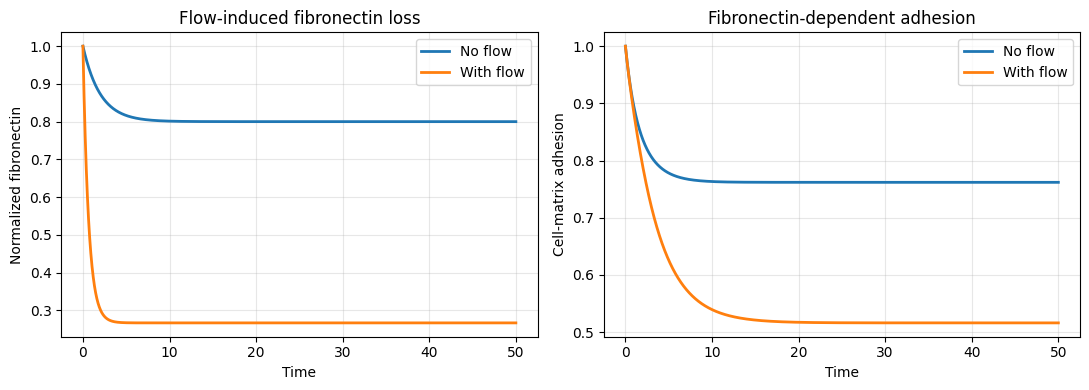

In [6]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

axes[0].plot(
    time,
    fn_no_flow,
    label="No flow",
    linewidth=2
)

axes[0].plot(
    time,
    fn_with_flow,
    label="With flow",
    linewidth=2
)

axes[0].set_xlabel("Time")
axes[0].set_ylabel("Normalized fibronectin")
axes[0].set_title("Flow-induced fibronectin loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    time,
    adhesion_no_flow,
    label="No flow",
    linewidth=2
)

axes[1].plot(
    time,
    adhesion_with_flow,
    label="With flow",
    linewidth=2
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Cell-matrix adhesion")
axes[1].set_title("Fibronectin-dependent adhesion")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Adhesion-controlled phenotype switching

Published no-flow and flow phenotype fractions determine an adhesion-dependent equilibrium mesenchymal probability. A two-state stochastic process then generates amoeboid-to-mesenchymal and mesenchymal-to-amoeboid transitions.


In [7]:
experimental_mesenchymal_no_flow = 0.58
experimental_mesenchymal_with_flow = 0.27

adhesion_equilibrium_no_flow = adhesion_no_flow[-1]
adhesion_equilibrium_with_flow = adhesion_with_flow[-1]

print(
    "No-flow equilibrium adhesion:",
    adhesion_equilibrium_no_flow
)

print(
    "Flow equilibrium adhesion:",
    adhesion_equilibrium_with_flow
)

No-flow equilibrium adhesion: 0.7619047619076272
Flow equilibrium adhesion: 0.5161291261169253


In [8]:
def logit(probability):
    return np.log(
        probability / (1.0 - probability)
    )


adhesion_sensitivity = (
    logit(experimental_mesenchymal_no_flow)
    - logit(experimental_mesenchymal_with_flow)
) / (
    adhesion_equilibrium_no_flow
    - adhesion_equilibrium_with_flow
)

adhesion_threshold = (
    adhesion_equilibrium_no_flow
    - logit(experimental_mesenchymal_no_flow)
    / adhesion_sensitivity
)

print(
    "Adhesion sensitivity:",
    adhesion_sensitivity
)

print(
    "Adhesion threshold:",
    adhesion_threshold
)

Adhesion sensitivity: 5.36015688930608
Adhesion threshold: 0.7016876080203953


In [9]:
phenotype_switching_rate = 0.25


def mesenchymal_equilibrium_probability(adhesion):
    exponent = (
        -adhesion_sensitivity
        * (adhesion - adhesion_threshold)
    )

    return 1.0 / (1.0 + np.exp(exponent))


def phenotype_switching_rates(adhesion):
    mesenchymal_probability = (
        mesenchymal_equilibrium_probability(adhesion)
    )

    amoeboid_to_mesenchymal = (
        phenotype_switching_rate
        * mesenchymal_probability
    )

    mesenchymal_to_amoeboid = (
        phenotype_switching_rate
        * (1.0 - mesenchymal_probability)
    )

    return (
        amoeboid_to_mesenchymal,
        mesenchymal_to_amoeboid
    )

In [10]:
predicted_fraction_no_flow = (
    mesenchymal_equilibrium_probability(
        adhesion_equilibrium_no_flow
    )
)

predicted_fraction_with_flow = (
    mesenchymal_equilibrium_probability(
        adhesion_equilibrium_with_flow
    )
)

print(
    "Predicted mesenchymal fraction without flow:",
    predicted_fraction_no_flow
)

print(
    "Experimental target without flow:",
    experimental_mesenchymal_no_flow
)

print(
    "Predicted mesenchymal fraction with flow:",
    predicted_fraction_with_flow
)

print(
    "Experimental target with flow:",
    experimental_mesenchymal_with_flow
)

print(
    "No-flow switching rates:",
    phenotype_switching_rates(
        adhesion_equilibrium_no_flow
    )
)

print(
    "Flow switching rates:",
    phenotype_switching_rates(
        adhesion_equilibrium_with_flow
    )
)

Predicted mesenchymal fraction without flow: 0.5799999999999998
Experimental target without flow: 0.58
Predicted mesenchymal fraction with flow: 0.2699999999999999
Experimental target with flow: 0.27
No-flow switching rates: (0.14499999999999996, 0.10500000000000004)
Flow switching rates: (0.06749999999999998, 0.18250000000000002)


In [11]:
def simulate_phenotype_population(
    adhesion_history,
    seed,
    number_of_cells=2000,
    initial_mesenchymal_fraction=0.25
):
    rng = np.random.default_rng(seed)

    phenotypes = (
        rng.random(number_of_cells)
        < initial_mesenchymal_fraction
    )

    fraction_history = np.zeros(n_steps + 1)
    fraction_history[0] = phenotypes.mean()

    for step in range(n_steps):
        adhesion = adhesion_history[step]

        rate_A_to_M, rate_M_to_A = (
            phenotype_switching_rates(adhesion)
        )

        random_values = rng.random(number_of_cells)

        switch_A_to_M = (
            (~phenotypes)
            & (random_values < rate_A_to_M * dt)
        )

        switch_M_to_A = (
            phenotypes
            & (random_values < rate_M_to_A * dt)
        )

        phenotypes[switch_A_to_M] = True
        phenotypes[switch_M_to_A] = False

        fraction_history[step + 1] = (
            phenotypes.mean()
        )

    return fraction_history, phenotypes

In [12]:
fraction_no_flow, final_states_no_flow = (
    simulate_phenotype_population(
        adhesion_no_flow,
        seed=1001
    )
)

fraction_with_flow, final_states_with_flow = (
    simulate_phenotype_population(
        adhesion_with_flow,
        seed=1002
    )
)

print(
    "Initial mesenchymal fraction without flow:",
    fraction_no_flow[0]
)

print(
    "Final stochastic fraction without flow:",
    fraction_no_flow[-1]
)

print(
    "Expected equilibrium without flow:",
    experimental_mesenchymal_no_flow
)

print(
    "Initial mesenchymal fraction with flow:",
    fraction_with_flow[0]
)

print(
    "Final stochastic fraction with flow:",
    fraction_with_flow[-1]
)

print(
    "Expected equilibrium with flow:",
    experimental_mesenchymal_with_flow
)

Initial mesenchymal fraction without flow: 0.2475
Final stochastic fraction without flow: 0.584
Expected equilibrium without flow: 0.58
Initial mesenchymal fraction with flow: 0.2475
Final stochastic fraction with flow: 0.268
Expected equilibrium with flow: 0.27


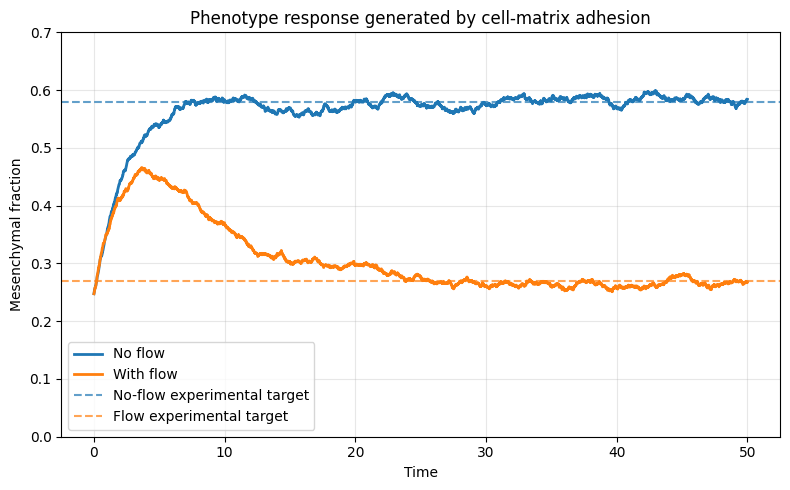

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    time,
    fraction_no_flow,
    label="No flow",
    linewidth=2
)

plt.plot(
    time,
    fraction_with_flow,
    label="With flow",
    linewidth=2
)

plt.axhline(
    experimental_mesenchymal_no_flow,
    color="C0",
    linestyle="--",
    alpha=0.7,
    label="No-flow experimental target"
)

plt.axhline(
    experimental_mesenchymal_with_flow,
    color="C1",
    linestyle="--",
    alpha=0.7,
    label="Flow experimental target"
)

plt.xlabel("Time")
plt.ylabel("Mesenchymal fraction")
plt.title(
    "Phenotype response generated by cell-matrix adhesion"
)

plt.ylim(0.0, 0.7)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Phenotype-dependent single-cell motility

Each phenotype has its own persistence time and active-noise amplitude. Active velocity follows an Ornstein–Uhlenbeck process, while translational fluctuations add independent positional noise.


In [14]:
# Translational fluctuations
D = 0.25

# Phenotype-dependent persistence times
tau_amoeboid = 0.50
tau_mesenchymal = 12.0

# Phenotype-dependent active-noise amplitudes
speed_amoeboid = 2.20
speed_mesenchymal = 1.00

number_of_motile_cells = 192

print("Amoeboid persistence:", tau_amoeboid)
print("Mesenchymal persistence:", tau_mesenchymal)
print("Amoeboid active-speed scale:", speed_amoeboid)
print("Mesenchymal active-speed scale:", speed_mesenchymal)

Amoeboid persistence: 0.5
Mesenchymal persistence: 12.0
Amoeboid active-speed scale: 2.2
Mesenchymal active-speed scale: 1.0


In [15]:
def simulate_motile_population(
    local_flow_speed,
    seed,
    number_of_cells=number_of_motile_cells,
    initial_mesenchymal_fraction=0.25
):
    rng = np.random.default_rng(seed)

    positions = np.zeros(
        (n_steps + 1, number_of_cells, 2)
    )

    velocities = np.zeros(
        (n_steps + 1, number_of_cells, 2)
    )

    phenotype_history = np.zeros(
        (n_steps + 1, number_of_cells),
        dtype=bool
    )

    fibronectin_history = np.zeros(n_steps + 1)
    adhesion_history = np.zeros(n_steps + 1)

    fibronectin = 1.0
    adhesion = 1.0

    phenotypes = (
        rng.random(number_of_cells)
        < initial_mesenchymal_fraction
    )

    phenotype_history[0] = phenotypes
    fibronectin_history[0] = fibronectin
    adhesion_history[0] = adhesion

    active_velocity = np.zeros(
        (number_of_cells, 2)
    )

    for step in range(n_steps):
        # -----------------------------------
        # 1. Fibronectin and matrix adhesion
        # -----------------------------------
        fibronectin += (
            fibronectin_change(
                fibronectin,
                local_flow_speed
            )
            * dt
        )

        fibronectin = np.clip(
            fibronectin,
            0.0,
            1.0
        )

        adhesion += (
            adhesion_change(
                adhesion,
                fibronectin
            )
            * dt
        )

        adhesion = np.clip(
            adhesion,
            0.0,
            1.0
        )

        # -----------------------
        # 2. Phenotype switching
        # -----------------------
        rate_A_to_M, rate_M_to_A = (
            phenotype_switching_rates(adhesion)
        )

        switching_random_values = rng.random(
            number_of_cells
        )

        switch_A_to_M = (
            (~phenotypes)
            & (
                switching_random_values
                < rate_A_to_M * dt
            )
        )

        switch_M_to_A = (
            phenotypes
            & (
                switching_random_values
                < rate_M_to_A * dt
            )
        )

        phenotypes[switch_A_to_M] = True
        phenotypes[switch_M_to_A] = False

        # --------------------------------
        # 3. Phenotype-dependent motility
        # --------------------------------
        persistence_times = np.where(
            phenotypes,
            tau_mesenchymal,
            tau_amoeboid
        )

        active_speed_scales = np.where(
            phenotypes,
            speed_mesenchymal,
            speed_amoeboid
        )

        velocity_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        active_velocity = (
            active_velocity
            - (
                active_velocity
                / persistence_times[:, np.newaxis]
            )
            * dt
            + active_speed_scales[:, np.newaxis]
            * np.sqrt(
                2.0
                * dt
                / persistence_times[:, np.newaxis]
            )
            * velocity_noise
        )

        # ----------------
        # 4. Cell position
        # ----------------
        position_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        positions[step + 1] = (
            positions[step]
            + active_velocity * dt
            + np.sqrt(2.0 * D * dt)
            * position_noise
        )

        velocities[step + 1] = active_velocity
        phenotype_history[step + 1] = phenotypes
        fibronectin_history[step + 1] = fibronectin
        adhesion_history[step + 1] = adhesion

    return {
        "positions": positions,
        "velocities": velocities,
        "phenotypes": phenotype_history,
        "fibronectin": fibronectin_history,
        "adhesion": adhesion_history
    }

In [16]:
motility_no_flow = simulate_motile_population(
    local_flow_speed=0.0,
    seed=2001
)

motility_with_flow = simulate_motile_population(
    local_flow_speed=1.0,
    seed=2002
)

print(
    "No-flow position shape:",
    motility_no_flow["positions"].shape
)

print(
    "Flow position shape:",
    motility_with_flow["positions"].shape
)

print(
    "Final mesenchymal fraction without flow:",
    motility_no_flow["phenotypes"][-1].mean()
)

print(
    "Final mesenchymal fraction with flow:",
    motility_with_flow["phenotypes"][-1].mean()
)

print(
    "Final fibronectin without flow:",
    motility_no_flow["fibronectin"][-1]
)

print(
    "Final fibronectin with flow:",
    motility_with_flow["fibronectin"][-1]
)

print(
    "Final adhesion without flow:",
    motility_no_flow["adhesion"][-1]
)

print(
    "Final adhesion with flow:",
    motility_with_flow["adhesion"][-1]
)

No-flow position shape: (5001, 192, 2)
Flow position shape: (5001, 192, 2)
Final mesenchymal fraction without flow: 0.5833333333333334
Final mesenchymal fraction with flow: 0.265625
Final fibronectin without flow: 0.800000000002609
Final fibronectin with flow: 0.2666666666666685
Final adhesion without flow: 0.7619047619076129
Final adhesion with flow: 0.5161291260292266


In [17]:
number_of_sampled_frames = 192

sampled_indices = np.linspace(
    0,
    n_steps,
    number_of_sampled_frames,
    dtype=int
)

sampled_time = time[sampled_indices]

sampled_positions_no_flow = (
    motility_no_flow["positions"][sampled_indices]
)

sampled_positions_with_flow = (
    motility_with_flow["positions"][sampled_indices]
)

print(
    "Sampled no-flow shape:",
    sampled_positions_no_flow.shape
)

print(
    "Sampled flow shape:",
    sampled_positions_with_flow.shape
)

print(
    "Mean sampling interval:",
    np.mean(np.diff(sampled_time))
)

Sampled no-flow shape: (192, 192, 2)
Sampled flow shape: (192, 192, 2)
Mean sampling interval: 0.2617801047120419


In [18]:
def trajectory_persistence(sampled_positions):
    displacements = np.diff(
        sampled_positions,
        axis=0
    )

    path_lengths = np.sum(
        np.linalg.norm(displacements, axis=2),
        axis=0
    )

    net_displacements = np.linalg.norm(
        sampled_positions[-1]
        - sampled_positions[0],
        axis=1
    )

    persistence = np.divide(
        net_displacements,
        path_lengths,
        out=np.zeros_like(net_displacements),
        where=path_lengths > 0
    )

    return persistence


def mean_sampled_speed(sampled_positions, sampled_time):
    displacements = np.diff(
        sampled_positions,
        axis=0
    )

    time_intervals = np.diff(
        sampled_time
    )[:, np.newaxis]

    step_speeds = (
        np.linalg.norm(displacements, axis=2)
        / time_intervals
    )

    return step_speeds.mean()


def ensemble_msd(sampled_positions):
    displacement_from_start = (
        sampled_positions
        - sampled_positions[0:1]
    )

    squared_displacement = np.sum(
        displacement_from_start**2,
        axis=2
    )

    return squared_displacement.mean(axis=1)


def fit_msd_exponent(
    sampled_time,
    msd,
    fit_start=5.0,
    fit_end=25.0
):
    fitting_mask = (
        (sampled_time >= fit_start)
        & (sampled_time <= fit_end)
        & (msd > 0)
    )

    slope, intercept = np.polyfit(
        np.log(sampled_time[fitting_mask]),
        np.log(msd[fitting_mask]),
        1
    )

    return slope, intercept

In [19]:
persistence_no_flow = trajectory_persistence(
    sampled_positions_no_flow
)

persistence_with_flow = trajectory_persistence(
    sampled_positions_with_flow
)

speed_no_flow = mean_sampled_speed(
    sampled_positions_no_flow,
    sampled_time
)

speed_with_flow = mean_sampled_speed(
    sampled_positions_with_flow,
    sampled_time
)

msd_no_flow = ensemble_msd(
    sampled_positions_no_flow
)

msd_with_flow = ensemble_msd(
    sampled_positions_with_flow
)

alpha_no_flow, _ = fit_msd_exponent(
    sampled_time,
    msd_no_flow
)

alpha_with_flow, _ = fit_msd_exponent(
    sampled_time,
    msd_with_flow
)

print(
    "Persistence without flow:",
    persistence_no_flow.mean()
)

print(
    "Persistence with flow:",
    persistence_with_flow.mean()
)

print(
    "Persistence ratio, flow/no-flow:",
    persistence_with_flow.mean()
    / persistence_no_flow.mean()
)

print()

print("Mean speed without flow:", speed_no_flow)
print("Mean speed with flow:", speed_with_flow)

print(
    "Speed ratio, flow/no-flow:",
    speed_with_flow / speed_no_flow
)

print()

print("MSD exponent without flow:", alpha_no_flow)
print("MSD exponent with flow:", alpha_with_flow)

print("Final MSD without flow:", msd_no_flow[-1])
print("Final MSD with flow:", msd_with_flow[-1])

Persistence without flow: 0.2653366546551561
Persistence with flow: 0.18196401063673592
Persistence ratio, flow/no-flow: 0.6857854255878248

Mean speed without flow: 2.8277609166577973
Mean speed with flow: 2.925559745615003
Speed ratio, flow/no-flow: 1.034585253788993

MSD exponent without flow: 1.6837539567079893
MSD exponent with flow: 1.3620600357806165
Final MSD without flow: 1917.1892309080656
Final MSD with flow: 966.5578571360744


In [20]:
print(
    "Observable       | Simulation | Experiment"
)

print(
    f"No-flow P       | "
    f"{persistence_no_flow.mean():8.3f} | 0.260"
)

print(
    f"Flow P          | "
    f"{persistence_with_flow.mean():8.3f} | 0.160"
)

print(
    f"No-flow alpha   | "
    f"{alpha_no_flow:8.3f} | 1.460"
)

print(
    f"Flow alpha      | "
    f"{alpha_with_flow:8.3f} | 1.270"
)

print(
    f"Speed ratio     | "
    f"{speed_with_flow / speed_no_flow:8.3f} | 1.090"
)

Observable       | Simulation | Experiment
No-flow P       |    0.265 | 0.260
Flow P          |    0.182 | 0.160
No-flow alpha   |    1.684 | 1.460
Flow alpha      |    1.362 | 1.270
Speed ratio     |    1.035 | 1.090


In [21]:
def matrix_equilibrium(local_flow_speed):
    fibronectin_equilibrium = (
        fn_production_rate
        / (
            fn_production_rate
            + fn_natural_loss_rate
            + fn_sweep_rate * local_flow_speed
        )
    )

    adhesion_equilibrium = (
        adhesion_formation_rate
        * fibronectin_equilibrium
        / (
            adhesion_formation_rate
            * fibronectin_equilibrium
            + adhesion_loss_rate
        )
    )

    mesenchymal_fraction_equilibrium = (
        mesenchymal_equilibrium_probability(
            adhesion_equilibrium
        )
    )

    return (
        fibronectin_equilibrium,
        adhesion_equilibrium,
        mesenchymal_fraction_equilibrium
    )


print(
    "No-flow equilibria:",
    matrix_equilibrium(0.0)
)

print(
    "Flow equilibria:",
    matrix_equilibrium(1.0)
)

No-flow equilibria: (0.8, 0.7619047619047619, 0.5799999999962585)
Flow equilibria: (0.26666666666666666, 0.5161290322580645, 0.2699999008393524)


## 5. Population observables and preliminary calibration

Compute persistence, time-averaged MSD exponents, mean speed, and flow/no-flow phenotype fractions using the same sampling logic applied to the experimental summary statistics.


In [22]:
def simulate_steady_motile_population(
    local_flow_speed,
    seed,
    number_of_cells=number_of_motile_cells
):
    rng = np.random.default_rng(seed)

    (
        fibronectin,
        adhesion,
        equilibrium_mesenchymal_fraction
    ) = matrix_equilibrium(local_flow_speed)

    phenotypes = (
        rng.random(number_of_cells)
        < equilibrium_mesenchymal_fraction
    )

    persistence_times = np.where(
        phenotypes,
        tau_mesenchymal,
        tau_amoeboid
    )

    active_speed_scales = np.where(
        phenotypes,
        speed_mesenchymal,
        speed_amoeboid
    )

    # Start the OU velocity at its stationary distribution
    active_velocity = (
        active_speed_scales[:, np.newaxis]
        * rng.normal(size=(number_of_cells, 2))
    )

    positions = np.zeros(
        (n_steps + 1, number_of_cells, 2)
    )

    velocities = np.zeros_like(positions)

    phenotype_history = np.zeros(
        (n_steps + 1, number_of_cells),
        dtype=bool
    )

    velocities[0] = active_velocity
    phenotype_history[0] = phenotypes

    for step in range(n_steps):
        rate_A_to_M, rate_M_to_A = (
            phenotype_switching_rates(adhesion)
        )

        switching_random_values = rng.random(
            number_of_cells
        )

        switch_A_to_M = (
            (~phenotypes)
            & (
                switching_random_values
                < rate_A_to_M * dt
            )
        )

        switch_M_to_A = (
            phenotypes
            & (
                switching_random_values
                < rate_M_to_A * dt
            )
        )

        phenotypes[switch_A_to_M] = True
        phenotypes[switch_M_to_A] = False

        persistence_times = np.where(
            phenotypes,
            tau_mesenchymal,
            tau_amoeboid
        )

        active_speed_scales = np.where(
            phenotypes,
            speed_mesenchymal,
            speed_amoeboid
        )

        velocity_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        active_velocity = (
            active_velocity
            - (
                active_velocity
                / persistence_times[:, np.newaxis]
            )
            * dt
            + active_speed_scales[:, np.newaxis]
            * np.sqrt(
                2.0
                * dt
                / persistence_times[:, np.newaxis]
            )
            * velocity_noise
        )

        position_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        positions[step + 1] = (
            positions[step]
            + active_velocity * dt
            + np.sqrt(2.0 * D * dt)
            * position_noise
        )

        velocities[step + 1] = active_velocity
        phenotype_history[step + 1] = phenotypes

    return positions, velocities, phenotype_history

In [23]:
steady_positions_no_flow, _, steady_states_no_flow = (
    simulate_steady_motile_population(
        local_flow_speed=0.0,
        seed=3001
    )
)

steady_positions_with_flow, _, steady_states_with_flow = (
    simulate_steady_motile_population(
        local_flow_speed=1.0,
        seed=3002
    )
)

steady_sampled_no_flow = (
    steady_positions_no_flow[sampled_indices]
)

steady_sampled_with_flow = (
    steady_positions_with_flow[sampled_indices]
)

steady_P_no_flow = trajectory_persistence(
    steady_sampled_no_flow
).mean()

steady_P_with_flow = trajectory_persistence(
    steady_sampled_with_flow
).mean()

steady_speed_no_flow = mean_sampled_speed(
    steady_sampled_no_flow,
    sampled_time
)

steady_speed_with_flow = mean_sampled_speed(
    steady_sampled_with_flow,
    sampled_time
)

steady_msd_no_flow = ensemble_msd(
    steady_sampled_no_flow
)

steady_msd_with_flow = ensemble_msd(
    steady_sampled_with_flow
)

steady_alpha_no_flow, _ = fit_msd_exponent(
    sampled_time,
    steady_msd_no_flow
)

steady_alpha_with_flow, _ = fit_msd_exponent(
    sampled_time,
    steady_msd_with_flow
)

print("Observable       | Simulation | Experiment")

print(
    f"No-flow P       | "
    f"{steady_P_no_flow:8.3f} | 0.260"
)

print(
    f"Flow P          | "
    f"{steady_P_with_flow:8.3f} | 0.160"
)

print(
    f"No-flow alpha   | "
    f"{steady_alpha_no_flow:8.3f} | 1.460"
)

print(
    f"Flow alpha      | "
    f"{steady_alpha_with_flow:8.3f} | 1.270"
)

print(
    f"Speed ratio     | "
    f"{steady_speed_with_flow / steady_speed_no_flow:8.3f} | 1.090"
)

print()

print(
    "Final mesenchymal fraction without flow:",
    steady_states_no_flow[-1].mean()
)

print(
    "Final mesenchymal fraction with flow:",
    steady_states_with_flow[-1].mean()
)

Observable       | Simulation | Experiment
No-flow P       |    0.247 | 0.260
Flow P          |    0.185 | 0.160
No-flow alpha   |    1.589 | 1.460
Flow alpha      |    1.231 | 1.270
Speed ratio     |    1.056 | 1.090

Final mesenchymal fraction without flow: 0.5416666666666666
Final mesenchymal fraction with flow: 0.2604166666666667


In [24]:
def evaluate_steady_replicate(seed):
    positions_no_flow, _, states_no_flow = (
        simulate_steady_motile_population(
            local_flow_speed=0.0,
            seed=seed
        )
    )

    positions_with_flow, _, states_with_flow = (
        simulate_steady_motile_population(
            local_flow_speed=1.0,
            seed=seed + 10000
        )
    )

    sampled_no_flow = positions_no_flow[
        sampled_indices
    ]

    sampled_with_flow = positions_with_flow[
        sampled_indices
    ]

    P_no_flow = trajectory_persistence(
        sampled_no_flow
    ).mean()

    P_with_flow = trajectory_persistence(
        sampled_with_flow
    ).mean()

    speed_no_flow = mean_sampled_speed(
        sampled_no_flow,
        sampled_time
    )

    speed_with_flow = mean_sampled_speed(
        sampled_with_flow,
        sampled_time
    )

    msd_no_flow = ensemble_msd(
        sampled_no_flow
    )

    msd_with_flow = ensemble_msd(
        sampled_with_flow
    )

    alpha_no_flow, _ = fit_msd_exponent(
        sampled_time,
        msd_no_flow
    )

    alpha_with_flow, _ = fit_msd_exponent(
        sampled_time,
        msd_with_flow
    )

    return np.array([
        P_no_flow,
        P_with_flow,
        alpha_no_flow,
        alpha_with_flow,
        speed_with_flow / speed_no_flow,
        states_no_flow[-1].mean(),
        states_with_flow[-1].mean()
    ])

In [25]:
number_of_replicates = 10

replicate_results = []

for replicate_index in range(number_of_replicates):
    result = evaluate_steady_replicate(
        seed=4000 + replicate_index
    )

    replicate_results.append(result)

    print(
        "Completed replicate",
        replicate_index + 1,
        "of",
        number_of_replicates
    )

replicate_results = np.array(replicate_results)

metric_names = [
    "P no flow",
    "P flow",
    "Alpha no flow",
    "Alpha flow",
    "Speed ratio",
    "M fraction no flow",
    "M fraction flow"
]

experimental_targets = np.array([
    0.260,
    0.160,
    1.460,
    1.270,
    1.090,
    0.580,
    0.270
])

print()
print("Metric | Mean | SD | Experimental target")

for metric_index, metric_name in enumerate(metric_names):
    mean_value = replicate_results[
        :,
        metric_index
    ].mean()

    standard_deviation = replicate_results[
        :,
        metric_index
    ].std(ddof=1)

    print(
        f"{metric_name:20s} | "
        f"{mean_value:6.3f} | "
        f"{standard_deviation:6.3f} | "
        f"{experimental_targets[metric_index]:6.3f}"
    )

Completed replicate 1 of 10
Completed replicate 2 of 10
Completed replicate 3 of 10
Completed replicate 4 of 10
Completed replicate 5 of 10
Completed replicate 6 of 10
Completed replicate 7 of 10
Completed replicate 8 of 10
Completed replicate 9 of 10
Completed replicate 10 of 10

Metric | Mean | SD | Experimental target
P no flow            |  0.263 |  0.008 |  0.260
P flow               |  0.193 |  0.006 |  0.160
Alpha no flow        |  1.534 |  0.064 |  1.460
Alpha flow           |  1.346 |  0.096 |  1.270
Speed ratio          |  1.072 |  0.011 |  1.090
M fraction no flow   |  0.571 |  0.039 |  0.580
M fraction flow      |  0.271 |  0.035 |  0.270


In [26]:
from itertools import product

original_D = D
original_tau_amoeboid = tau_amoeboid
original_speed_amoeboid = speed_amoeboid

D_candidates = [0.25, 0.30, 0.35]
tau_A_candidates = [0.25, 0.35, 0.50]
speed_A_candidates = [2.20, 2.35, 2.50]

calibration_targets = np.array([
    0.260,  # no-flow persistence
    0.160,  # flow persistence
    1.460,  # no-flow MSD exponent
    1.270,  # flow MSD exponent
    1.090   # speed ratio
])

calibration_results = []

candidate_combinations = list(
    product(
        D_candidates,
        tau_A_candidates,
        speed_A_candidates
    )
)

for candidate_index, (
    candidate_D,
    candidate_tau_A,
    candidate_speed_A
) in enumerate(candidate_combinations):

    D = candidate_D
    tau_amoeboid = candidate_tau_A
    speed_amoeboid = candidate_speed_A

    candidate_replicates = []

    for replicate_index in range(3):
        candidate_result = evaluate_steady_replicate(
            seed=6000
            + 100 * candidate_index
            + replicate_index
        )

        candidate_replicates.append(
            candidate_result[:5]
        )

    candidate_mean = np.mean(
        candidate_replicates,
        axis=0
    )

    relative_errors = (
        (candidate_mean - calibration_targets)
        / calibration_targets
    )

    score = np.sum(relative_errors**2)

    calibration_results.append({
        "D": candidate_D,
        "tau_A": candidate_tau_A,
        "speed_A": candidate_speed_A,
        "P0": candidate_mean[0],
        "PF": candidate_mean[1],
        "alpha0": candidate_mean[2],
        "alphaF": candidate_mean[3],
        "speed_ratio": candidate_mean[4],
        "score": score
    })

    print(
        "Completed combination",
        candidate_index + 1,
        "of",
        len(candidate_combinations)
    )

# Restore the original values until we select a candidate
D = original_D
tau_amoeboid = original_tau_amoeboid
speed_amoeboid = original_speed_amoeboid

Completed combination 1 of 27
Completed combination 2 of 27
Completed combination 3 of 27
Completed combination 4 of 27
Completed combination 5 of 27
Completed combination 6 of 27
Completed combination 7 of 27
Completed combination 8 of 27
Completed combination 9 of 27
Completed combination 10 of 27
Completed combination 11 of 27
Completed combination 12 of 27
Completed combination 13 of 27
Completed combination 14 of 27
Completed combination 15 of 27
Completed combination 16 of 27
Completed combination 17 of 27
Completed combination 18 of 27
Completed combination 19 of 27
Completed combination 20 of 27
Completed combination 21 of 27
Completed combination 22 of 27
Completed combination 23 of 27
Completed combination 24 of 27
Completed combination 25 of 27
Completed combination 26 of 27
Completed combination 27 of 27


In [27]:
calibration_results = sorted(
    calibration_results,
    key=lambda result: result["score"]
)

print(
    "D | Tau_A | Speed_A | P0 | PF | "
    "Alpha0 | AlphaF | Speed ratio | Score"
)

for result in calibration_results[:10]:
    print(
        f"{result['D']:.2f} | "
        f"{result['tau_A']:.2f} | "
        f"{result['speed_A']:.2f} | "
        f"{result['P0']:.3f} | "
        f"{result['PF']:.3f} | "
        f"{result['alpha0']:.3f} | "
        f"{result['alphaF']:.3f} | "
        f"{result['speed_ratio']:.3f} | "
        f"{result['score']:.5f}"
    )

best_result = calibration_results[0]

print()
print("Best candidate:")
print(best_result)

D | Tau_A | Speed_A | P0 | PF | Alpha0 | AlphaF | Speed ratio | Score
0.30 | 0.25 | 2.20 | 0.248 | 0.160 | 1.585 | 1.338 | 1.053 | 0.01351
0.35 | 0.50 | 2.20 | 0.248 | 0.172 | 1.549 | 1.360 | 1.066 | 0.01672
0.35 | 0.35 | 2.35 | 0.240 | 0.165 | 1.488 | 1.395 | 1.069 | 0.01705
0.25 | 0.25 | 2.20 | 0.248 | 0.168 | 1.571 | 1.392 | 1.056 | 0.02076
0.30 | 0.25 | 2.35 | 0.254 | 0.164 | 1.642 | 1.356 | 1.056 | 0.02225
0.30 | 0.25 | 2.50 | 0.260 | 0.171 | 1.613 | 1.370 | 1.062 | 0.02269
0.30 | 0.35 | 2.50 | 0.257 | 0.181 | 1.573 | 1.349 | 1.079 | 0.02742
0.35 | 0.25 | 2.20 | 0.232 | 0.159 | 1.638 | 1.276 | 1.047 | 0.02798
0.25 | 0.35 | 2.35 | 0.257 | 0.180 | 1.553 | 1.385 | 1.076 | 0.02890
0.30 | 0.35 | 2.35 | 0.252 | 0.172 | 1.673 | 1.318 | 1.075 | 0.02971

Best candidate:
{'D': 0.3, 'tau_A': 0.25, 'speed_A': 2.2, 'P0': 0.24800993199445517, 'PF': 0.15967785134584656, 'alpha0': 1.5848301309822428, 'alphaF': 1.3383003781819944, 'speed_ratio': 1.0526597162785627, 'score': 0.013506793385014223}


In [28]:
def time_averaged_ensemble_msd(sampled_positions):
    number_of_frames = sampled_positions.shape[0]

    lag_times = (
        sampled_time[1:]
        - sampled_time[0]
    )

    msd_values = np.zeros(number_of_frames - 1)

    for lag in range(1, number_of_frames):
        lagged_displacements = (
            sampled_positions[lag:]
            - sampled_positions[:-lag]
        )

        squared_displacements = np.sum(
            lagged_displacements**2,
            axis=2
        )

        msd_values[lag - 1] = (
            squared_displacements.mean()
        )

    return lag_times, msd_values


def fit_time_averaged_msd_exponent(
    lag_times,
    msd_values,
    fit_start=5.0,
    fit_end=25.0
):
    fitting_mask = (
        (lag_times >= fit_start)
        & (lag_times <= fit_end)
        & (msd_values > 0)
    )

    slope, intercept = np.polyfit(
        np.log(lag_times[fitting_mask]),
        np.log(msd_values[fitting_mask]),
        1
    )

    return slope, intercept

In [29]:
lag_times_no_flow, time_averaged_msd_no_flow = (
    time_averaged_ensemble_msd(
        steady_sampled_no_flow
    )
)

lag_times_with_flow, time_averaged_msd_with_flow = (
    time_averaged_ensemble_msd(
        steady_sampled_with_flow
    )
)

corrected_alpha_no_flow, _ = (
    fit_time_averaged_msd_exponent(
        lag_times_no_flow,
        time_averaged_msd_no_flow
    )
)

corrected_alpha_with_flow, _ = (
    fit_time_averaged_msd_exponent(
        lag_times_with_flow,
        time_averaged_msd_with_flow
    )
)

print(
    "Corrected no-flow MSD exponent:",
    corrected_alpha_no_flow
)

print(
    "Experimental no-flow exponent:",
    1.46
)

print(
    "Corrected flow MSD exponent:",
    corrected_alpha_with_flow
)

print(
    "Experimental flow exponent:",
    1.27
)

Corrected no-flow MSD exponent: 1.4036539302896744
Experimental no-flow exponent: 1.46
Corrected flow MSD exponent: 1.1896490211486177
Experimental flow exponent: 1.27


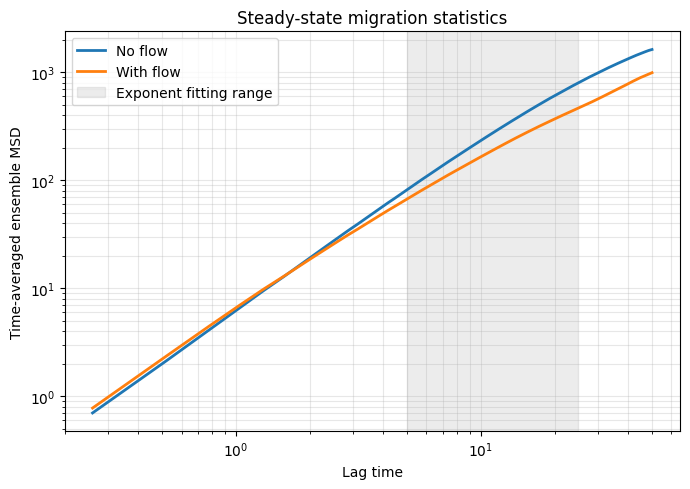

In [30]:
plt.figure(figsize=(7, 5))

plt.loglog(
    lag_times_no_flow,
    time_averaged_msd_no_flow,
    label="No flow",
    linewidth=2
)

plt.loglog(
    lag_times_with_flow,
    time_averaged_msd_with_flow,
    label="With flow",
    linewidth=2
)

plt.axvspan(
    5.0,
    25.0,
    color="gray",
    alpha=0.15,
    label="Exponent fitting range"
)

plt.xlabel("Lag time")
plt.ylabel("Time-averaged ensemble MSD")
plt.title("Steady-state migration statistics")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
def evaluate_corrected_replicate(seed):
    positions_no_flow, _, states_no_flow = (
        simulate_steady_motile_population(
            local_flow_speed=0.0,
            seed=seed
        )
    )

    positions_with_flow, _, states_with_flow = (
        simulate_steady_motile_population(
            local_flow_speed=1.0,
            seed=seed + 10000
        )
    )

    sampled_no_flow = positions_no_flow[
        sampled_indices
    ]

    sampled_with_flow = positions_with_flow[
        sampled_indices
    ]

    P_no_flow = trajectory_persistence(
        sampled_no_flow
    ).mean()

    P_with_flow = trajectory_persistence(
        sampled_with_flow
    ).mean()

    speed_no_flow = mean_sampled_speed(
        sampled_no_flow,
        sampled_time
    )

    speed_with_flow = mean_sampled_speed(
        sampled_with_flow,
        sampled_time
    )

    lag_no_flow, msd_no_flow = (
        time_averaged_ensemble_msd(
            sampled_no_flow
        )
    )

    lag_with_flow, msd_with_flow = (
        time_averaged_ensemble_msd(
            sampled_with_flow
        )
    )

    alpha_no_flow, _ = (
        fit_time_averaged_msd_exponent(
            lag_no_flow,
            msd_no_flow
        )
    )

    alpha_with_flow, _ = (
        fit_time_averaged_msd_exponent(
            lag_with_flow,
            msd_with_flow
        )
    )

    return np.array([
        P_no_flow,
        P_with_flow,
        alpha_no_flow,
        alpha_with_flow,
        speed_with_flow / speed_no_flow,
        states_no_flow[-1].mean(),
        states_with_flow[-1].mean()
    ])

In [32]:
D = 0.25
tau_amoeboid = 0.50
speed_amoeboid = 2.20

In [33]:
corrected_replicate_results = []

for replicate_index in range(10):
    result = evaluate_corrected_replicate(
        seed=8000 + replicate_index
    )

    corrected_replicate_results.append(result)

    print(
        "Completed replicate",
        replicate_index + 1,
        "of 10"
    )

corrected_replicate_results = np.array(
    corrected_replicate_results
)

metric_names = [
    "P no flow",
    "P flow",
    "Alpha no flow",
    "Alpha flow",
    "Speed ratio",
    "M fraction no flow",
    "M fraction flow"
]

experimental_targets = np.array([
    0.260,
    0.160,
    1.460,
    1.270,
    1.090,
    0.580,
    0.270
])

print()
print("Metric | Mean | SD | Experimental target")

for metric_index, metric_name in enumerate(metric_names):
    mean_value = corrected_replicate_results[
        :,
        metric_index
    ].mean()

    standard_deviation = corrected_replicate_results[
        :,
        metric_index
    ].std(ddof=1)

    print(
        f"{metric_name:20s} | "
        f"{mean_value:6.3f} | "
        f"{standard_deviation:6.3f} | "
        f"{experimental_targets[metric_index]:6.3f}"
    )

Completed replicate 1 of 10
Completed replicate 2 of 10
Completed replicate 3 of 10
Completed replicate 4 of 10
Completed replicate 5 of 10
Completed replicate 6 of 10
Completed replicate 7 of 10
Completed replicate 8 of 10
Completed replicate 9 of 10
Completed replicate 10 of 10

Metric | Mean | SD | Experimental target
P no flow            |  0.260 |  0.012 |  0.260
P flow               |  0.193 |  0.006 |  0.160
Alpha no flow        |  1.423 |  0.037 |  1.460
Alpha flow           |  1.258 |  0.023 |  1.270
Speed ratio          |  1.064 |  0.009 |  1.090
M fraction no flow   |  0.574 |  0.039 |  0.580
M fraction flow      |  0.266 |  0.035 |  0.270


In [34]:
original_D = D
original_tau_A = tau_amoeboid
original_tau_M = tau_mesenchymal
original_speed_A = speed_amoeboid

D_candidates = [0.20, 0.25]
tau_A_candidates = [0.25, 0.35, 0.50]
tau_M_candidates = [12.0, 15.0]
speed_A_candidates = [2.20, 2.40]

calibration_targets = np.array([
    0.260,
    0.160,
    1.460,
    1.270,
    1.090
])

corrected_calibration_results = []

candidate_combinations = list(
    product(
        D_candidates,
        tau_A_candidates,
        tau_M_candidates,
        speed_A_candidates
    )
)

for candidate_index, (
    candidate_D,
    candidate_tau_A,
    candidate_tau_M,
    candidate_speed_A
) in enumerate(candidate_combinations):

    D = candidate_D
    tau_amoeboid = candidate_tau_A
    tau_mesenchymal = candidate_tau_M
    speed_amoeboid = candidate_speed_A

    candidate_replicates = []

    for replicate_index in range(3):
        candidate_result = (
            evaluate_corrected_replicate(
                seed=10000
                + 100 * candidate_index
                + replicate_index
            )
        )

        candidate_replicates.append(
            candidate_result[:5]
        )

    candidate_mean = np.mean(
        candidate_replicates,
        axis=0
    )

    relative_errors = (
        (candidate_mean - calibration_targets)
        / calibration_targets
    )

    score = np.sum(relative_errors**2)

    corrected_calibration_results.append({
        "D": candidate_D,
        "tau_A": candidate_tau_A,
        "tau_M": candidate_tau_M,
        "speed_A": candidate_speed_A,
        "P0": candidate_mean[0],
        "PF": candidate_mean[1],
        "alpha0": candidate_mean[2],
        "alphaF": candidate_mean[3],
        "speed_ratio": candidate_mean[4],
        "score": score
    })

    print(
        "Completed combination",
        candidate_index + 1,
        "of",
        len(candidate_combinations)
    )

# Restore baseline parameters until a candidate is selected
D = original_D
tau_amoeboid = original_tau_A
tau_mesenchymal = original_tau_M
speed_amoeboid = original_speed_A

Completed combination 1 of 24
Completed combination 2 of 24
Completed combination 3 of 24
Completed combination 4 of 24
Completed combination 5 of 24
Completed combination 6 of 24
Completed combination 7 of 24
Completed combination 8 of 24
Completed combination 9 of 24
Completed combination 10 of 24
Completed combination 11 of 24
Completed combination 12 of 24
Completed combination 13 of 24
Completed combination 14 of 24
Completed combination 15 of 24
Completed combination 16 of 24
Completed combination 17 of 24
Completed combination 18 of 24
Completed combination 19 of 24
Completed combination 20 of 24
Completed combination 21 of 24
Completed combination 22 of 24
Completed combination 23 of 24
Completed combination 24 of 24


In [35]:
corrected_calibration_results = sorted(
    corrected_calibration_results,
    key=lambda result: result["score"]
)

print(
    "D | Tau_A | Tau_M | Speed_A | "
    "P0 | PF | Alpha0 | AlphaF | "
    "Speed ratio | Score"
)

for result in corrected_calibration_results[:10]:
    print(
        f"{result['D']:.2f} | "
        f"{result['tau_A']:.2f} | "
        f"{result['tau_M']:.1f} | "
        f"{result['speed_A']:.2f} | "
        f"{result['P0']:.3f} | "
        f"{result['PF']:.3f} | "
        f"{result['alpha0']:.3f} | "
        f"{result['alphaF']:.3f} | "
        f"{result['speed_ratio']:.3f} | "
        f"{result['score']:.5f}"
    )

best_corrected_result = (
    corrected_calibration_results[0]
)

print()
print("Best corrected candidate:")
print(best_corrected_result)

D | Tau_A | Tau_M | Speed_A | P0 | PF | Alpha0 | AlphaF | Speed ratio | Score
0.25 | 0.25 | 12.0 | 2.40 | 0.258 | 0.176 | 1.418 | 1.271 | 1.066 | 0.01148
0.25 | 0.25 | 15.0 | 2.20 | 0.272 | 0.175 | 1.465 | 1.270 | 1.056 | 0.01204
0.25 | 0.25 | 12.0 | 2.20 | 0.248 | 0.176 | 1.417 | 1.286 | 1.065 | 0.01308
0.20 | 0.25 | 15.0 | 2.20 | 0.272 | 0.177 | 1.449 | 1.253 | 1.073 | 0.01434
0.20 | 0.25 | 12.0 | 2.20 | 0.262 | 0.180 | 1.424 | 1.272 | 1.061 | 0.01650
0.25 | 0.35 | 12.0 | 2.20 | 0.249 | 0.178 | 1.413 | 1.261 | 1.053 | 0.01668
0.25 | 0.35 | 12.0 | 2.40 | 0.259 | 0.180 | 1.405 | 1.232 | 1.088 | 0.01790
0.20 | 0.25 | 12.0 | 2.40 | 0.267 | 0.181 | 1.438 | 1.259 | 1.083 | 0.01821
0.20 | 0.35 | 12.0 | 2.20 | 0.271 | 0.181 | 1.457 | 1.241 | 1.077 | 0.02024
0.25 | 0.50 | 12.0 | 2.20 | 0.250 | 0.182 | 1.397 | 1.216 | 1.073 | 0.02454

Best corrected candidate:
{'D': 0.25, 'tau_A': 0.25, 'tau_M': 12.0, 'speed_A': 2.4, 'P0': 0.25831883926731086, 'PF': 0.17607271383824133, 'alpha0': 1.41753921670

In [36]:
D = 0.25
tau_amoeboid = 0.50
tau_mesenchymal = 12.0
speed_amoeboid = 2.20

In [37]:
cell_cell_repulsion_strength = 8.0
cell_cell_adhesion_strength = 1.5

repulsion_length = 0.50
adhesion_length = 1.50

minimum_distance = 1.0e-8


def phenotype_pair_adhesion(
    phenotype_i,
    phenotype_j
):
    # False = amoeboid, True = mesenchymal

    if phenotype_i and phenotype_j:
        return 1.0       # M-M adhesion

    if phenotype_i or phenotype_j:
        return 0.6       # A-M adhesion

    return 0.2           # A-A adhesion

## 6. Short-range cell–cell mechanics

The pair force is a Gaussian-core interaction with phenotype/adhesion modulation. Pair contributions are equal and opposite, so internal forces sum to zero up to floating-point precision.


In [38]:
def calculate_pair_force(
    position_i,
    position_j,
    phenotype_i,
    phenotype_j
):
    separation_vector = (
        position_i - position_j
    )

    distance = np.linalg.norm(
        separation_vector
    )

    if distance < minimum_distance:
        return np.zeros(2)

    unit_vector = (
        separation_vector / distance
    )

    pair_adhesion_factor = (
        phenotype_pair_adhesion(
            phenotype_i,
            phenotype_j
        )
    )

    repulsive_magnitude = (
        cell_cell_repulsion_strength
        / repulsion_length
        * np.exp(
            -distance / repulsion_length
        )
    )

    attractive_magnitude = (
        cell_cell_adhesion_strength
        * pair_adhesion_factor
        / adhesion_length
        * np.exp(
            -distance / adhesion_length
        )
    )

    force_magnitude = (
        repulsive_magnitude
        - attractive_magnitude
    )

    return force_magnitude * unit_vector

In [39]:
test_position_1 = np.array([0.0, 0.0])
test_position_2 = np.array([1.0, 0.0])

force_on_1 = calculate_pair_force(
    test_position_1,
    test_position_2,
    phenotype_i=True,
    phenotype_j=True
)

force_on_2 = calculate_pair_force(
    test_position_2,
    test_position_1,
    phenotype_i=True,
    phenotype_j=True
)

print("Force on cell 1:", force_on_1)
print("Force on cell 2:", force_on_2)

print(
    "Total internal force:",
    force_on_1 + force_on_2
)


Force on cell 1: [-1.65194741  0.        ]
Force on cell 2: [1.65194741 0.        ]
Total internal force: [0. 0.]


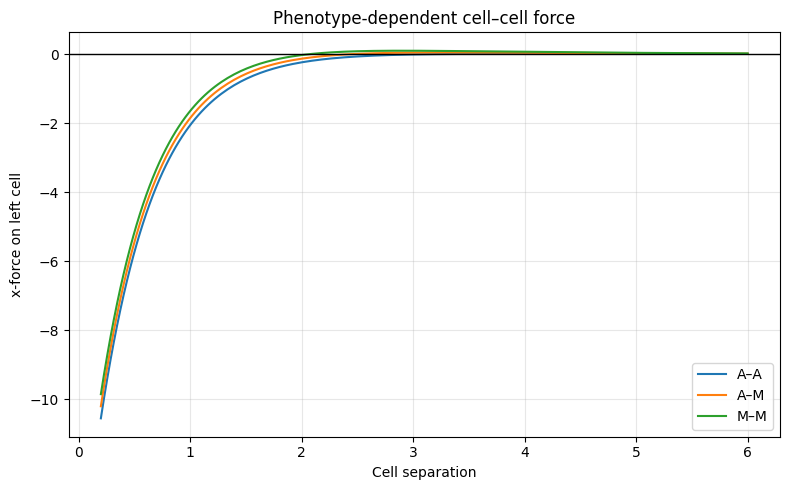

In [40]:
test_distances = np.linspace(
    0.2,
    6.0,
    200
)

force_AA = []
force_AM = []
force_MM = []

for distance in test_distances:
    position_i = np.array([0.0, 0.0])
    position_j = np.array([distance, 0.0])

    force_AA.append(
        calculate_pair_force(
            position_i,
            position_j,
            False,
            False
        )[0]
    )

    force_AM.append(
        calculate_pair_force(
            position_i,
            position_j,
            False,
            True
        )[0]
    )

    force_MM.append(
        calculate_pair_force(
            position_i,
            position_j,
            True,
            True
        )[0]
    )

plt.figure(figsize=(8, 5))

plt.plot(
    test_distances,
    force_AA,
    label="A–A"
)

plt.plot(
    test_distances,
    force_AM,
    label="A–M"
)

plt.plot(
    test_distances,
    force_MM,
    label="M–M"
)

plt.axhline(
    0.0,
    color="black",
    linewidth=1
)

plt.xlabel("Cell separation")
plt.ylabel("x-force on left cell")
plt.title("Phenotype-dependent cell–cell force")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
def calculate_total_cell_cell_forces(
    positions,
    phenotypes
):
    number_of_cells = positions.shape[0]

    total_forces = np.zeros_like(positions)

    for i in range(number_of_cells):
        for j in range(i + 1, number_of_cells):
            force_on_i = calculate_pair_force(
                positions[i],
                positions[j],
                phenotypes[i],
                phenotypes[j]
            )

            total_forces[i] += force_on_i
            total_forces[j] -= force_on_i

    return total_forces

In [42]:
test_colony_positions = np.array([
    [-2.0,  0.0],
    [ 0.0,  0.0],
    [ 2.0,  0.0],
    [ 0.0,  2.0],
    [ 0.0, -2.0]
])

# A, M, M, A, M
test_colony_phenotypes = np.array([
    False,
    True,
    True,
    False,
    True
])

test_colony_forces = (
    calculate_total_cell_cell_forces(
        test_colony_positions,
        test_colony_phenotypes
    )
)

print("Forces on cells:")
print(test_colony_forces)

print(
    "Net internal force:",
    test_colony_forces.sum(axis=0)
)

print(
    "Largest force magnitude:",
    np.linalg.norm(
        test_colony_forces,
        axis=1
    ).max()
)

Forces on cells:
[[-0.09178349 -0.04291721]
 [ 0.10543886 -0.10543886]
 [-0.09948978 -0.04291721]
 [ 0.04291721  0.09178349]
 [ 0.04291721  0.09948978]]
Net internal force: [ 0.00000000e+00 -2.77555756e-17]
Largest force magnitude: 0.14911305909039788


In [43]:
cell_mobility = 0.15

updated_test_positions = (
    test_colony_positions
    + cell_mobility
    * test_colony_forces
    * dt
)

maximum_position_change = np.max(
    np.linalg.norm(
        updated_test_positions
        - test_colony_positions,
        axis=1
    )
)

print(
    "Maximum displacement from interaction force:",
    maximum_position_change
)

print("Updated test positions:")
print(updated_test_positions)

print(
    "All updated positions finite:",
    np.all(np.isfinite(updated_test_positions))
)

Maximum displacement from interaction force: 0.00022366958863559682
Updated test positions:
[[-2.00013768e+00 -6.43758126e-05]
 [ 1.58158283e-04 -1.58158283e-04]
 [ 1.99985077e+00 -6.43758126e-05]
 [ 6.43758126e-05  2.00013768e+00]
 [ 6.43758126e-05 -1.99985077e+00]]
All updated positions finite: True


In [44]:
colony_size = 16
initial_spacing = 2.5


def create_initial_colony_positions(
    seed,
    number_of_cells=colony_size
):
    rng = np.random.default_rng(seed)

    grid_side = int(
        np.ceil(np.sqrt(number_of_cells))
    )

    grid_coordinates = []

    for row in range(grid_side):
        for column in range(grid_side):
            grid_coordinates.append([
                column * initial_spacing,
                row * initial_spacing
            ])

    positions = np.array(
        grid_coordinates[:number_of_cells],
        dtype=float
    )

    positions -= positions.mean(axis=0)

    positions += rng.normal(
        scale=0.05,
        size=positions.shape
    )

    return positions


initial_colony_positions = (
    create_initial_colony_positions(seed=12000)
)

print(
    "Initial position shape:",
    initial_colony_positions.shape
)

print(
    "Initial colony center:",
    initial_colony_positions.mean(axis=0)
)

Initial position shape: (16, 2)
Initial colony center: [ 0.00382742 -0.00038711]


## 7. Interacting colony model

Combine matrix remodeling, stochastic phenotype switching, colored active noise, translational noise, and pairwise cell–cell forces in a many-cell simulation.


In [45]:
def simulate_interacting_mechanistic_colony(
    local_flow_speed,
    seed,
    initial_positions
):
    rng = np.random.default_rng(seed)

    number_of_cells = initial_positions.shape[0]

    (
        fibronectin,
        adhesion,
        equilibrium_mesenchymal_fraction
    ) = matrix_equilibrium(local_flow_speed)

    positions = initial_positions.copy()

    phenotypes = (
        rng.random(number_of_cells)
        < equilibrium_mesenchymal_fraction
    )

    active_speed_scales = np.where(
        phenotypes,
        speed_mesenchymal,
        speed_amoeboid
    )

    active_velocity = (
        active_speed_scales[:, np.newaxis]
        * rng.normal(size=(number_of_cells, 2))
    )

    position_history = np.zeros(
        (n_steps + 1, number_of_cells, 2)
    )

    velocity_history = np.zeros_like(
        position_history
    )

    phenotype_history = np.zeros(
        (n_steps + 1, number_of_cells),
        dtype=bool
    )

    fibronectin_history = np.full(
        n_steps + 1,
        fibronectin
    )

    adhesion_history = np.full(
        n_steps + 1,
        adhesion
    )

    position_history[0] = positions
    velocity_history[0] = active_velocity
    phenotype_history[0] = phenotypes

    for step in range(n_steps):
        # Adhesion-dependent phenotype switching
        rate_A_to_M, rate_M_to_A = (
            phenotype_switching_rates(adhesion)
        )

        switching_random_values = rng.random(
            number_of_cells
        )

        switch_A_to_M = (
            (~phenotypes)
            & (
                switching_random_values
                < rate_A_to_M * dt
            )
        )

        switch_M_to_A = (
            phenotypes
            & (
                switching_random_values
                < rate_M_to_A * dt
            )
        )

        phenotypes[switch_A_to_M] = True
        phenotypes[switch_M_to_A] = False

        # Phenotype-dependent active colored noise
        persistence_times = np.where(
            phenotypes,
            tau_mesenchymal,
            tau_amoeboid
        )

        active_speed_scales = np.where(
            phenotypes,
            speed_mesenchymal,
            speed_amoeboid
        )

        velocity_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        active_velocity = (
            active_velocity
            - (
                active_velocity
                / persistence_times[:, np.newaxis]
            )
            * dt
            + active_speed_scales[:, np.newaxis]
            * np.sqrt(
                2.0
                * dt
                / persistence_times[:, np.newaxis]
            )
            * velocity_noise
        )

        # Phenotype-dependent cell-cell interaction
        interaction_forces = (
            calculate_total_cell_cell_forces(
                positions,
                phenotypes
            )
        )

        position_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        positions = (
            positions
            + active_velocity * dt
            + cell_mobility
            * interaction_forces
            * dt
            + np.sqrt(2.0 * D * dt)
            * position_noise
        )

        position_history[step + 1] = positions
        velocity_history[step + 1] = active_velocity
        phenotype_history[step + 1] = phenotypes

    return {
        "positions": position_history,
        "velocities": velocity_history,
        "phenotypes": phenotype_history,
        "fibronectin": fibronectin_history,
        "adhesion": adhesion_history
    }

In [46]:
colony_no_flow = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=0.0,
        seed=13000,
        initial_positions=initial_colony_positions
    )
)

colony_with_flow = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=1.0,
        seed=13001,
        initial_positions=initial_colony_positions
    )
)

print(
    "No-flow trajectory shape:",
    colony_no_flow["positions"].shape
)

print(
    "Flow trajectory shape:",
    colony_with_flow["positions"].shape
)

print(
    "Final mesenchymal fraction without flow:",
    colony_no_flow["phenotypes"][-1].mean()
)

print(
    "Final mesenchymal fraction with flow:",
    colony_with_flow["phenotypes"][-1].mean()
)

print(
    "All no-flow positions finite:",
    np.all(
        np.isfinite(
            colony_no_flow["positions"]
        )
    )
)

print(
    "All flow positions finite:",
    np.all(
        np.isfinite(
            colony_with_flow["positions"]
        )
    )
)

No-flow trajectory shape: (5001, 16, 2)
Flow trajectory shape: (5001, 16, 2)
Final mesenchymal fraction without flow: 0.6875
Final mesenchymal fraction with flow: 0.5
All no-flow positions finite: True
All flow positions finite: True


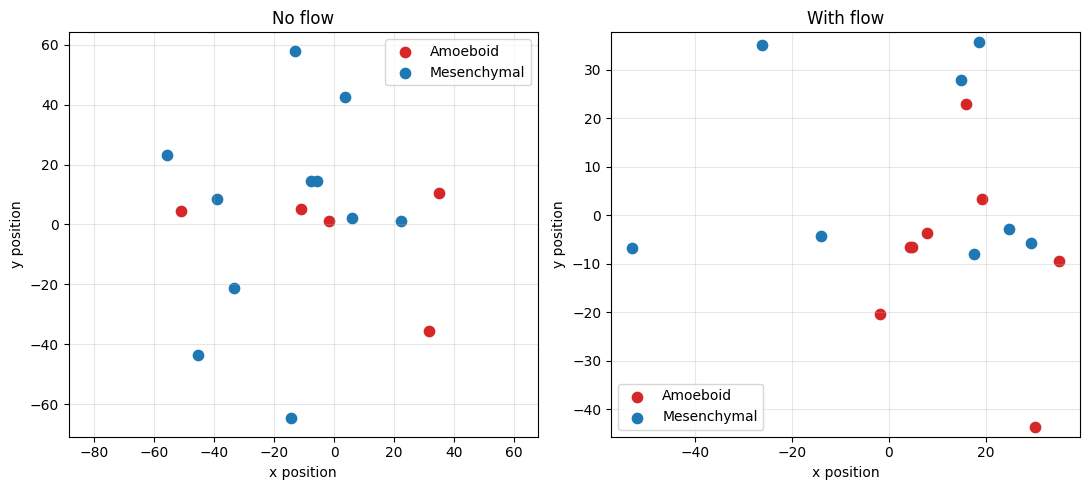

In [47]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5)
)

for axis, result, title in [
    (
        axes[0],
        colony_no_flow,
        "No flow"
    ),
    (
        axes[1],
        colony_with_flow,
        "With flow"
    )
]:
    final_positions = result["positions"][-1]
    final_phenotypes = result["phenotypes"][-1]

    axis.scatter(
        final_positions[
            ~final_phenotypes, 0
        ],
        final_positions[
            ~final_phenotypes, 1
        ],
        color="tab:red",
        label="Amoeboid",
        s=55
    )

    axis.scatter(
        final_positions[
            final_phenotypes, 0
        ],
        final_positions[
            final_phenotypes, 1
        ],
        color="tab:blue",
        label="Mesenchymal",
        s=55
    )

    axis.set_title(title)
    axis.set_xlabel("x position")
    axis.set_ylabel("y position")
    axis.axis("equal")
    axis.grid(alpha=0.3)
    axis.legend()

plt.tight_layout()
plt.show()

In [48]:
def colony_radius(positions):
    center = positions.mean(axis=0)

    radial_distances = np.linalg.norm(
        positions - center,
        axis=1
    )

    return np.sqrt(
        np.mean(radial_distances**2)
    )


def pairwise_distances(positions):
    distances = []

    number_of_cells = positions.shape[0]

    for i in range(number_of_cells):
        for j in range(i + 1, number_of_cells):
            distances.append(
                np.linalg.norm(
                    positions[i] - positions[j]
                )
            )

    return np.array(distances)


def mean_nearest_neighbor_distance(positions):
    number_of_cells = positions.shape[0]

    nearest_distances = []

    for i in range(number_of_cells):
        distances_from_i = np.linalg.norm(
            positions - positions[i],
            axis=1
        )

        distances_from_i[i] = np.inf

        nearest_distances.append(
            distances_from_i.min()
        )

    return np.mean(nearest_distances)


def count_close_pairs(
    positions,
    close_pair_threshold=1.0
):
    distances = pairwise_distances(positions)

    return np.sum(
        distances < close_pair_threshold
    )

In [49]:
def calculate_colony_structure_history(
    position_history
):
    number_of_frames = position_history.shape[0]

    radius_history = np.zeros(number_of_frames)
    neighbor_history = np.zeros(number_of_frames)
    close_pair_history = np.zeros(number_of_frames)
    minimum_separation_history = np.zeros(
        number_of_frames
    )

    for frame in range(number_of_frames):
        positions = position_history[frame]

        distances = pairwise_distances(positions)

        radius_history[frame] = colony_radius(
            positions
        )

        neighbor_history[frame] = (
            mean_nearest_neighbor_distance(
                positions
            )
        )

        close_pair_history[frame] = (
            count_close_pairs(positions)
        )

        minimum_separation_history[frame] = (
            distances.min()
        )

    return {
        "radius": radius_history,
        "nearest_neighbor": neighbor_history,
        "close_pairs": close_pair_history,
        "minimum_separation": (
            minimum_separation_history
        )
    }


structure_no_flow = (
    calculate_colony_structure_history(
        colony_no_flow["positions"]
    )
)

structure_with_flow = (
    calculate_colony_structure_history(
        colony_with_flow["positions"]
    )
)

In [50]:
late_time_start = int(0.8 * (n_steps + 1))

late_fraction_no_flow = (
    colony_no_flow["phenotypes"][
        late_time_start:
    ].mean()
)

late_fraction_with_flow = (
    colony_with_flow["phenotypes"][
        late_time_start:
    ].mean()
)

print("NO FLOW")
print(
    "Initial radius:",
    structure_no_flow["radius"][0]
)
print(
    "Final radius:",
    structure_no_flow["radius"][-1]
)
print(
    "Final nearest-neighbor distance:",
    structure_no_flow["nearest_neighbor"][-1]
)
print(
    "Smallest separation:",
    structure_no_flow[
        "minimum_separation"
    ].min()
)
print(
    "Maximum close-pair count:",
    structure_no_flow["close_pairs"].max()
)
print(
    "Late-time mesenchymal fraction:",
    late_fraction_no_flow
)

print()
print("WITH FLOW")
print(
    "Initial radius:",
    structure_with_flow["radius"][0]
)
print(
    "Final radius:",
    structure_with_flow["radius"][-1]
)
print(
    "Final nearest-neighbor distance:",
    structure_with_flow[
        "nearest_neighbor"
    ][-1]
)
print(
    "Smallest separation:",
    structure_with_flow[
        "minimum_separation"
    ].min()
)
print(
    "Maximum close-pair count:",
    structure_with_flow["close_pairs"].max()
)
print(
    "Late-time mesenchymal fraction:",
    late_fraction_with_flow
)

NO FLOW
Initial radius: 3.9469750671849244
Final radius: 40.26823712506772
Final nearest-neighbor distance: 17.297698887250192
Smallest separation: 0.0754123124736139
Maximum close-pair count: 5.0
Late-time mesenchymal fraction: 0.6381743256743256

WITH FLOW
Initial radius: 3.9469750671849244
Final radius: 29.962460159829554
Final nearest-neighbor distance: 12.960766971438323
Smallest separation: 0.02783839033805114
Maximum close-pair count: 5.0
Late-time mesenchymal fraction: 0.30375874125874125


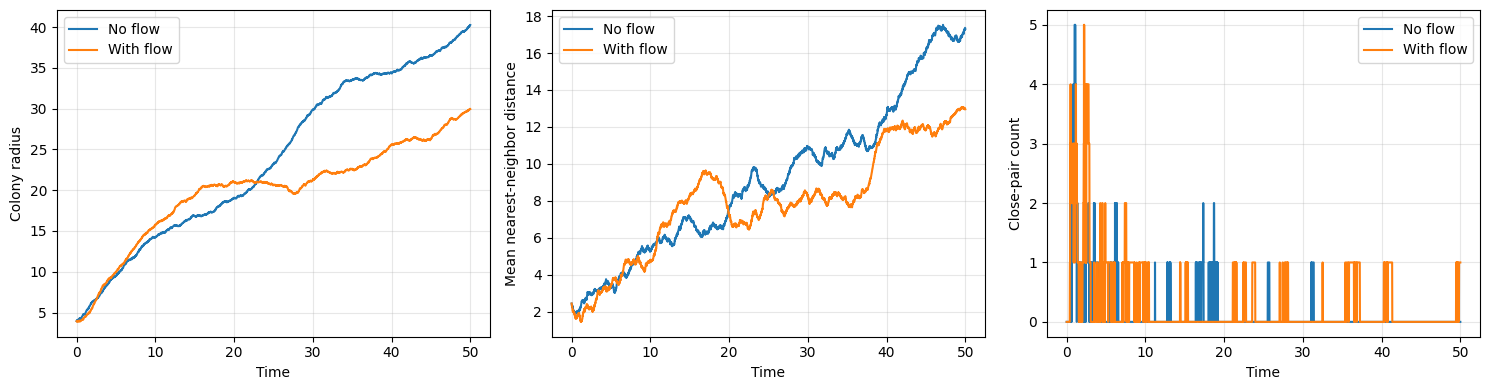

In [51]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

axes[0].plot(
    time,
    structure_no_flow["radius"],
    label="No flow"
)

axes[0].plot(
    time,
    structure_with_flow["radius"],
    label="With flow"
)

axes[0].set_ylabel("Colony radius")

axes[1].plot(
    time,
    structure_no_flow["nearest_neighbor"],
    label="No flow"
)

axes[1].plot(
    time,
    structure_with_flow["nearest_neighbor"],
    label="With flow"
)

axes[1].set_ylabel(
    "Mean nearest-neighbor distance"
)

axes[2].plot(
    time,
    structure_no_flow["close_pairs"],
    label="No flow"
)

axes[2].plot(
    time,
    structure_with_flow["close_pairs"],
    label="With flow"
)

axes[2].set_ylabel("Close-pair count")

for axis in axes:
    axis.set_xlabel("Time")
    axis.grid(alpha=0.3)
    axis.legend()

plt.tight_layout()
plt.show()

In [52]:
effective_cell_diameter = 1.0
cell_cell_adhesion_range = 4.0

hard_core_stiffness = 80.0
contact_adhesion_stiffness = 20.0

## 8. Excluded volume and numerical stability

Enforce a hard-core cell diameter after each integration step to prevent unphysical overlaps. The checks below verify finite trajectories and minimum separation.


In [53]:
def calculate_pair_force(
    position_i,
    position_j,
    phenotype_i,
    phenotype_j
):
    separation_vector = (
        position_i - position_j
    )

    distance = np.linalg.norm(
        separation_vector
    )

    if distance < minimum_distance:
        return np.zeros(2)

    unit_vector = (
        separation_vector / distance
    )

    # Strong excluded-volume repulsion
    if distance < effective_cell_diameter:
        overlap = (
            effective_cell_diameter - distance
        )

        force_magnitude = (
            hard_core_stiffness * overlap
        )

        return force_magnitude * unit_vector

    # Phenotype-dependent adhesion within contact range
    if distance < cell_cell_adhesion_range:
        pair_factor = phenotype_pair_adhesion(
            phenotype_i,
            phenotype_j
        )

        distance_from_contact = (
            distance - effective_cell_diameter
        )

        distance_from_cutoff = (
            cell_cell_adhesion_range - distance
        )

        normalized_adhesive_shape = (
            distance_from_contact
            * distance_from_cutoff
            / (
                cell_cell_adhesion_range
                - effective_cell_diameter
            )
        )

        attractive_magnitude = (
            contact_adhesion_stiffness
            * pair_factor
            * normalized_adhesive_shape
        )

        return (
            -attractive_magnitude
            * unit_vector
        )

    return np.zeros(2)

In [54]:
for distance in [
    0.25,
    0.50,
    0.90,
    1.00,
    1.50,
    2.50,
    3.50,
    4.00,
    5.00
]:
    force = calculate_pair_force(
        np.array([0.0, 0.0]),
        np.array([distance, 0.0]),
        True,
        True
    )

    print(
        f"Distance = {distance:4.2f}, "
        f"force on left cell = {force[0]:8.3f}"
    )

force_1 = calculate_pair_force(
    np.array([0.0, 0.0]),
    np.array([2.0, 0.0]),
    True,
    True
)

force_2 = calculate_pair_force(
    np.array([2.0, 0.0]),
    np.array([0.0, 0.0]),
    True,
    True
)

print(
    "Net pair force:",
    force_1 + force_2
)

Distance = 0.25, force on left cell =  -60.000
Distance = 0.50, force on left cell =  -40.000
Distance = 0.90, force on left cell =   -8.000
Distance = 1.00, force on left cell =    0.000
Distance = 1.50, force on left cell =    8.333
Distance = 2.50, force on left cell =   15.000
Distance = 3.50, force on left cell =    8.333
Distance = 4.00, force on left cell =    0.000
Distance = 5.00, force on left cell =    0.000
Net pair force: [ 0. -0.]


In [55]:
colony_no_flow = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=0.0,
        seed=13000,
        initial_positions=initial_colony_positions
    )
)

colony_with_flow = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=1.0,
        seed=13001,
        initial_positions=initial_colony_positions
    )
)

structure_no_flow = (
    calculate_colony_structure_history(
        colony_no_flow["positions"]
    )
)

structure_with_flow = (
    calculate_colony_structure_history(
        colony_with_flow["positions"]
    )
)

print("NO FLOW")
print(
    "Final radius:",
    structure_no_flow["radius"][-1]
)
print(
    "Final nearest-neighbor distance:",
    structure_no_flow["nearest_neighbor"][-1]
)
print(
    "Smallest separation:",
    structure_no_flow[
        "minimum_separation"
    ].min()
)
print(
    "Maximum close-pair count:",
    structure_no_flow["close_pairs"].max()
)

print()
print("WITH FLOW")
print(
    "Final radius:",
    structure_with_flow["radius"][-1]
)
print(
    "Final nearest-neighbor distance:",
    structure_with_flow["nearest_neighbor"][-1]
)
print(
    "Smallest separation:",
    structure_with_flow[
        "minimum_separation"
    ].min()
)
print(
    "Maximum close-pair count:",
    structure_with_flow["close_pairs"].max()
)

NO FLOW
Final radius: 10.326677587846053
Final nearest-neighbor distance: 2.5783400748263565
Smallest separation: 0.06733950094307947
Maximum close-pair count: 42.0

WITH FLOW
Final radius: 20.781368515681987
Final nearest-neighbor distance: 8.55689169497989
Smallest separation: 0.19095260989893573
Maximum close-pair count: 26.0


In [56]:
hard_core_stiffness = 300.0

print(
    "Relative contact-relaxation factor:",
    2.0
    * cell_mobility
    * hard_core_stiffness
    * dt
)

Relative contact-relaxation factor: 0.9


In [57]:
for distance in [
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    1.00,
    1.50,
    2.50,
    4.00
]:
    force = calculate_pair_force(
        np.array([0.0, 0.0]),
        np.array([distance, 0.0]),
        True,
        True
    )

    one_cell_displacement = (
        cell_mobility
        * abs(force[0])
        * dt
    )

    print(
        f"Distance={distance:4.2f} | "
        f"Force={force[0]:8.3f} | "
        f"one-cell mechanical step="
        f"{one_cell_displacement:7.4f}"
    )

Distance=0.10 | Force=-270.000 | one-cell mechanical step= 0.4050
Distance=0.25 | Force=-225.000 | one-cell mechanical step= 0.3375
Distance=0.50 | Force=-150.000 | one-cell mechanical step= 0.2250
Distance=0.75 | Force= -75.000 | one-cell mechanical step= 0.1125
Distance=0.90 | Force= -30.000 | one-cell mechanical step= 0.0450
Distance=1.00 | Force=   0.000 | one-cell mechanical step= 0.0000
Distance=1.50 | Force=   8.333 | one-cell mechanical step= 0.0125
Distance=2.50 | Force=  15.000 | one-cell mechanical step= 0.0225
Distance=4.00 | Force=   0.000 | one-cell mechanical step= 0.0000


In [58]:
colony_no_flow = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=0.0,
        seed=13000,
        initial_positions=initial_colony_positions
    )
)

colony_with_flow = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=1.0,
        seed=13001,
        initial_positions=initial_colony_positions
    )
)

structure_no_flow = (
    calculate_colony_structure_history(
        colony_no_flow["positions"]
    )
)

structure_with_flow = (
    calculate_colony_structure_history(
        colony_with_flow["positions"]
    )
)

In [59]:
print("NO FLOW")
print(
    "Final radius:",
    structure_no_flow["radius"][-1]
)
print(
    "Final nearest-neighbor distance:",
    structure_no_flow["nearest_neighbor"][-1]
)
print(
    "Final minimum separation:",
    structure_no_flow[
        "minimum_separation"
    ][-1]
)
print(
    "Smallest separation over all time:",
    structure_no_flow[
        "minimum_separation"
    ].min()
)
print(
    "Final close-pair count:",
    structure_no_flow["close_pairs"][-1]
)

print()
print("WITH FLOW")
print(
    "Final radius:",
    structure_with_flow["radius"][-1]
)
print(
    "Final nearest-neighbor distance:",
    structure_with_flow["nearest_neighbor"][-1]
)
print(
    "Final minimum separation:",
    structure_with_flow[
        "minimum_separation"
    ][-1]
)
print(
    "Smallest separation over all time:",
    structure_with_flow[
        "minimum_separation"
    ].min()
)
print(
    "Final close-pair count:",
    structure_with_flow["close_pairs"][-1]
)

NO FLOW
Final radius: 10.349267165938265
Final nearest-neighbor distance: 2.6886942300318415
Final minimum separation: 0.5499242310137812
Smallest separation over all time: 0.23697409969983455
Final close-pair count: 23.0

WITH FLOW
Final radius: 20.582749982538086
Final nearest-neighbor distance: 8.041429531594977
Final minimum separation: 0.8766099382875118
Smallest separation over all time: 0.35274176000044516
Final close-pair count: 10.0


In [60]:
def resolve_hard_core_overlaps(
    positions,
    cell_diameter=effective_cell_diameter,
    number_of_passes=10
):
    corrected_positions = positions.copy()

    number_of_cells = corrected_positions.shape[0]

    for correction_pass in range(number_of_passes):
        overlap_found = False

        for i in range(number_of_cells):
            for j in range(i + 1, number_of_cells):
                separation_vector = (
                    corrected_positions[i]
                    - corrected_positions[j]
                )

                distance = np.linalg.norm(
                    separation_vector
                )

                if distance < cell_diameter:
                    overlap_found = True

                    if distance < minimum_distance:
                        # Deterministic direction for the
                        # extremely unlikely exact-overlap case
                        angle = (
                            2.0
                            * np.pi
                            * (i + j + 1)
                            / (number_of_cells + 1)
                        )

                        unit_vector = np.array([
                            np.cos(angle),
                            np.sin(angle)
                        ])
                    else:
                        unit_vector = (
                            separation_vector / distance
                        )

                    overlap = (
                        cell_diameter - distance
                    )

                    correction = (
                        0.5
                        * overlap
                        * unit_vector
                    )

                    corrected_positions[i] += correction
                    corrected_positions[j] -= correction

        if not overlap_found:
            break

    return corrected_positions

In [65]:
def simulate_interacting_mechanistic_colony(
    local_flow_speed,
    seed,
    initial_positions
):
    rng = np.random.default_rng(seed)

    number_of_cells = initial_positions.shape[0]

    (
        fibronectin,
        adhesion,
        equilibrium_mesenchymal_fraction
    ) = matrix_equilibrium(local_flow_speed)

    positions = initial_positions.copy()

    phenotypes = (
        rng.random(number_of_cells)
        < equilibrium_mesenchymal_fraction
    )

    active_speed_scales = np.where(
        phenotypes,
        speed_mesenchymal,
        speed_amoeboid
    )

    active_velocity = (
        active_speed_scales[:, np.newaxis]
        * rng.normal(size=(number_of_cells, 2))
    )

    position_history = np.zeros(
        (n_steps + 1, number_of_cells, 2)
    )

    velocity_history = np.zeros_like(
        position_history
    )

    phenotype_history = np.zeros(
        (n_steps + 1, number_of_cells),
        dtype=bool
    )

    fibronectin_history = np.full(
        n_steps + 1,
        fibronectin
    )

    adhesion_history = np.full(
        n_steps + 1,
        adhesion
    )

    position_history[0] = positions
    velocity_history[0] = active_velocity
    phenotype_history[0] = phenotypes

    for step in range(n_steps):
        # Phenotype switching
        rate_A_to_M, rate_M_to_A = (
            phenotype_switching_rates(adhesion)
        )

        switching_random_values = rng.random(
            number_of_cells
        )

        switch_A_to_M = (
            (~phenotypes)
            & (
                switching_random_values
                < rate_A_to_M * dt
            )
        )

        switch_M_to_A = (
            phenotypes
            & (
                switching_random_values
                < rate_M_to_A * dt
            )
        )

        phenotypes[switch_A_to_M] = True
        phenotypes[switch_M_to_A] = False

        # Active colored-noise dynamics
        persistence_times = np.where(
            phenotypes,
            tau_mesenchymal,
            tau_amoeboid
        )

        active_speed_scales = np.where(
            phenotypes,
            speed_mesenchymal,
            speed_amoeboid
        )

        velocity_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        active_velocity = (
            active_velocity
            - (
                active_velocity
                / persistence_times[:, np.newaxis]
            )
            * dt
            + active_speed_scales[:, np.newaxis]
            * np.sqrt(
                2.0
                * dt
                / persistence_times[:, np.newaxis]
            )
            * velocity_noise
        )

        # Cell-cell forces
        interaction_forces = (
            calculate_total_cell_cell_forces(
                positions,
                phenotypes
            )
        )

        # Translational fluctuations
        position_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        positions = (
            positions
            + active_velocity * dt
            + cell_mobility
            * interaction_forces
            * dt
            + np.sqrt(2.0 * D * dt)
            * position_noise
        )

        # Enforce excluded-volume constraint
        positions = resolve_hard_core_overlaps(
            positions,
            cell_diameter=effective_cell_diameter,
            number_of_passes=10
        )

        position_history[step + 1] = positions
        velocity_history[step + 1] = active_velocity
        phenotype_history[step + 1] = phenotypes

    return {
        "positions": position_history,
        "velocities": velocity_history,
        "phenotypes": phenotype_history,
        "fibronectin": fibronectin_history,
        "adhesion": adhesion_history
    }

In [66]:
colony_no_flow = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=0.0,
        seed=13000,
        initial_positions=initial_colony_positions
    )
)

colony_with_flow = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=1.0,
        seed=13001,
        initial_positions=initial_colony_positions
    )
)

structure_no_flow = (
    calculate_colony_structure_history(
        colony_no_flow["positions"]
    )
)

structure_with_flow = (
    calculate_colony_structure_history(
        colony_with_flow["positions"]
    )
)

In [67]:
print("NO FLOW")
print(
    "Final radius:",
    structure_no_flow["radius"][-1]
)
print(
    "Final nearest-neighbor distance:",
    structure_no_flow["nearest_neighbor"][-1]
)
print(
    "Final minimum separation:",
    structure_no_flow[
        "minimum_separation"
    ][-1]
)
print(
    "Smallest separation over all time:",
    structure_no_flow[
        "minimum_separation"
    ].min()
)
print(
    "Final close-pair count:",
    structure_no_flow["close_pairs"][-1]
)

print()
print("WITH FLOW")
print(
    "Final radius:",
    structure_with_flow["radius"][-1]
)
print(
    "Final nearest-neighbor distance:",
    structure_with_flow["nearest_neighbor"][-1]
)
print(
    "Final minimum separation:",
    structure_with_flow[
        "minimum_separation"
    ][-1]
)
print(
    "Smallest separation over all time:",
    structure_with_flow[
        "minimum_separation"
    ].min()
)
print(
    "Final close-pair count:",
    structure_with_flow["close_pairs"][-1]
)

NO FLOW
Final radius: 10.382219500155246
Final nearest-neighbor distance: 2.946071221025174
Final minimum separation: 0.9995869573081249
Smallest separation over all time: 0.9963364061346066
Final close-pair count: 9.0

WITH FLOW
Final radius: 15.169172459745885
Final nearest-neighbor distance: 6.094810313965504
Final minimum separation: 0.9999902298216102
Smallest separation over all time: 0.9968686644959072
Final close-pair count: 5.0


In [68]:
number_of_colony_replicates = 5

colony_replicate_results = []

for replicate_index in range(
    number_of_colony_replicates
):
    replicate_initial_positions = (
        create_initial_colony_positions(
            seed=15000 + replicate_index
        )
    )

    replicate_no_flow = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=0.0,
            seed=16000 + replicate_index,
            initial_positions=(
                replicate_initial_positions
            )
        )
    )

    replicate_with_flow = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=1.0,
            seed=17000 + replicate_index,
            initial_positions=(
                replicate_initial_positions
            )
        )
    )

    final_no_flow = (
        replicate_no_flow["positions"][-1]
    )

    final_with_flow = (
        replicate_with_flow["positions"][-1]
    )

    no_flow_distances = pairwise_distances(
        final_no_flow
    )

    flow_distances = pairwise_distances(
        final_with_flow
    )

    late_start = int(
        0.8
        * replicate_no_flow[
            "phenotypes"
        ].shape[0]
    )

    colony_replicate_results.append([
        colony_radius(final_no_flow),
        colony_radius(final_with_flow),

        mean_nearest_neighbor_distance(
            final_no_flow
        ),

        mean_nearest_neighbor_distance(
            final_with_flow
        ),

        no_flow_distances.min(),
        flow_distances.min(),

        np.sum(no_flow_distances < 0.95),
        np.sum(flow_distances < 0.95),

        replicate_no_flow[
            "phenotypes"
        ][late_start:].mean(),

        replicate_with_flow[
            "phenotypes"
        ][late_start:].mean()
    ])

    print(
        "Completed colony replicate",
        replicate_index + 1,
        "of",
        number_of_colony_replicates
    )

colony_replicate_results = np.array(
    colony_replicate_results
)

Completed colony replicate 1 of 5
Completed colony replicate 2 of 5
Completed colony replicate 3 of 5
Completed colony replicate 4 of 5
Completed colony replicate 5 of 5


In [69]:
colony_metric_names = [
    "Radius no flow",
    "Radius flow",
    "Neighbor distance no flow",
    "Neighbor distance flow",
    "Minimum separation no flow",
    "Minimum separation flow",
    "Overlapping pairs no flow",
    "Overlapping pairs flow",
    "M fraction no flow",
    "M fraction flow"
]

print("Metric | Mean | SD")

for metric_index, metric_name in enumerate(
    colony_metric_names
):
    values = colony_replicate_results[
        :,
        metric_index
    ]

    print(
        f"{metric_name:28s} | "
        f"{values.mean():8.3f} | "
        f"{values.std(ddof=1):8.3f}"
    )

radius_difference = (
    colony_replicate_results[:, 1]
    - colony_replicate_results[:, 0]
)

neighbor_difference = (
    colony_replicate_results[:, 3]
    - colony_replicate_results[:, 2]
)

print()
print(
    "Flow minus no-flow radius:",
    radius_difference
)

print(
    "Flow minus no-flow neighbor distance:",
    neighbor_difference
)

print(
    "Replicates with larger radius under flow:",
    np.sum(radius_difference > 0),
    "out of",
    number_of_colony_replicates
)

print(
    "Replicates with larger neighbor distance under flow:",
    np.sum(neighbor_difference > 0),
    "out of",
    number_of_colony_replicates
)

Metric | Mean | SD
Radius no flow               |   10.421 |    9.016
Radius flow                  |   16.587 |    5.087
Neighbor distance no flow    |    2.591 |    2.009
Neighbor distance flow       |    6.199 |    2.389
Minimum separation no flow   |    0.999 |    0.000
Minimum separation flow      |    1.000 |    0.000
Overlapping pairs no flow    |    0.000 |    0.000
Overlapping pairs flow       |    0.000 |    0.000
M fraction no flow           |    0.569 |    0.057
M fraction flow              |    0.263 |    0.046

Flow minus no-flow radius: [-3.98790458 -3.61024094 20.7194215  15.428784    2.28107263]
Flow minus no-flow neighbor distance: [-1.54556523  4.56438044  8.15639331  5.76117449  1.10016209]
Replicates with larger radius under flow: 3 out of 5
Replicates with larger neighbor distance under flow: 4 out of 5


In [70]:
number_of_paired_replicates = 10

paired_colony_results = []

for replicate_index in range(
    number_of_paired_replicates
):
    paired_seed = 20000 + replicate_index

    paired_initial_positions = (
        create_initial_colony_positions(
            seed=21000 + replicate_index
        )
    )

    paired_no_flow = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=0.0,
            seed=paired_seed,
            initial_positions=(
                paired_initial_positions
            )
        )
    )

    paired_with_flow = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=1.0,
            seed=paired_seed,
            initial_positions=(
                paired_initial_positions
            )
        )
    )

    final_no_flow = (
        paired_no_flow["positions"][-1]
    )

    final_with_flow = (
        paired_with_flow["positions"][-1]
    )

    late_start = int(0.8 * (n_steps + 1))

    paired_colony_results.append([
        colony_radius(final_no_flow),
        colony_radius(final_with_flow),

        mean_nearest_neighbor_distance(
            final_no_flow
        ),

        mean_nearest_neighbor_distance(
            final_with_flow
        ),

        paired_no_flow[
            "phenotypes"
        ][late_start:].mean(),

        paired_with_flow[
            "phenotypes"
        ][late_start:].mean()
    ])

    print(
        "Completed paired replicate",
        replicate_index + 1,
        "of",
        number_of_paired_replicates
    )

paired_colony_results = np.array(
    paired_colony_results
)

Completed paired replicate 1 of 10
Completed paired replicate 2 of 10
Completed paired replicate 3 of 10
Completed paired replicate 4 of 10
Completed paired replicate 5 of 10
Completed paired replicate 6 of 10
Completed paired replicate 7 of 10
Completed paired replicate 8 of 10
Completed paired replicate 9 of 10
Completed paired replicate 10 of 10


In [71]:
paired_radius_difference = (
    paired_colony_results[:, 1]
    - paired_colony_results[:, 0]
)

paired_neighbor_difference = (
    paired_colony_results[:, 3]
    - paired_colony_results[:, 2]
)

print(
    "Mean radius without flow:",
    paired_colony_results[:, 0].mean()
)

print(
    "Mean radius with flow:",
    paired_colony_results[:, 1].mean()
)

print(
    "Mean paired radius difference:",
    paired_radius_difference.mean()
)

print(
    "SD of paired radius difference:",
    paired_radius_difference.std(ddof=1)
)

print(
    "Larger radius under flow:",
    np.sum(paired_radius_difference > 0),
    "out of",
    number_of_paired_replicates
)

print()

print(
    "Mean neighbor distance without flow:",
    paired_colony_results[:, 2].mean()
)

print(
    "Mean neighbor distance with flow:",
    paired_colony_results[:, 3].mean()
)

print(
    "Mean paired neighbor difference:",
    paired_neighbor_difference.mean()
)

print(
    "SD of paired neighbor difference:",
    paired_neighbor_difference.std(ddof=1)
)

print(
    "Larger neighbor distance under flow:",
    np.sum(paired_neighbor_difference > 0),
    "out of",
    number_of_paired_replicates
)

print()

print(
    "Late mesenchymal fraction without flow:",
    paired_colony_results[:, 4].mean()
)

print(
    "Late mesenchymal fraction with flow:",
    paired_colony_results[:, 5].mean()
)

Mean radius without flow: 9.323973920034808
Mean radius with flow: 10.151072893536984
Mean paired radius difference: 0.8270989735021775
SD of paired radius difference: 5.702717079773089
Larger radius under flow: 6 out of 10

Mean neighbor distance without flow: 3.0865238143316143
Mean neighbor distance with flow: 4.152366269385341
Mean paired neighbor difference: 1.0658424550537269
SD of paired neighbor difference: 1.2876207937224122
Larger neighbor distance under flow: 8 out of 10

Late mesenchymal fraction without flow: 0.591520979020979
Late mesenchymal fraction with flow: 0.260807942057942


In [72]:
pooled_no_flow_trajectories = []
pooled_flow_trajectories = []

for replicate_index in range(10):
    paired_seed = 23000 + replicate_index

    paired_initial_positions = (
        create_initial_colony_positions(
            seed=24000 + replicate_index
        )
    )

    result_no_flow = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=0.0,
            seed=paired_seed,
            initial_positions=(
                paired_initial_positions
            )
        )
    )

    result_with_flow = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=1.0,
            seed=paired_seed,
            initial_positions=(
                paired_initial_positions
            )
        )
    )

    pooled_no_flow_trajectories.append(
        result_no_flow["positions"][
            sampled_indices
        ]
    )

    pooled_flow_trajectories.append(
        result_with_flow["positions"][
            sampled_indices
        ]
    )

    print(
        "Completed trajectory pair",
        replicate_index + 1,
        "of 10"
    )

pooled_no_flow_trajectories = np.concatenate(
    pooled_no_flow_trajectories,
    axis=1
)

pooled_flow_trajectories = np.concatenate(
    pooled_flow_trajectories,
    axis=1
)

print(
    "Pooled no-flow shape:",
    pooled_no_flow_trajectories.shape
)

print(
    "Pooled flow shape:",
    pooled_flow_trajectories.shape
)

Completed trajectory pair 1 of 10
Completed trajectory pair 2 of 10
Completed trajectory pair 3 of 10
Completed trajectory pair 4 of 10
Completed trajectory pair 5 of 10
Completed trajectory pair 6 of 10
Completed trajectory pair 7 of 10
Completed trajectory pair 8 of 10
Completed trajectory pair 9 of 10
Completed trajectory pair 10 of 10
Pooled no-flow shape: (192, 160, 2)
Pooled flow shape: (192, 160, 2)


In [73]:
interacting_P_no_flow = (
    trajectory_persistence(
        pooled_no_flow_trajectories
    ).mean()
)

interacting_P_with_flow = (
    trajectory_persistence(
        pooled_flow_trajectories
    ).mean()
)

interacting_speed_no_flow = (
    mean_sampled_speed(
        pooled_no_flow_trajectories,
        sampled_time
    )
)

interacting_speed_with_flow = (
    mean_sampled_speed(
        pooled_flow_trajectories,
        sampled_time
    )
)

lag_no_flow, interacting_msd_no_flow = (
    time_averaged_ensemble_msd(
        pooled_no_flow_trajectories
    )
)

lag_with_flow, interacting_msd_with_flow = (
    time_averaged_ensemble_msd(
        pooled_flow_trajectories
    )
)

interacting_alpha_no_flow, _ = (
    fit_time_averaged_msd_exponent(
        lag_no_flow,
        interacting_msd_no_flow
    )
)

interacting_alpha_with_flow, _ = (
    fit_time_averaged_msd_exponent(
        lag_with_flow,
        interacting_msd_with_flow
    )
)

print("Observable       | Simulation | Experiment")

print(
    f"No-flow P       | "
    f"{interacting_P_no_flow:8.3f} | 0.260"
)

print(
    f"Flow P          | "
    f"{interacting_P_with_flow:8.3f} | 0.160"
)

print(
    f"No-flow alpha   | "
    f"{interacting_alpha_no_flow:8.3f} | 1.460"
)

print(
    f"Flow alpha      | "
    f"{interacting_alpha_with_flow:8.3f} | 1.270"
)

print(
    f"Speed ratio     | "
    f"{interacting_speed_with_flow / interacting_speed_no_flow:8.3f} | 1.090"
)

Observable       | Simulation | Experiment
No-flow P       |    0.165 | 0.260
Flow P          |    0.146 | 0.160
No-flow alpha   |    1.321 | 1.460
Flow alpha      |    1.196 | 1.270
Speed ratio     |    1.642 | 1.090


In [74]:
cell_cell_adhesion_range = 1.5
contact_adhesion_stiffness = 20.0

print(
    "Cell diameter:",
    effective_cell_diameter
)

print(
    "Direct adhesion range:",
    cell_cell_adhesion_range
)

Cell diameter: 1.0
Direct adhesion range: 1.5


In [75]:
for distance in [
    0.50,
    0.90,
    1.00,
    1.10,
    1.25,
    1.40,
    1.50,
    2.00
]:
    force = calculate_pair_force(
        np.array([0.0, 0.0]),
        np.array([distance, 0.0]),
        True,
        True
    )

    print(
        f"Distance = {distance:4.2f}, "
        f"M-M force on left cell = "
        f"{force[0]:8.4f}"
    )

Distance = 0.50, M-M force on left cell = -150.0000
Distance = 0.90, M-M force on left cell = -30.0000
Distance = 1.00, M-M force on left cell =   0.0000
Distance = 1.10, M-M force on left cell =   1.6000
Distance = 1.25, M-M force on left cell =   2.5000
Distance = 1.40, M-M force on left cell =   1.6000
Distance = 1.50, M-M force on left cell =   0.0000
Distance = 2.00, M-M force on left cell =   0.0000


In [76]:
pooled_no_flow_trajectories = []
pooled_flow_trajectories = []

for replicate_index in range(10):
    paired_seed = 23000 + replicate_index

    paired_initial_positions = (
        create_initial_colony_positions(
            seed=24000 + replicate_index
        )
    )

    result_no_flow = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=0.0,
            seed=paired_seed,
            initial_positions=(
                paired_initial_positions
            )
        )
    )

    result_with_flow = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=1.0,
            seed=paired_seed,
            initial_positions=(
                paired_initial_positions
            )
        )
    )

    pooled_no_flow_trajectories.append(
        result_no_flow["positions"][
            sampled_indices
        ]
    )

    pooled_flow_trajectories.append(
        result_with_flow["positions"][
            sampled_indices
        ]
    )

    print(
        "Completed trajectory pair",
        replicate_index + 1,
        "of 10"
    )

pooled_no_flow_trajectories = np.concatenate(
    pooled_no_flow_trajectories,
    axis=1
)

pooled_flow_trajectories = np.concatenate(
    pooled_flow_trajectories,
    axis=1
)

print(
    "Pooled no-flow shape:",
    pooled_no_flow_trajectories.shape
)

print(
    "Pooled flow shape:",
    pooled_flow_trajectories.shape
)

Completed trajectory pair 1 of 10
Completed trajectory pair 2 of 10
Completed trajectory pair 3 of 10
Completed trajectory pair 4 of 10
Completed trajectory pair 5 of 10
Completed trajectory pair 6 of 10
Completed trajectory pair 7 of 10
Completed trajectory pair 8 of 10
Completed trajectory pair 9 of 10
Completed trajectory pair 10 of 10
Pooled no-flow shape: (192, 160, 2)
Pooled flow shape: (192, 160, 2)


## 9. Interaction-aware recalibration

Re-evaluate population observables after adding cell–cell mechanics, because interactions can alter persistence, dispersion, and apparent speed.


In [77]:
interacting_P_no_flow = (
    trajectory_persistence(
        pooled_no_flow_trajectories
    ).mean()
)

interacting_P_with_flow = (
    trajectory_persistence(
        pooled_flow_trajectories
    ).mean()
)

interacting_speed_no_flow = (
    mean_sampled_speed(
        pooled_no_flow_trajectories,
        sampled_time
    )
)

interacting_speed_with_flow = (
    mean_sampled_speed(
        pooled_flow_trajectories,
        sampled_time
    )
)

lag_no_flow, interacting_msd_no_flow = (
    time_averaged_ensemble_msd(
        pooled_no_flow_trajectories
    )
)

lag_with_flow, interacting_msd_with_flow = (
    time_averaged_ensemble_msd(
        pooled_flow_trajectories
    )
)

interacting_alpha_no_flow, _ = (
    fit_time_averaged_msd_exponent(
        lag_no_flow,
        interacting_msd_no_flow
    )
)

interacting_alpha_with_flow, _ = (
    fit_time_averaged_msd_exponent(
        lag_with_flow,
        interacting_msd_with_flow
    )
)

print("Observable       | Simulation | Experiment")

print(
    f"No-flow P       | "
    f"{interacting_P_no_flow:8.3f} | 0.260"
)

print(
    f"Flow P          | "
    f"{interacting_P_with_flow:8.3f} | 0.160"
)

print(
    f"No-flow alpha   | "
    f"{interacting_alpha_no_flow:8.3f} | 1.460"
)

print(
    f"Flow alpha      | "
    f"{interacting_alpha_with_flow:8.3f} | 1.270"
)

print(
    f"Speed ratio     | "
    f"{interacting_speed_with_flow / interacting_speed_no_flow:8.3f} | 1.090"
)

Observable       | Simulation | Experiment
No-flow P       |    0.251 | 0.260
Flow P          |    0.194 | 0.160
No-flow alpha   |    1.378 | 1.460
Flow alpha      |    1.285 | 1.270
Speed ratio     |    1.069 | 1.090


In [78]:
from itertools import product


def evaluate_interacting_parameters(
    replicate_seeds
):
    no_flow_trajectories = []
    flow_trajectories = []

    for replicate_index, simulation_seed in enumerate(
        replicate_seeds
    ):
        initial_positions = (
            create_initial_colony_positions(
                seed=simulation_seed + 1000
            )
        )

        no_flow_result = (
            simulate_interacting_mechanistic_colony(
                local_flow_speed=0.0,
                seed=simulation_seed,
                initial_positions=initial_positions
            )
        )

        flow_result = (
            simulate_interacting_mechanistic_colony(
                local_flow_speed=1.0,
                seed=simulation_seed,
                initial_positions=initial_positions
            )
        )

        no_flow_trajectories.append(
            no_flow_result["positions"][
                sampled_indices
            ]
        )

        flow_trajectories.append(
            flow_result["positions"][
                sampled_indices
            ]
        )

    no_flow_trajectories = np.concatenate(
        no_flow_trajectories,
        axis=1
    )

    flow_trajectories = np.concatenate(
        flow_trajectories,
        axis=1
    )

    persistence_no_flow = (
        trajectory_persistence(
            no_flow_trajectories
        ).mean()
    )

    persistence_flow = (
        trajectory_persistence(
            flow_trajectories
        ).mean()
    )

    speed_no_flow = mean_sampled_speed(
        no_flow_trajectories,
        sampled_time
    )

    speed_flow = mean_sampled_speed(
        flow_trajectories,
        sampled_time
    )

    lag_no_flow, msd_no_flow = (
        time_averaged_ensemble_msd(
            no_flow_trajectories
        )
    )

    lag_flow, msd_flow = (
        time_averaged_ensemble_msd(
            flow_trajectories
        )
    )

    alpha_no_flow, _ = (
        fit_time_averaged_msd_exponent(
            lag_no_flow,
            msd_no_flow
        )
    )

    alpha_flow, _ = (
        fit_time_averaged_msd_exponent(
            lag_flow,
            msd_flow
        )
    )

    return np.array([
        persistence_no_flow,
        persistence_flow,
        alpha_no_flow,
        alpha_flow,
        speed_flow / speed_no_flow
    ])

In [79]:
# Save current values
baseline_D = D
baseline_tau_A = tau_amoeboid
baseline_tau_M = tau_mesenchymal
baseline_speed_A = speed_amoeboid

# Keep diffusion fixed during this screening
D = 0.25

tau_A_candidates = [0.15, 0.25, 0.50]
tau_M_candidates = [12.0, 15.0]
speed_A_candidates = [2.20, 2.40]

calibration_targets = np.array([
    0.260,
    0.160,
    1.460,
    1.270,
    1.090
])

screening_seeds = [
    30000,
    30001
]

screening_results = []

candidate_combinations = list(
    product(
        tau_A_candidates,
        tau_M_candidates,
        speed_A_candidates
    )
)

for candidate_index, (
    candidate_tau_A,
    candidate_tau_M,
    candidate_speed_A
) in enumerate(candidate_combinations):

    tau_amoeboid = candidate_tau_A
    tau_mesenchymal = candidate_tau_M
    speed_amoeboid = candidate_speed_A

    candidate_metrics = (
        evaluate_interacting_parameters(
            screening_seeds
        )
    )

    relative_errors = (
        candidate_metrics
        - calibration_targets
    ) / calibration_targets

    score = np.sum(relative_errors**2)

    screening_results.append({
        "tau_A": candidate_tau_A,
        "tau_M": candidate_tau_M,
        "speed_A": candidate_speed_A,
        "P0": candidate_metrics[0],
        "PF": candidate_metrics[1],
        "alpha0": candidate_metrics[2],
        "alphaF": candidate_metrics[3],
        "speed_ratio": candidate_metrics[4],
        "score": score
    })

    print(
        "Completed combination",
        candidate_index + 1,
        "of",
        len(candidate_combinations)
    )

# Restore baseline values until a winner is selected
D = baseline_D
tau_amoeboid = baseline_tau_A
tau_mesenchymal = baseline_tau_M
speed_amoeboid = baseline_speed_A

Completed combination 1 of 12
Completed combination 2 of 12
Completed combination 3 of 12
Completed combination 4 of 12
Completed combination 5 of 12
Completed combination 6 of 12
Completed combination 7 of 12
Completed combination 8 of 12
Completed combination 9 of 12
Completed combination 10 of 12
Completed combination 11 of 12
Completed combination 12 of 12


In [80]:
screening_results = sorted(
    screening_results,
    key=lambda result: result["score"]
)

print(
    "Tau_A | Tau_M | Speed_A | "
    "P0 | PF | Alpha0 | AlphaF | "
    "Speed ratio | Score"
)

for result in screening_results:
    print(
        f"{result['tau_A']:5.2f} | "
        f"{result['tau_M']:5.1f} | "
        f"{result['speed_A']:7.2f} | "
        f"{result['P0']:.3f} | "
        f"{result['PF']:.3f} | "
        f"{result['alpha0']:.3f} | "
        f"{result['alphaF']:.3f} | "
        f"{result['speed_ratio']:.3f} | "
        f"{result['score']:.5f}"
    )

Tau_A | Tau_M | Speed_A | P0 | PF | Alpha0 | AlphaF | Speed ratio | Score
 0.15 |  12.0 |    2.20 | 0.231 | 0.194 | 1.353 | 1.335 | 1.038 | 0.06774
 0.15 |  12.0 |    2.40 | 0.238 | 0.199 | 1.362 | 1.343 | 1.046 | 0.07616
 0.15 |  15.0 |    2.20 | 0.244 | 0.201 | 1.388 | 1.362 | 1.033 | 0.07899
 0.15 |  15.0 |    2.40 | 0.252 | 0.204 | 1.401 | 1.364 | 1.040 | 0.08693
 0.25 |  12.0 |    2.20 | 0.236 | 0.209 | 1.327 | 1.337 | 1.059 | 0.11321
 0.25 |  12.0 |    2.40 | 0.242 | 0.212 | 1.333 | 1.335 | 1.072 | 0.12194
 0.25 |  15.0 |    2.20 | 0.249 | 0.216 | 1.363 | 1.360 | 1.055 | 0.13613
 0.25 |  15.0 |    2.40 | 0.255 | 0.221 | 1.373 | 1.366 | 1.066 | 0.15668
 0.50 |  12.0 |    2.20 | 0.260 | 0.231 | 1.325 | 1.334 | 1.076 | 0.20888
 0.50 |  12.0 |    2.40 | 0.265 | 0.235 | 1.328 | 1.336 | 1.086 | 0.23290
 0.50 |  15.0 |    2.20 | 0.271 | 0.238 | 1.363 | 1.362 | 1.072 | 0.24944
 0.50 |  15.0 |    2.40 | 0.276 | 0.243 | 1.370 | 1.364 | 1.081 | 0.28238


In [81]:
D = 0.25
tau_amoeboid = 0.50
tau_mesenchymal = 12.0
speed_amoeboid = 2.20

print(
    "Restored parameters:",
    D,
    tau_amoeboid,
    tau_mesenchymal,
    speed_amoeboid
)

Restored parameters: 0.25 0.5 12.0 2.2


In [82]:
phenotype_validation_positions = []
phenotype_validation_states = []
phenotype_validation_conditions = []

number_of_validation_replicates = 10

for replicate_index in range(
    number_of_validation_replicates
):
    simulation_seed = 35000 + replicate_index

    initial_positions = (
        create_initial_colony_positions(
            seed=36000 + replicate_index
        )
    )

    for condition_name, flow_value in [
        ("no flow", 0.0),
        ("flow", 1.0)
    ]:
        result = (
            simulate_interacting_mechanistic_colony(
                local_flow_speed=flow_value,
                seed=simulation_seed,
                initial_positions=initial_positions
            )
        )

        phenotype_validation_positions.append(
            result["positions"][sampled_indices]
        )

        phenotype_validation_states.append(
            result["phenotypes"][sampled_indices]
        )

        phenotype_validation_conditions.extend(
            [condition_name] * colony_size
        )

    print(
        "Completed validation pair",
        replicate_index + 1,
        "of",
        number_of_validation_replicates
    )

phenotype_validation_positions = np.concatenate(
    phenotype_validation_positions,
    axis=1
)

phenotype_validation_states = np.concatenate(
    phenotype_validation_states,
    axis=1
)

phenotype_validation_conditions = np.array(
    phenotype_validation_conditions
)

print(
    "Position shape:",
    phenotype_validation_positions.shape
)

print(
    "Phenotype-history shape:",
    phenotype_validation_states.shape
)

Completed validation pair 1 of 10
Completed validation pair 2 of 10
Completed validation pair 3 of 10
Completed validation pair 4 of 10
Completed validation pair 5 of 10
Completed validation pair 6 of 10
Completed validation pair 7 of 10
Completed validation pair 8 of 10
Completed validation pair 9 of 10
Completed validation pair 10 of 10
Position shape: (192, 320, 2)
Phenotype-history shape: (192, 320)


In [83]:
persistence_per_cell = (
    trajectory_persistence(
        phenotype_validation_positions
    )
)

mesenchymal_time_fraction = (
    phenotype_validation_states.mean(axis=0)
)

dominant_mesenchymal = (
    mesenchymal_time_fraction >= 0.5
)

dominant_amoeboid = ~dominant_mesenchymal

print(
    "Dominantly mesenchymal trajectories:",
    dominant_mesenchymal.sum()
)

print(
    "Dominantly amoeboid trajectories:",
    dominant_amoeboid.sum()
)

print()

print(
    "Mesenchymal persistence:",
    persistence_per_cell[
        dominant_mesenchymal
    ].mean()
)

print(
    "Experimental mesenchymal persistence:",
    0.21,
    "+/-",
    0.02
)

print()

print(
    "Amoeboid persistence:",
    persistence_per_cell[
        dominant_amoeboid
    ].mean()
)

print(
    "Experimental amoeboid persistence:",
    0.13,
    "+/-",
    0.02
)

Dominantly mesenchymal trajectories: 117
Dominantly amoeboid trajectories: 203

Mesenchymal persistence: 0.2800686312825159
Experimental mesenchymal persistence: 0.21 +/- 0.02

Amoeboid persistence: 0.17962549994986726
Experimental amoeboid persistence: 0.13 +/- 0.02


In [84]:
print(
    "Condition | Dominant phenotype | "
    "Number | Mean persistence"
)

for condition_name in ["no flow", "flow"]:
    condition_mask = (
        phenotype_validation_conditions
        == condition_name
    )

    for phenotype_name, phenotype_mask in [
        ("Amoeboid", dominant_amoeboid),
        ("Mesenchymal", dominant_mesenchymal)
    ]:
        combined_mask = (
            condition_mask & phenotype_mask
        )

        if combined_mask.sum() > 0:
            mean_persistence = (
                persistence_per_cell[
                    combined_mask
                ].mean()
            )
        else:
            mean_persistence = np.nan

        print(
            f"{condition_name:9s} | "
            f"{phenotype_name:12s} | "
            f"{combined_mask.sum():6d} | "
            f"{mean_persistence:.3f}"
        )

Condition | Dominant phenotype | Number | Mean persistence
no flow   | Amoeboid     |     58 | 0.203
no flow   | Mesenchymal  |    102 | 0.277
flow      | Amoeboid     |    145 | 0.170
flow      | Mesenchymal  |     15 | 0.301


In [85]:
def mean_speed_per_cell(
    sampled_positions,
    sampled_time
):
    displacements = np.diff(
        sampled_positions,
        axis=0
    )

    time_intervals = np.diff(
        sampled_time
    )[:, np.newaxis, np.newaxis]

    step_velocities = (
        displacements / time_intervals
    )

    step_speeds = np.linalg.norm(
        step_velocities,
        axis=2
    )

    return step_speeds.mean(axis=0)


speed_per_cell = mean_speed_per_cell(
    phenotype_validation_positions,
    sampled_time
)


def phenotype_group_msd_exponent(
    positions,
    group_mask
):
    group_positions = positions[
        :,
        group_mask,
        :
    ]

    lag_times, group_msd = (
        time_averaged_ensemble_msd(
            group_positions
        )
    )

    exponent, intercept = (
        fit_time_averaged_msd_exponent(
            lag_times,
            group_msd
        )
    )

    return exponent, lag_times, group_msd


mesenchymal_alpha, mesenchymal_lags, mesenchymal_msd = (
    phenotype_group_msd_exponent(
        phenotype_validation_positions,
        dominant_mesenchymal
    )
)

amoeboid_alpha, amoeboid_lags, amoeboid_msd = (
    phenotype_group_msd_exponent(
        phenotype_validation_positions,
        dominant_amoeboid
    )
)

print("Phenotype | Persistence | MSD alpha | Mean speed")

print(
    f"Mesenchymal | "
    f"{persistence_per_cell[dominant_mesenchymal].mean():.3f} | "
    f"{mesenchymal_alpha:.3f} | "
    f"{speed_per_cell[dominant_mesenchymal].mean():.3f}"
)

print(
    f"Amoeboid   | "
    f"{persistence_per_cell[dominant_amoeboid].mean():.3f} | "
    f"{amoeboid_alpha:.3f} | "
    f"{speed_per_cell[dominant_amoeboid].mean():.3f}"
)

print()
print("Experimental targets")
print("Mesenchymal persistence: 0.21 +/- 0.02")
print("Amoeboid persistence:    0.13 +/- 0.02")
print("Mesenchymal MSD alpha:   1.46")
print("Amoeboid MSD alpha:      1.27")

Phenotype | Persistence | MSD alpha | Mean speed
Mesenchymal | 0.280 | 1.465 | 2.671
Amoeboid   | 0.180 | 1.218 | 2.957

Experimental targets
Mesenchymal persistence: 0.21 +/- 0.02
Amoeboid persistence:    0.13 +/- 0.02
Mesenchymal MSD alpha:   1.46
Amoeboid MSD alpha:      1.27


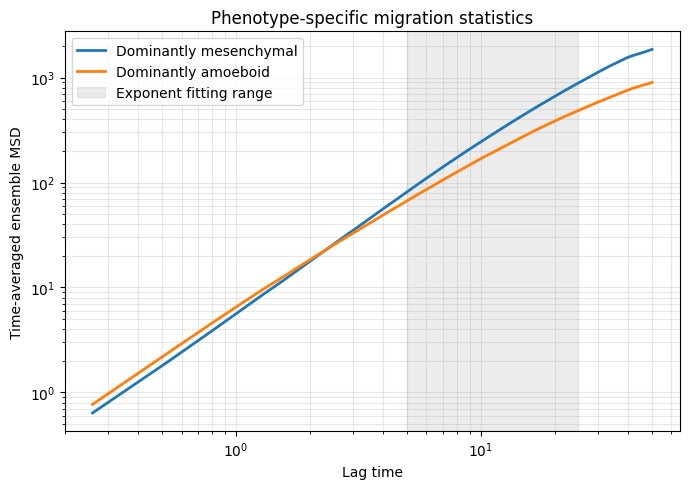

In [86]:
plt.figure(figsize=(7, 5))

plt.loglog(
    mesenchymal_lags,
    mesenchymal_msd,
    label="Dominantly mesenchymal",
    linewidth=2
)

plt.loglog(
    amoeboid_lags,
    amoeboid_msd,
    label="Dominantly amoeboid",
    linewidth=2
)

plt.axvspan(
    5.0,
    25.0,
    color="gray",
    alpha=0.15,
    label="Exponent fitting range"
)

plt.xlabel("Lag time")
plt.ylabel("Time-averaged ensemble MSD")
plt.title("Phenotype-specific migration statistics")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Phenotype-specific calibration and validation

Separate dominantly mesenchymal and dominantly amoeboid trajectories, screen candidate motility parameters, and evaluate the selected parameters on independent held-out seeds.


In [87]:
def evaluate_phenotype_parameters(
    replicate_seeds
):
    pooled_positions = []
    pooled_states = []

    for simulation_seed in replicate_seeds:
        initial_positions = (
            create_initial_colony_positions(
                seed=simulation_seed + 1000
            )
        )

        for flow_value in [0.0, 1.0]:
            result = (
                simulate_interacting_mechanistic_colony(
                    local_flow_speed=flow_value,
                    seed=simulation_seed,
                    initial_positions=initial_positions
                )
            )

            pooled_positions.append(
                result["positions"][sampled_indices]
            )

            pooled_states.append(
                result["phenotypes"][sampled_indices]
            )

    pooled_positions = np.concatenate(
        pooled_positions,
        axis=1
    )

    pooled_states = np.concatenate(
        pooled_states,
        axis=1
    )

    mesenchymal_fraction = pooled_states.mean(
        axis=0
    )

    mesenchymal_mask = (
        mesenchymal_fraction >= 0.5
    )

    amoeboid_mask = ~mesenchymal_mask

    persistence = trajectory_persistence(
        pooled_positions
    )

    speed = mean_speed_per_cell(
        pooled_positions,
        sampled_time
    )

    alpha_M, _, _ = (
        phenotype_group_msd_exponent(
            pooled_positions,
            mesenchymal_mask
        )
    )

    alpha_A, _, _ = (
        phenotype_group_msd_exponent(
            pooled_positions,
            amoeboid_mask
        )
    )

    return np.array([
        persistence[mesenchymal_mask].mean(),
        persistence[amoeboid_mask].mean(),
        alpha_M,
        alpha_A,
        speed[amoeboid_mask].mean()
        / speed[mesenchymal_mask].mean(),
        mesenchymal_mask.sum(),
        amoeboid_mask.sum()
    ])

In [88]:
# Save baseline parameters
saved_D = D
saved_tau_A = tau_amoeboid
saved_tau_M = tau_mesenchymal
saved_speed_A = speed_amoeboid

# Candidate sets chosen to balance increased
# positional noise with increased active persistence
joint_candidates = [
    (0.25, 0.50, 12.0),
    (0.35, 0.60, 14.0),
    (0.35, 0.75, 16.0),
    (0.35, 1.00, 18.0),
    (0.45, 0.60, 14.0),
    (0.45, 0.75, 16.0),
    (0.45, 1.00, 18.0),
    (0.55, 0.75, 16.0),
    (0.55, 1.00, 18.0)
]

# Keep active-speed ratio fixed
speed_amoeboid = 2.20

phenotype_targets = np.array([
    0.21,  # mesenchymal persistence
    0.13,  # amoeboid persistence
    1.46,  # mesenchymal MSD exponent
    1.27,  # amoeboid MSD exponent
    1.09   # approximate A/M speed ratio
])

# Approximate calibration tolerances
phenotype_scales = np.array([
    0.02,
    0.02,
    0.05,
    0.05,
    0.05
])

joint_screening_results = []

calibration_seeds = [
    40000,
    40001,
    40002
]

for candidate_index, (
    candidate_D,
    candidate_tau_A,
    candidate_tau_M
) in enumerate(joint_candidates):

    D = candidate_D
    tau_amoeboid = candidate_tau_A
    tau_mesenchymal = candidate_tau_M

    metrics = evaluate_phenotype_parameters(
        calibration_seeds
    )

    standardized_errors = (
        metrics[:5] - phenotype_targets
    ) / phenotype_scales

    score = np.mean(
        standardized_errors**2
    )

    joint_screening_results.append({
        "D": candidate_D,
        "tau_A": candidate_tau_A,
        "tau_M": candidate_tau_M,
        "P_M": metrics[0],
        "P_A": metrics[1],
        "alpha_M": metrics[2],
        "alpha_A": metrics[3],
        "speed_ratio": metrics[4],
        "n_M": int(metrics[5]),
        "n_A": int(metrics[6]),
        "score": score
    })

    print(
        "Completed joint candidate",
        candidate_index + 1,
        "of",
        len(joint_candidates)
    )

# Restore baseline until a candidate is selected
D = saved_D
tau_amoeboid = saved_tau_A
tau_mesenchymal = saved_tau_M
speed_amoeboid = saved_speed_A

Completed joint candidate 1 of 9
Completed joint candidate 2 of 9
Completed joint candidate 3 of 9
Completed joint candidate 4 of 9
Completed joint candidate 5 of 9
Completed joint candidate 6 of 9
Completed joint candidate 7 of 9
Completed joint candidate 8 of 9
Completed joint candidate 9 of 9


In [89]:
joint_screening_results = sorted(
    joint_screening_results,
    key=lambda result: result["score"]
)

print(
    "D | Tau_A | Tau_M | P_M | P_A | "
    "Alpha_M | Alpha_A | Speed A/M | "
    "n_M | n_A | Score"
)

for result in joint_screening_results:
    print(
        f"{result['D']:.2f} | "
        f"{result['tau_A']:.2f} | "
        f"{result['tau_M']:.1f} | "
        f"{result['P_M']:.3f} | "
        f"{result['P_A']:.3f} | "
        f"{result['alpha_M']:.3f} | "
        f"{result['alpha_A']:.3f} | "
        f"{result['speed_ratio']:.3f} | "
        f"{result['n_M']:3d} | "
        f"{result['n_A']:3d} | "
        f"{result['score']:.3f}"
    )

D | Tau_A | Tau_M | P_M | P_A | Alpha_M | Alpha_A | Speed A/M | n_M | n_A | Score
0.45 | 0.60 | 14.0 | 0.277 | 0.195 | 1.457 | 1.311 | 1.067 |  36 |  60 | 4.515
0.55 | 0.75 | 16.0 | 0.279 | 0.201 | 1.474 | 1.310 | 1.057 |  36 |  60 | 5.093
0.35 | 0.60 | 14.0 | 0.293 | 0.205 | 1.461 | 1.319 | 1.079 |  36 |  60 | 6.477
0.25 | 0.50 | 12.0 | 0.294 | 0.204 | 1.442 | 1.320 | 1.099 |  36 |  60 | 6.522
0.45 | 0.75 | 16.0 | 0.293 | 0.209 | 1.478 | 1.314 | 1.066 |  36 |  60 | 6.785
0.55 | 1.00 | 18.0 | 0.299 | 0.215 | 1.498 | 1.314 | 1.055 |  36 |  60 | 7.980
0.35 | 0.75 | 16.0 | 0.311 | 0.218 | 1.486 | 1.318 | 1.078 |  36 |  60 | 9.268
0.45 | 1.00 | 18.0 | 0.315 | 0.224 | 1.505 | 1.318 | 1.063 |  36 |  60 | 10.363
0.35 | 1.00 | 18.0 | 0.332 | 0.234 | 1.510 | 1.322 | 1.074 |  36 |  60 | 13.348


In [91]:
# Find the exact parameter names currently defined

parameter_names = [
    name for name in list(globals())
    if any(
        keyword in name.lower()
        for keyword in ["tau", "speed", "diffusion"]
    )
]

for name in sorted(parameter_names):
    value = globals()[name]

    if np.isscalar(value):
        print(f"{name} = {value}")

baseline_speed_A = 2.2
baseline_tau_A = 0.5
baseline_tau_M = 12.0
candidate_speed_A = 2.4
candidate_tau_A = 1.0
candidate_tau_M = 18.0
flow_speed = 1.0
interacting_speed_no_flow = 2.7894243682895836
interacting_speed_with_flow = 2.9820495625948893
no_flow_speed = 0.0
original_speed_A = 2.2
original_speed_amoeboid = 2.2
original_tau_A = 0.5
original_tau_M = 12.0
original_tau_amoeboid = 0.5
saved_speed_A = 2.2
saved_tau_A = 0.5
saved_tau_M = 12.0
speed_amoeboid = 2.2
speed_mesenchymal = 1.0
speed_no_flow = 2.8277609166577973
speed_with_flow = 2.925559745615003
steady_speed_no_flow = 2.82076541385219
steady_speed_with_flow = 2.9782654848075296
tau_amoeboid = 0.5
tau_mesenchymal = 12.0


In [93]:
# Restore the baseline parameters after the interrupted search

D = saved_D
tau_amoeboid = saved_tau_amoeboid
tau_mesenchymal = saved_tau_mesenchymal
speed_amoeboid = saved_speed_amoeboid

# Inspect exactly what the evaluation function returns

test_result = evaluate_phenotype_parameters(
    replicate_seeds=[41000]
)

print("Return type:", type(test_result))
print("Return value:")
print(test_result)

if hasattr(test_result, "shape"):
    print("Shape:", test_result.shape)

if isinstance(test_result, (tuple, list)):
    print("Number of returned items:", len(test_result))

    for index, item in enumerate(test_result):
        print(
            f"Item {index}:",
            type(item),
            np.shape(item),
            item
        )

Return type: <class 'numpy.ndarray'>
Return value:
[ 0.29199073  0.18815188  1.68230582  1.35266027  1.07354496 11.
 21.        ]
Shape: (7,)


In [94]:
# Cell 85 — focused parameter search

focused_candidates = [
    # D, tau_A, tau_M, speed_A
    (0.60, 0.70, 16.0, 2.20),
    (0.60, 0.90, 18.0, 2.20),
    (0.60, 1.10, 20.0, 2.20),

    (0.75, 0.80, 18.0, 2.20),
    (0.75, 1.00, 20.0, 2.20),
    (0.75, 1.20, 24.0, 2.20),

    (0.90, 0.90, 20.0, 2.20),
    (0.90, 1.20, 24.0, 2.20),
    (0.90, 1.50, 28.0, 2.20),
]

target_values = np.array([
    0.21,   # mesenchymal persistence
    0.13,   # amoeboid persistence
    1.46,   # mesenchymal MSD exponent
    1.27,   # amoeboid MSD exponent
    1.09    # amoeboid/mesenchymal speed ratio
])

target_scales = np.array([
    0.02,
    0.02,
    0.05,
    0.05,
    0.05
])

focused_results = []

# Save current parameters
saved_D = D
saved_tau_amoeboid = tau_amoeboid
saved_tau_mesenchymal = tau_mesenchymal
saved_speed_amoeboid = speed_amoeboid

screening_seeds = [41000, 41001, 41002]

try:
    for (
        candidate_D,
        candidate_tau_A,
        candidate_tau_M,
        candidate_speed_A
    ) in focused_candidates:

        D = candidate_D
        tau_amoeboid = candidate_tau_A
        tau_mesenchymal = candidate_tau_M
        speed_amoeboid = candidate_speed_A

        result = evaluate_phenotype_parameters(
            replicate_seeds=screening_seeds
        )

        # Function output:
        # [P_M, P_A, alpha_M, alpha_A,
        #  speed_ratio, n_M, n_A]

        P_M = result[0]
        P_A = result[1]
        alpha_M = result[2]
        alpha_A = result[3]
        speed_ratio = result[4]
        n_M = int(result[5])
        n_A = int(result[6])

        simulated_values = np.array([
            P_M,
            P_A,
            alpha_M,
            alpha_A,
            speed_ratio
        ])

        score = np.mean(
            (
                (simulated_values - target_values)
                / target_scales
            ) ** 2
        )

        focused_results.append({
            "D": candidate_D,
            "tau_A": candidate_tau_A,
            "tau_M": candidate_tau_M,
            "speed_A": candidate_speed_A,
            "P_M": P_M,
            "P_A": P_A,
            "alpha_M": alpha_M,
            "alpha_A": alpha_A,
            "speed_ratio": speed_ratio,
            "n_M": n_M,
            "n_A": n_A,
            "score": score
        })

finally:
    # Restore parameters even if an error occurs
    D = saved_D
    tau_amoeboid = saved_tau_amoeboid
    tau_mesenchymal = saved_tau_mesenchymal
    speed_amoeboid = saved_speed_amoeboid

focused_results = sorted(
    focused_results,
    key=lambda item: item["score"]
)

print(
    "D | Tau_A | Tau_M | P_M | P_A | "
    "Alpha_M | Alpha_A | Speed A/M | n_M | n_A | Score"
)

for result in focused_results:
    print(
        f"{result['D']:4.2f} | "
        f"{result['tau_A']:5.2f} | "
        f"{result['tau_M']:5.1f} | "
        f"{result['P_M']:5.3f} | "
        f"{result['P_A']:5.3f} | "
        f"{result['alpha_M']:7.3f} | "
        f"{result['alpha_A']:7.3f} | "
        f"{result['speed_ratio']:9.3f} | "
        f"{result['n_M']:3d} | "
        f"{result['n_A']:3d} | "
        f"{result['score']:5.3f}"
    )

D | Tau_A | Tau_M | P_M | P_A | Alpha_M | Alpha_A | Speed A/M | n_M | n_A | Score
0.90 |  0.90 |  20.0 | 0.221 | 0.164 |   1.515 |   1.286 |     1.057 |  33 |  63 | 1.004
0.75 |  0.80 |  18.0 | 0.227 | 0.166 |   1.515 |   1.285 |     1.066 |  33 |  63 | 1.119
0.60 |  0.70 |  16.0 | 0.233 | 0.168 |   1.512 |   1.288 |     1.072 |  33 |  63 | 1.286
0.75 |  1.00 |  20.0 | 0.238 | 0.178 |   1.528 |   1.298 |     1.068 |  33 |  63 | 1.993
0.90 |  1.20 |  24.0 | 0.237 | 0.181 |   1.536 |   1.304 |     1.059 |  33 |  63 | 2.316
0.60 |  0.90 |  18.0 | 0.248 | 0.182 |   1.528 |   1.291 |     1.075 |  33 |  63 | 2.525
0.75 |  1.20 |  24.0 | 0.250 | 0.190 |   1.543 |   1.311 |     1.065 |  33 |  63 | 3.334
0.60 |  1.10 |  20.0 | 0.258 | 0.194 |   1.536 |   1.305 |     1.078 |  33 |  63 | 3.773
0.90 |  1.50 |  28.0 | 0.249 | 0.194 |   1.553 |   1.324 |     1.057 |  33 |  63 | 3.835


In [95]:
# Cell 86 — final local parameter screening

final_screen_candidates = [
    # D, tau_A, tau_M, speed_A

    (0.90, 0.70, 18.0, 2.20),
    (0.90, 0.80, 18.0, 2.30),
    (0.90, 0.90, 20.0, 2.30),

    (1.00, 0.70, 18.0, 2.30),
    (1.00, 0.80, 18.0, 2.30),
    (1.00, 0.90, 20.0, 2.30),

    (1.10, 0.70, 18.0, 2.30),
    (1.10, 0.80, 20.0, 2.30),
    (1.10, 0.90, 20.0, 2.40),

    (1.20, 0.70, 18.0, 2.30),
    (1.20, 0.80, 20.0, 2.40),
    (1.20, 0.90, 22.0, 2.40),
]

target_values = np.array([
    0.21,
    0.13,
    1.46,
    1.27,
    1.09
])

target_scales = np.array([
    0.02,
    0.02,
    0.05,
    0.05,
    0.05
])

final_screen_results = []

saved_D = D
saved_tau_amoeboid = tau_amoeboid
saved_tau_mesenchymal = tau_mesenchymal
saved_speed_amoeboid = speed_amoeboid

screening_seeds = [42000, 42001, 42002]

try:
    for (
        candidate_D,
        candidate_tau_A,
        candidate_tau_M,
        candidate_speed_A
    ) in final_screen_candidates:

        D = candidate_D
        tau_amoeboid = candidate_tau_A
        tau_mesenchymal = candidate_tau_M
        speed_amoeboid = candidate_speed_A

        result = evaluate_phenotype_parameters(
            replicate_seeds=screening_seeds
        )

        P_M, P_A = result[0], result[1]
        alpha_M, alpha_A = result[2], result[3]
        speed_ratio = result[4]
        n_M, n_A = int(result[5]), int(result[6])

        simulated_values = np.array([
            P_M,
            P_A,
            alpha_M,
            alpha_A,
            speed_ratio
        ])

        score = np.mean(
            (
                (simulated_values - target_values)
                / target_scales
            ) ** 2
        )

        final_screen_results.append({
            "D": candidate_D,
            "tau_A": candidate_tau_A,
            "tau_M": candidate_tau_M,
            "speed_A": candidate_speed_A,
            "P_M": P_M,
            "P_A": P_A,
            "alpha_M": alpha_M,
            "alpha_A": alpha_A,
            "speed_ratio": speed_ratio,
            "n_M": n_M,
            "n_A": n_A,
            "score": score
        })

finally:
    D = saved_D
    tau_amoeboid = saved_tau_amoeboid
    tau_mesenchymal = saved_tau_mesenchymal
    speed_amoeboid = saved_speed_amoeboid

final_screen_results = sorted(
    final_screen_results,
    key=lambda item: item["score"]
)

print(
    "D | Tau_A | Tau_M | Speed_A | P_M | P_A | "
    "Alpha_M | Alpha_A | Speed A/M | n_M | n_A | Score"
)

for result in final_screen_results:
    print(
        f"{result['D']:4.2f} | "
        f"{result['tau_A']:5.2f} | "
        f"{result['tau_M']:5.1f} | "
        f"{result['speed_A']:7.2f} | "
        f"{result['P_M']:5.3f} | "
        f"{result['P_A']:5.3f} | "
        f"{result['alpha_M']:7.3f} | "
        f"{result['alpha_A']:7.3f} | "
        f"{result['speed_ratio']:9.3f} | "
        f"{result['n_M']:3d} | "
        f"{result['n_A']:3d} | "
        f"{result['score']:5.3f}"
    )

D | Tau_A | Tau_M | Speed_A | P_M | P_A | Alpha_M | Alpha_A | Speed A/M | n_M | n_A | Score
1.20 |  0.70 |  18.0 |    2.30 | 0.249 | 0.171 |   1.520 |   1.295 |     1.031 |  36 |  60 | 2.201
1.10 |  0.70 |  18.0 |    2.30 | 0.256 | 0.175 |   1.526 |   1.298 |     1.034 |  36 |  60 | 2.703
1.00 |  0.70 |  18.0 |    2.30 | 0.263 | 0.178 |   1.532 |   1.296 |     1.039 |  36 |  60 | 3.243
0.90 |  0.70 |  18.0 |    2.20 | 0.266 | 0.179 |   1.533 |   1.297 |     1.037 |  36 |  60 | 3.498
1.00 |  0.80 |  18.0 |    2.30 | 0.266 | 0.181 |   1.539 |   1.296 |     1.039 |  36 |  60 | 3.633
1.20 |  0.80 |  20.0 |    2.40 | 0.264 | 0.180 |   1.555 |   1.301 |     1.035 |  36 |  60 | 3.730
1.10 |  0.80 |  20.0 |    2.30 | 0.264 | 0.180 |   1.553 |   1.301 |     1.033 |  36 |  60 | 3.743
0.90 |  0.80 |  18.0 |    2.30 | 0.277 | 0.186 |   1.548 |   1.296 |     1.042 |  36 |  60 | 4.643
1.10 |  0.90 |  20.0 |    2.40 | 0.273 | 0.188 |   1.565 |   1.303 |     1.037 |  36 |  60 | 4.861
1.20 |  0.90 |  2

In [96]:
# Cell 87 — independent 10-seed validation of three finalists

validation_candidates = [
    {
        "name": "Earlier best",
        "D": 0.90,
        "tau_A": 0.90,
        "tau_M": 20.0,
        "speed_A": 2.20
    },
    {
        "name": "Earlier best, higher speed",
        "D": 0.90,
        "tau_A": 0.90,
        "tau_M": 20.0,
        "speed_A": 2.30
    },
    {
        "name": "Current best",
        "D": 1.20,
        "tau_A": 0.70,
        "tau_M": 18.0,
        "speed_A": 2.30
    }
]

validation_seeds = list(range(50000, 50010))

target_values = np.array([
    0.21,
    0.13,
    1.46,
    1.27,
    1.09
])

target_scales = np.array([
    0.02,
    0.02,
    0.05,
    0.05,
    0.05
])

saved_D = D
saved_tau_amoeboid = tau_amoeboid
saved_tau_mesenchymal = tau_mesenchymal
saved_speed_amoeboid = speed_amoeboid

validation_results = []

try:
    for candidate in validation_candidates:

        D = candidate["D"]
        tau_amoeboid = candidate["tau_A"]
        tau_mesenchymal = candidate["tau_M"]
        speed_amoeboid = candidate["speed_A"]

        replicate_results = []

        for seed in validation_seeds:
            result = evaluate_phenotype_parameters(
                replicate_seeds=[seed]
            )

            replicate_results.append(result)

        replicate_results = np.asarray(
            replicate_results,
            dtype=float
        )

        metric_values = replicate_results[:, :5]

        metric_means = np.nanmean(
            metric_values,
            axis=0
        )

        metric_sds = np.nanstd(
            metric_values,
            axis=0,
            ddof=1
        )

        total_n_M = int(
            np.nansum(replicate_results[:, 5])
        )

        total_n_A = int(
            np.nansum(replicate_results[:, 6])
        )

        score = np.mean(
            (
                (metric_means - target_values)
                / target_scales
            ) ** 2
        )

        validation_results.append({
            **candidate,
            "means": metric_means,
            "sds": metric_sds,
            "n_M": total_n_M,
            "n_A": total_n_A,
            "score": score
        })

finally:
    D = saved_D
    tau_amoeboid = saved_tau_amoeboid
    tau_mesenchymal = saved_tau_mesenchymal
    speed_amoeboid = saved_speed_amoeboid

validation_results = sorted(
    validation_results,
    key=lambda item: item["score"]
)

metric_names = [
    "P_M",
    "P_A",
    "Alpha_M",
    "Alpha_A",
    "Speed A/M"
]

for candidate in validation_results:
    print()
    print(candidate["name"])

    print(
        "Parameters:",
        f"D={candidate['D']},",
        f"Tau_A={candidate['tau_A']},",
        f"Tau_M={candidate['tau_M']},",
        f"Speed_A={candidate['speed_A']}"
    )

    print("Metric | Mean | SD | Target")

    for index, metric_name in enumerate(metric_names):
        print(
            f"{metric_name:9s} | "
            f"{candidate['means'][index]:6.3f} | "
            f"{candidate['sds'][index]:6.3f} | "
            f"{target_values[index]:6.3f}"
        )

    print(
        "Phenotype counts:",
        f"n_M={candidate['n_M']},",
        f"n_A={candidate['n_A']}"
    )

    print(
        "Validation score:",
        candidate["score"]
    )


Current best
Parameters: D=1.2, Tau_A=0.7, Tau_M=18.0, Speed_A=2.3
Metric | Mean | SD | Target
P_M       |  0.229 |  0.024 |  0.210
P_A       |  0.157 |  0.021 |  0.130
Alpha_M   |  1.476 |  0.082 |  1.460
Alpha_A   |  1.198 |  0.104 |  1.270
Speed A/M |  1.034 |  0.015 |  1.090
Phenotype counts: n_M=118, n_A=202
Validation score: 1.2166441136979311

Earlier best
Parameters: D=0.9, Tau_A=0.9, Tau_M=20.0, Speed_A=2.2
Metric | Mean | SD | Target
P_M       |  0.258 |  0.028 |  0.210
P_A       |  0.179 |  0.022 |  0.130
Alpha_M   |  1.501 |  0.076 |  1.460
Alpha_A   |  1.221 |  0.106 |  1.270
Speed A/M |  1.040 |  0.019 |  1.090
Phenotype counts: n_M=118, n_A=202
Validation score: 2.8890336770085647

Earlier best, higher speed
Parameters: D=0.9, Tau_A=0.9, Tau_M=20.0, Speed_A=2.3
Metric | Mean | SD | Target
P_M       |  0.265 |  0.029 |  0.210
P_A       |  0.183 |  0.022 |  0.130
Alpha_M   |  1.504 |  0.075 |  1.460
Alpha_A   |  1.225 |  0.104 |  1.270
Speed A/M |  1.044 |  0.020 |  1.090

## 11. Frozen Version 2 model

Freeze the selected parameter set before final held-out evaluation. Subsequent digital-twin tests use these values without retuning to individual trajectories.


In [97]:
# Cell 88 — freeze the independently validated V2 parameters

D = 1.20
tau_amoeboid = 0.70
tau_mesenchymal = 18.0
speed_amoeboid = 2.30
speed_mesenchymal = 1.00

frozen_v2_parameters = {
    "D": D,
    "tau_amoeboid": tau_amoeboid,
    "tau_mesenchymal": tau_mesenchymal,
    "speed_amoeboid": speed_amoeboid,
    "speed_mesenchymal": speed_mesenchymal
}

print("Frozen Version 2 parameters")

for parameter_name, parameter_value in frozen_v2_parameters.items():
    print(
        f"{parameter_name}: {parameter_value}"
    )

Frozen Version 2 parameters
D: 1.2
tau_amoeboid: 0.7
tau_mesenchymal: 18.0
speed_amoeboid: 2.3
speed_mesenchymal: 1.0


In [98]:
# Cell 89 — final held-out phenotype-specific evaluation

final_test_seeds = list(range(60000, 60020))

final_test_results = []

for seed in final_test_seeds:
    result = evaluate_phenotype_parameters(
        replicate_seeds=[seed]
    )

    final_test_results.append(result)

final_test_results = np.asarray(
    final_test_results,
    dtype=float
)

# Columns:
# P_M, P_A, alpha_M, alpha_A,
# speed_ratio, n_M, n_A

final_metric_values = final_test_results[:, :5]

final_metric_means = np.nanmean(
    final_metric_values,
    axis=0
)

final_metric_sds = np.nanstd(
    final_metric_values,
    axis=0,
    ddof=1
)

final_metric_standard_errors = (
    final_metric_sds
    / np.sqrt(
        np.sum(
            np.isfinite(final_metric_values),
            axis=0
        )
    )
)

final_targets = np.array([
    0.21,
    0.13,
    1.46,
    1.27,
    1.09
])

final_metric_names = [
    "Mesenchymal persistence",
    "Amoeboid persistence",
    "Mesenchymal MSD exponent",
    "Amoeboid MSD exponent",
    "Amoeboid/mesenchymal speed ratio"
]

print("FINAL HELD-OUT EVALUATION")
print("Metric | Mean | SD | SE | Experimental target")

for index, metric_name in enumerate(final_metric_names):
    print(
        f"{metric_name:31s} | "
        f"{final_metric_means[index]:6.3f} | "
        f"{final_metric_sds[index]:6.3f} | "
        f"{final_metric_standard_errors[index]:6.3f} | "
        f"{final_targets[index]:6.3f}"
    )

print()
print(
    "Total dominantly mesenchymal trajectories:",
    int(np.nansum(final_test_results[:, 5]))
)

print(
    "Total dominantly amoeboid trajectories:",
    int(np.nansum(final_test_results[:, 6]))
)

print(
    "Number of independent replicates:",
    len(final_test_seeds)
)

FINAL HELD-OUT EVALUATION
Metric | Mean | SD | SE | Experimental target
Mesenchymal persistence         |  0.217 |  0.036 |  0.008 |  0.210
Amoeboid persistence            |  0.151 |  0.019 |  0.004 |  0.130
Mesenchymal MSD exponent        |  1.444 |  0.122 |  0.027 |  1.460
Amoeboid MSD exponent           |  1.212 |  0.101 |  0.023 |  1.270
Amoeboid/mesenchymal speed ratio |  1.045 |  0.021 |  0.005 |  1.090

Total dominantly mesenchymal trajectories: 257
Total dominantly amoeboid trajectories: 383
Number of independent replicates: 20


In [99]:
# Cell 90 — inspect the final interacting-colony simulator

import inspect

print(
    "Function signature:",
    inspect.signature(
        simulate_interacting_mechanistic_colony
    )
)

print()
print("First lines of the function:")

source_lines = inspect.getsource(
    simulate_interacting_mechanistic_colony
).splitlines()

for line in source_lines[:35]:
    print(line)

Function signature: (local_flow_speed, seed, initial_positions)

First lines of the function:
def simulate_interacting_mechanistic_colony(
    local_flow_speed,
    seed,
    initial_positions
):
    rng = np.random.default_rng(seed)

    number_of_cells = initial_positions.shape[0]

    (
        fibronectin,
        adhesion,
        equilibrium_mesenchymal_fraction
    ) = matrix_equilibrium(local_flow_speed)

    positions = initial_positions.copy()

    phenotypes = (
        rng.random(number_of_cells)
        < equilibrium_mesenchymal_fraction
    )

    active_speed_scales = np.where(
        phenotypes,
        speed_mesenchymal,
        speed_amoeboid
    )

    active_velocity = (
        active_speed_scales[:, np.newaxis]
        * rng.normal(size=(number_of_cells, 2))
    )

    position_history = np.zeros(
        (n_steps + 1, number_of_cells, 2)


In [100]:
# Cell 91 — inspect the end of the colony simulator

source_lines = inspect.getsource(
    simulate_interacting_mechanistic_colony
).splitlines()

print("Last lines of the function:")

for line in source_lines[-35:]:
    print(line)

Last lines of the function:
        )

        # Translational fluctuations
        position_noise = rng.normal(
            size=(number_of_cells, 2)
        )

        positions = (
            positions
            + active_velocity * dt
            + cell_mobility
            * interaction_forces
            * dt
            + np.sqrt(2.0 * D * dt)
            * position_noise
        )

        # Enforce excluded-volume constraint
        positions = resolve_hard_core_overlaps(
            positions,
            cell_diameter=effective_cell_diameter,
            number_of_passes=10
        )

        position_history[step + 1] = positions
        velocity_history[step + 1] = active_velocity
        phenotype_history[step + 1] = phenotypes

    return {
        "positions": position_history,
        "velocities": velocity_history,
        "phenotypes": phenotype_history,
        "fibronectin": fibronectin_history,
        "adhesion": adhesion_history
    }


In [101]:
# Cell 92 — final paired no-flow versus flow colony experiment

final_colony_seeds = list(range(70000, 70020))

def final_colony_statistics(simulation):
    positions = simulation["positions"]
    phenotypes = simulation["phenotypes"]

    final_positions = positions[-1]

    center_of_mass = final_positions.mean(axis=0)

    radius = np.sqrt(
        np.mean(
            np.sum(
                (final_positions - center_of_mass) ** 2,
                axis=1
            )
        )
    )

    displacement_matrix = (
        final_positions[:, np.newaxis, :]
        - final_positions[np.newaxis, :, :]
    )

    distance_matrix = np.sqrt(
        np.sum(displacement_matrix**2, axis=2)
    )

    number_of_cells = len(final_positions)

    diagonal_mask = np.eye(
        number_of_cells,
        dtype=bool
    )

    distance_without_diagonal = distance_matrix.copy()
    distance_without_diagonal[diagonal_mask] = np.inf

    nearest_neighbor_distance = np.mean(
        np.min(
            distance_without_diagonal,
            axis=1
        )
    )

    upper_triangle = np.triu_indices(
        number_of_cells,
        k=1
    )

    pair_distances = distance_matrix[
        upper_triangle
    ]

    minimum_separation = np.min(
        pair_distances
    )

    overlapping_pairs = np.sum(
        pair_distances
        < 0.99 * effective_cell_diameter
    )

    close_pairs = np.sum(
        pair_distances
        < 1.5 * effective_cell_diameter
    )

    late_start = int(
        0.8 * len(phenotypes)
    )

    late_mesenchymal_fraction = np.mean(
        phenotypes[late_start:]
    )

    return np.array([
        radius,
        nearest_neighbor_distance,
        minimum_separation,
        overlapping_pairs,
        close_pairs,
        late_mesenchymal_fraction
    ])


no_flow_colony_results = []
flow_colony_results = []

for replicate_index, seed in enumerate(final_colony_seeds):

    no_flow_simulation = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=0.0,
            seed=seed,
            initial_positions=initial_colony_positions
        )
    )

    flow_simulation = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=flow_speed,
            seed=seed,
            initial_positions=initial_colony_positions
        )
    )

    no_flow_colony_results.append(
        final_colony_statistics(
            no_flow_simulation
        )
    )

    flow_colony_results.append(
        final_colony_statistics(
            flow_simulation
        )
    )

    print(
        "Completed paired replicate",
        replicate_index + 1,
        "of",
        len(final_colony_seeds)
    )

no_flow_colony_results = np.asarray(
    no_flow_colony_results
)

flow_colony_results = np.asarray(
    flow_colony_results
)

colony_metric_names = [
    "Final colony radius",
    "Final nearest-neighbor distance",
    "Final minimum separation",
    "Overlapping pairs",
    "Close pairs",
    "Late mesenchymal fraction"
]

print()
print(
    "Metric | No-flow mean | No-flow SD | "
    "Flow mean | Flow SD | Paired difference"
)

for metric_index, metric_name in enumerate(
    colony_metric_names
):
    no_flow_values = (
        no_flow_colony_results[:, metric_index]
    )

    flow_values = (
        flow_colony_results[:, metric_index]
    )

    paired_differences = (
        flow_values - no_flow_values
    )

    print(
        f"{metric_name:31s} | "
        f"{np.mean(no_flow_values):12.3f} | "
        f"{np.std(no_flow_values, ddof=1):10.3f} | "
        f"{np.mean(flow_values):9.3f} | "
        f"{np.std(flow_values, ddof=1):7.3f} | "
        f"{np.mean(paired_differences):16.3f}"
    )

print()
print(
    "Replicates with larger radius under flow:",
    np.sum(
        flow_colony_results[:, 0]
        > no_flow_colony_results[:, 0]
    ),
    "out of",
    len(final_colony_seeds)
)

print(
    "Replicates with larger neighbor distance under flow:",
    np.sum(
        flow_colony_results[:, 1]
        > no_flow_colony_results[:, 1]
    ),
    "out of",
    len(final_colony_seeds)
)

print(
    "All results finite:",
    np.all(np.isfinite(no_flow_colony_results))
    and np.all(np.isfinite(flow_colony_results))
)

Completed paired replicate 1 of 20
Completed paired replicate 2 of 20
Completed paired replicate 3 of 20
Completed paired replicate 4 of 20
Completed paired replicate 5 of 20
Completed paired replicate 6 of 20
Completed paired replicate 7 of 20
Completed paired replicate 8 of 20
Completed paired replicate 9 of 20
Completed paired replicate 10 of 20
Completed paired replicate 11 of 20
Completed paired replicate 12 of 20
Completed paired replicate 13 of 20
Completed paired replicate 14 of 20
Completed paired replicate 15 of 20
Completed paired replicate 16 of 20
Completed paired replicate 17 of 20
Completed paired replicate 18 of 20
Completed paired replicate 19 of 20
Completed paired replicate 20 of 20

Metric | No-flow mean | No-flow SD | Flow mean | Flow SD | Paired difference
Final colony radius             |       52.257 |      7.471 |    42.670 |   5.796 |           -9.588
Final nearest-neighbor distance |       22.304 |      4.028 |    17.258 |   3.937 |           -5.046
Final min

In [102]:
# Cell 93 — paired effect sizes and confidence intervals

from scipy import stats

comparison_indices = [
    0,  # radius
    1,  # nearest-neighbor distance
    5   # mesenchymal fraction
]

print(
    "Metric | Flow-no-flow mean | 95% CI | "
    "Paired p-value | Relative change"
)

for metric_index in comparison_indices:

    no_flow_values = (
        no_flow_colony_results[:, metric_index]
    )

    flow_values = (
        flow_colony_results[:, metric_index]
    )

    paired_difference = (
        flow_values - no_flow_values
    )

    mean_difference = np.mean(
        paired_difference
    )

    standard_error = stats.sem(
        paired_difference
    )

    confidence_interval = stats.t.interval(
        confidence=0.95,
        df=len(paired_difference) - 1,
        loc=mean_difference,
        scale=standard_error
    )

    test_result = stats.ttest_rel(
        flow_values,
        no_flow_values
    )

    relative_change = (
        100.0
        * mean_difference
        / np.mean(no_flow_values)
    )

    print(
        f"{colony_metric_names[metric_index]:31s} | "
        f"{mean_difference:8.3f} | "
        f"[{confidence_interval[0]:7.3f}, "
        f"{confidence_interval[1]:7.3f}] | "
        f"{test_result.pvalue:13.4g} | "
        f"{relative_change:8.1f}%"
    )

Metric | Flow-no-flow mean | 95% CI | Paired p-value | Relative change
Final colony radius             |   -9.588 | [-12.808,  -6.367] |     5.512e-06 |    -18.3%
Final nearest-neighbor distance |   -5.046 | [ -7.439,  -2.654] |     0.0002976 |    -22.6%
Late mesenchymal fraction       |   -0.275 | [ -0.336,  -0.214] |     1.345e-08 |    -47.1%


In [103]:
# Cell 94 — cell-cell interaction-force ablation

ablation_seeds = final_colony_seeds[:10]

saved_cell_mobility = cell_mobility

no_flow_no_force_results = []
flow_no_force_results = []

try:
    # Remove the explicit pair-force contribution.
    # Hard-core overlap correction remains active.
    cell_mobility = 0.0

    for replicate_index, seed in enumerate(
        ablation_seeds
    ):
        no_flow_no_force_simulation = (
            simulate_interacting_mechanistic_colony(
                local_flow_speed=0.0,
                seed=seed,
                initial_positions=initial_colony_positions
            )
        )

        flow_no_force_simulation = (
            simulate_interacting_mechanistic_colony(
                local_flow_speed=flow_speed,
                seed=seed,
                initial_positions=initial_colony_positions
            )
        )

        no_flow_no_force_results.append(
            final_colony_statistics(
                no_flow_no_force_simulation
            )
        )

        flow_no_force_results.append(
            final_colony_statistics(
                flow_no_force_simulation
            )
        )

        print(
            "Completed ablation replicate",
            replicate_index + 1,
            "of",
            len(ablation_seeds)
        )

finally:
    cell_mobility = saved_cell_mobility

no_flow_no_force_results = np.asarray(
    no_flow_no_force_results
)

flow_no_force_results = np.asarray(
    flow_no_force_results
)

# Corresponding full-interaction results
no_flow_with_force_results = (
    no_flow_colony_results[:len(ablation_seeds)]
)

flow_with_force_results = (
    flow_colony_results[:len(ablation_seeds)]
)

print()
print(
    "Condition | Radius with force | Radius without force | "
    "Force effect"
)

for (
    condition_name,
    with_force,
    without_force
) in [
    (
        "No flow",
        no_flow_with_force_results,
        no_flow_no_force_results
    ),
    (
        "Flow",
        flow_with_force_results,
        flow_no_force_results
    )
]:
    radius_with_force = with_force[:, 0]
    radius_without_force = without_force[:, 0]

    force_effect = (
        radius_with_force
        - radius_without_force
    )

    confidence_interval = stats.t.interval(
        confidence=0.95,
        df=len(force_effect) - 1,
        loc=np.mean(force_effect),
        scale=stats.sem(force_effect)
    )

    print(
        f"{condition_name:9s} | "
        f"{np.mean(radius_with_force):17.3f} | "
        f"{np.mean(radius_without_force):20.3f} | "
        f"{np.mean(force_effect):8.3f} "
        f"[{confidence_interval[0]:.3f}, "
        f"{confidence_interval[1]:.3f}]"
    )

print()
print(
    "Flow effect on radius with force:",
    np.mean(
        flow_with_force_results[:, 0]
        - no_flow_with_force_results[:, 0]
    )
)

print(
    "Flow effect on radius without force:",
    np.mean(
        flow_no_force_results[:, 0]
        - no_flow_no_force_results[:, 0]
    )
)

print(
    "Cell mobility restored:",
    cell_mobility == saved_cell_mobility
)

Completed ablation replicate 1 of 10
Completed ablation replicate 2 of 10
Completed ablation replicate 3 of 10
Completed ablation replicate 4 of 10
Completed ablation replicate 5 of 10
Completed ablation replicate 6 of 10
Completed ablation replicate 7 of 10
Completed ablation replicate 8 of 10
Completed ablation replicate 9 of 10
Completed ablation replicate 10 of 10

Condition | Radius with force | Radius without force | Force effect
No flow   |            52.330 |               52.355 |   -0.025 [-0.112, 0.062]
Flow      |            39.844 |               39.873 |   -0.029 [-0.129, 0.070]

Flow effect on radius with force: -12.486259375639595
Flow effect on radius without force: -12.481843481841963
Cell mobility restored: True


## 12. Synthetic microscopy experiment

Generate hidden interacting-colony trajectories and noisy position measurements. Hidden states are used only for retrospective evaluation, never by the online estimator.


In [104]:
# Cell 95 — hidden Version 2 experiment and synthetic measurements

v2_truth_seed = 80000
v2_measurement_seed = 80001

v2_measurement_period = 1.0
v2_measurement_std = 0.50

v2_measurement_interval = int(
    round(v2_measurement_period / dt)
)

# Hidden experiment under interstitial flow
v2_hidden_simulation = (
    simulate_interacting_mechanistic_colony(
        local_flow_speed=flow_speed,
        seed=v2_truth_seed,
        initial_positions=initial_colony_positions
    )
)

v2_hidden_positions = (
    v2_hidden_simulation["positions"]
)

v2_hidden_velocities = (
    v2_hidden_simulation["velocities"]
)

v2_hidden_phenotypes = (
    v2_hidden_simulation["phenotypes"]
)

v2_hidden_fibronectin = (
    v2_hidden_simulation["fibronectin"]
)

v2_hidden_adhesion = (
    v2_hidden_simulation["adhesion"]
)

v2_measurement_steps = np.arange(
    0,
    len(v2_hidden_positions),
    v2_measurement_interval
)

v2_measurement_rng = np.random.default_rng(
    v2_measurement_seed
)

v2_measured_positions = (
    v2_hidden_positions[v2_measurement_steps]
    + v2_measurement_rng.normal(
        loc=0.0,
        scale=v2_measurement_std,
        size=v2_hidden_positions[
            v2_measurement_steps
        ].shape
    )
)

v2_measurement_errors = (
    v2_measured_positions
    - v2_hidden_positions[v2_measurement_steps]
)

v2_raw_measurement_rmse = np.sqrt(
    np.mean(
        np.sum(
            v2_measurement_errors**2,
            axis=2
        )
    )
)

print(
    "Hidden position shape:",
    v2_hidden_positions.shape
)

print(
    "Measurement shape:",
    v2_measured_positions.shape
)

print(
    "Number of cells:",
    v2_hidden_positions.shape[1]
)

print(
    "Number of measurement frames:",
    len(v2_measurement_steps)
)

print(
    "Fine steps between measurements:",
    v2_measurement_interval
)

print(
    "Raw measurement RMSE:",
    v2_raw_measurement_rmse
)

print(
    "Initial hidden mesenchymal fraction:",
    np.mean(v2_hidden_phenotypes[0])
)

print(
    "Final hidden mesenchymal fraction:",
    np.mean(v2_hidden_phenotypes[-1])
)

print(
    "Final hidden fibronectin:",
    v2_hidden_fibronectin[-1]
)

print(
    "Final hidden adhesion:",
    v2_hidden_adhesion[-1]
)

print(
    "All measurements finite:",
    np.all(np.isfinite(v2_measured_positions))
)

Hidden position shape: (5001, 16, 2)
Measurement shape: (51, 16, 2)
Number of cells: 16
Number of measurement frames: 51
Fine steps between measurements: 100
Raw measurement RMSE: 0.7222194037686867
Initial hidden mesenchymal fraction: 0.1875
Final hidden mesenchymal fraction: 0.25
Final hidden fibronectin: 0.26666666666666666
Final hidden adhesion: 0.5161290322580645
All measurements finite: True


In [105]:
# Cell 96 — inspect the mechanistic update equations

source_lines = inspect.getsource(
    simulate_interacting_mechanistic_colony
).splitlines()

for line_number, line in enumerate(
    source_lines,
    start=1
):
    print(
        f"{line_number:3d}: {line}"
    )

  1: def simulate_interacting_mechanistic_colony(
  2:     local_flow_speed,
  3:     seed,
  4:     initial_positions
  5: ):
  6:     rng = np.random.default_rng(seed)
  7: 
  8:     number_of_cells = initial_positions.shape[0]
  9: 
 10:     (
 11:         fibronectin,
 12:         adhesion,
 13:         equilibrium_mesenchymal_fraction
 14:     ) = matrix_equilibrium(local_flow_speed)
 15: 
 16:     positions = initial_positions.copy()
 17: 
 18:     phenotypes = (
 19:         rng.random(number_of_cells)
 20:         < equilibrium_mesenchymal_fraction
 21:     )
 22: 
 23:     active_speed_scales = np.where(
 24:         phenotypes,
 25:         speed_mesenchymal,
 26:         speed_amoeboid
 27:     )
 28: 
 29:     active_velocity = (
 30:         active_speed_scales[:, np.newaxis]
 31:         * rng.normal(size=(number_of_cells, 2))
 32:     )
 33: 
 34:     position_history = np.zeros(
 35:         (n_steps + 1, number_of_cells, 2)
 36:     )
 37: 
 38:     velocity_history = 

## 13. Digital-twin state and phenotype assimilation

Propagate an ensemble with the mechanistic equations, assimilate each position measurement, and update latent phenotype probabilities. This implements the prediction → measurement → update → new prediction cycle.


In [106]:
# Cell 97 — initialize Version 2 ensemble and define prediction

v2_ensemble_size = 100
v2_ensemble_rng = np.random.default_rng(81000)

v2_number_of_cells = (
    v2_measured_positions.shape[1]
)

(
    v2_twin_fibronectin,
    v2_twin_adhesion,
    v2_equilibrium_mesenchymal_fraction
) = matrix_equilibrium(flow_speed)

# Initialize positions around the first measurement
v2_ensemble_positions = (
    v2_measured_positions[0][
        np.newaxis, :, :
    ]
    + v2_ensemble_rng.normal(
        loc=0.0,
        scale=v2_measurement_std,
        size=(
            v2_ensemble_size,
            v2_number_of_cells,
            2
        )
    )
)

# Enforce excluded volume for each ensemble member
for member_index in range(v2_ensemble_size):
    v2_ensemble_positions[member_index] = (
        resolve_hard_core_overlaps(
            v2_ensemble_positions[member_index],
            cell_diameter=effective_cell_diameter,
            number_of_passes=10
        )
    )

# Initialize latent phenotypes from the mechanistic equilibrium
v2_ensemble_phenotypes = (
    v2_ensemble_rng.random(
        size=(
            v2_ensemble_size,
            v2_number_of_cells
        )
    )
    < v2_equilibrium_mesenchymal_fraction
)

initial_speed_scales = np.where(
    v2_ensemble_phenotypes,
    speed_mesenchymal,
    speed_amoeboid
)

v2_ensemble_velocities = (
    initial_speed_scales[:, :, np.newaxis]
    * v2_ensemble_rng.normal(
        size=(
            v2_ensemble_size,
            v2_number_of_cells,
            2
        )
    )
)


def predict_v2_ensemble(
    ensemble_positions,
    ensemble_velocities,
    ensemble_phenotypes,
    number_of_fine_steps,
    local_flow_speed,
    rng
):
    predicted_positions = (
        ensemble_positions.copy()
    )

    predicted_velocities = (
        ensemble_velocities.copy()
    )

    predicted_phenotypes = (
        ensemble_phenotypes.copy()
    )

    (
        predicted_fibronectin,
        predicted_adhesion,
        equilibrium_fraction
    ) = matrix_equilibrium(
        local_flow_speed
    )

    rate_A_to_M, rate_M_to_A = (
        phenotype_switching_rates(
            predicted_adhesion
        )
    )

    number_of_members = (
        predicted_positions.shape[0]
    )

    for fine_step in range(
        number_of_fine_steps
    ):
        # Latent phenotype switching
        switching_random_values = rng.random(
            size=predicted_phenotypes.shape
        )

        switch_A_to_M = (
            (~predicted_phenotypes)
            & (
                switching_random_values
                < rate_A_to_M * dt
            )
        )

        switch_M_to_A = (
            predicted_phenotypes
            & (
                switching_random_values
                < rate_M_to_A * dt
            )
        )

        predicted_phenotypes[
            switch_A_to_M
        ] = True

        predicted_phenotypes[
            switch_M_to_A
        ] = False

        persistence_times = np.where(
            predicted_phenotypes,
            tau_mesenchymal,
            tau_amoeboid
        )

        speed_scales = np.where(
            predicted_phenotypes,
            speed_mesenchymal,
            speed_amoeboid
        )

        # Active colored noise
        velocity_noise = rng.normal(
            size=predicted_velocities.shape
        )

        predicted_velocities = (
            predicted_velocities
            - (
                predicted_velocities
                / persistence_times[
                    :, :, np.newaxis
                ]
            )
            * dt
            + speed_scales[
                :, :, np.newaxis
            ]
            * np.sqrt(
                2.0
                * dt
                / persistence_times[
                    :, :, np.newaxis
                ]
            )
            * velocity_noise
        )

        # Pair forces for each ensemble member
        interaction_forces = np.zeros_like(
            predicted_positions
        )

        for member_index in range(
            number_of_members
        ):
            interaction_forces[
                member_index
            ] = (
                calculate_total_cell_cell_forces(
                    predicted_positions[
                        member_index
                    ],
                    predicted_phenotypes[
                        member_index
                    ]
                )
            )

        position_noise = rng.normal(
            size=predicted_positions.shape
        )

        predicted_positions = (
            predicted_positions
            + predicted_velocities * dt
            + cell_mobility
            * interaction_forces
            * dt
            + np.sqrt(2.0 * D * dt)
            * position_noise
        )

        for member_index in range(
            number_of_members
        ):
            predicted_positions[
                member_index
            ] = resolve_hard_core_overlaps(
                predicted_positions[
                    member_index
                ],
                cell_diameter=(
                    effective_cell_diameter
                ),
                number_of_passes=10
            )

    return (
        predicted_positions,
        predicted_velocities,
        predicted_phenotypes,
        predicted_fibronectin,
        predicted_adhesion
    )


print(
    "Position ensemble shape:",
    v2_ensemble_positions.shape
)

print(
    "Velocity ensemble shape:",
    v2_ensemble_velocities.shape
)

print(
    "Phenotype ensemble shape:",
    v2_ensemble_phenotypes.shape
)

print(
    "Initial estimated mesenchymal fraction:",
    np.mean(v2_ensemble_phenotypes)
)

print(
    "Twin fibronectin:",
    v2_twin_fibronectin
)

print(
    "Twin adhesion:",
    v2_twin_adhesion
)

Position ensemble shape: (100, 16, 2)
Velocity ensemble shape: (100, 16, 2)
Phenotype ensemble shape: (100, 16)
Initial estimated mesenchymal fraction: 0.28125
Twin fibronectin: 0.26666666666666666
Twin adhesion: 0.5161290322580645


In [107]:
# Cell 98 — predict from frame 0 to frame 1

import time

prediction_start_time = time.perf_counter()

(
    v2_predicted_positions,
    v2_predicted_velocities,
    v2_predicted_phenotypes,
    v2_predicted_fibronectin,
    v2_predicted_adhesion
) = predict_v2_ensemble(
    ensemble_positions=v2_ensemble_positions,
    ensemble_velocities=v2_ensemble_velocities,
    ensemble_phenotypes=v2_ensemble_phenotypes,
    number_of_fine_steps=(
        v2_measurement_interval
    ),
    local_flow_speed=flow_speed,
    rng=v2_ensemble_rng
)

prediction_runtime = (
    time.perf_counter()
    - prediction_start_time
)

v2_first_true_positions = (
    v2_hidden_positions[
        v2_measurement_steps[1]
    ]
)

v2_first_predicted_mean = (
    v2_predicted_positions.mean(axis=0)
)

v2_first_prediction_rmse = np.sqrt(
    np.mean(
        np.sum(
            (
                v2_first_predicted_mean
                - v2_first_true_positions
            ) ** 2,
            axis=1
        )
    )
)

print(
    "Predicted position shape:",
    v2_predicted_positions.shape
)

print(
    "Predicted velocity shape:",
    v2_predicted_velocities.shape
)

print(
    "Predicted phenotype shape:",
    v2_predicted_phenotypes.shape
)

print(
    "First prediction RMSE:",
    v2_first_prediction_rmse
)

print(
    "Predicted mesenchymal fraction:",
    np.mean(v2_predicted_phenotypes)
)

print(
    "Hidden mesenchymal fraction:",
    np.mean(
        v2_hidden_phenotypes[
            v2_measurement_steps[1]
        ]
    )
)

print(
    "Prediction runtime:",
    prediction_runtime,
    "seconds"
)

print(
    "All predictions finite:",
    np.all(np.isfinite(v2_predicted_positions))
    and np.all(np.isfinite(v2_predicted_velocities))
)

Predicted position shape: (100, 16, 2)
Predicted velocity shape: (100, 16, 2)
Predicted phenotype shape: (100, 16)
First prediction RMSE: 2.906736765474837
Predicted mesenchymal fraction: 0.28125
Hidden mesenchymal fraction: 0.1875
Prediction runtime: 23.78771507700003 seconds
All predictions finite: True


In [108]:
# Cell 99 — localized particle-filter measurement update

v2_likelihood_scale = 1.25
v2_likelihood_std = (
    v2_likelihood_scale
    * v2_measurement_std
)


def systematic_resample(
    normalized_weights,
    rng
):
    number_of_particles = len(
        normalized_weights
    )

    positions = (
        rng.random() + np.arange(
            number_of_particles
        )
    ) / number_of_particles

    cumulative_weights = np.cumsum(
        normalized_weights
    )

    cumulative_weights[-1] = 1.0

    return np.searchsorted(
        cumulative_weights,
        positions
    )


def update_v2_ensemble(
    predicted_positions,
    predicted_velocities,
    predicted_phenotypes,
    measured_positions,
    likelihood_std,
    rng
):
    updated_positions = np.empty_like(
        predicted_positions
    )

    updated_velocities = np.empty_like(
        predicted_velocities
    )

    updated_phenotypes = np.empty_like(
        predicted_phenotypes
    )

    number_of_members = (
        predicted_positions.shape[0]
    )

    number_of_cells = (
        predicted_positions.shape[1]
    )

    effective_sample_sizes = np.zeros(
        number_of_cells
    )

    posterior_position_means = np.zeros(
        (number_of_cells, 2)
    )

    posterior_phenotype_probabilities = (
        np.zeros(number_of_cells)
    )

    for cell_index in range(number_of_cells):

        position_errors = (
            predicted_positions[:, cell_index, :]
            - measured_positions[cell_index]
        )

        squared_errors = np.sum(
            position_errors**2,
            axis=1
        )

        log_weights = (
            -0.5
            * squared_errors
            / likelihood_std**2
        )

        # Numerical stabilization
        log_weights -= np.max(log_weights)

        weights = np.exp(log_weights)
        weights /= np.sum(weights)

        effective_sample_sizes[cell_index] = (
            1.0 / np.sum(weights**2)
        )

        posterior_position_means[cell_index] = (
            np.sum(
                weights[:, np.newaxis]
                * predicted_positions[
                    :, cell_index, :
                ],
                axis=0
            )
        )

        posterior_phenotype_probabilities[
            cell_index
        ] = np.sum(
            weights
            * predicted_phenotypes[
                :, cell_index
            ]
        )

        parent_indices = systematic_resample(
            weights,
            rng
        )

        updated_positions[:, cell_index, :] = (
            predicted_positions[
                parent_indices,
                cell_index,
                :
            ]
        )

        updated_velocities[:, cell_index, :] = (
            predicted_velocities[
                parent_indices,
                cell_index,
                :
            ]
        )

        updated_phenotypes[:, cell_index] = (
            predicted_phenotypes[
                parent_indices,
                cell_index
            ]
        )

    return (
        updated_positions,
        updated_velocities,
        updated_phenotypes,
        effective_sample_sizes,
        posterior_position_means,
        posterior_phenotype_probabilities
    )


(
    v2_updated_positions,
    v2_updated_velocities,
    v2_updated_phenotypes,
    v2_first_ess,
    v2_first_posterior_position_mean,
    v2_first_posterior_phenotype_probability
) = update_v2_ensemble(
    predicted_positions=v2_predicted_positions,
    predicted_velocities=v2_predicted_velocities,
    predicted_phenotypes=v2_predicted_phenotypes,
    measured_positions=v2_measured_positions[1],
    likelihood_std=v2_likelihood_std,
    rng=v2_ensemble_rng
)

v2_first_updated_rmse = np.sqrt(
    np.mean(
        np.sum(
            (
                v2_first_posterior_position_mean
                - v2_first_true_positions
            ) ** 2,
            axis=1
        )
    )
)

v2_first_measurement_rmse = np.sqrt(
    np.mean(
        np.sum(
            (
                v2_measured_positions[1]
                - v2_first_true_positions
            ) ** 2,
            axis=1
        )
    )
)

v2_first_predicted_labels = (
    v2_first_posterior_phenotype_probability
    >= 0.5
)

v2_first_true_labels = (
    v2_hidden_phenotypes[
        v2_measurement_steps[1]
    ]
)

v2_first_phenotype_accuracy = np.mean(
    v2_first_predicted_labels
    == v2_first_true_labels
)

print(
    "First-frame prediction RMSE:",
    v2_first_prediction_rmse
)

print(
    "First-frame measurement RMSE:",
    v2_first_measurement_rmse
)

print(
    "First-frame updated RMSE:",
    v2_first_updated_rmse
)

print(
    "Mean effective particle number:",
    np.mean(v2_first_ess)
)

print(
    "Minimum effective particle number:",
    np.min(v2_first_ess)
)

print(
    "Posterior mesenchymal probability:",
    np.mean(
        v2_first_posterior_phenotype_probability
    )
)

print(
    "Hidden mesenchymal fraction:",
    np.mean(v2_first_true_labels)
)

print(
    "First-frame phenotype accuracy:",
    v2_first_phenotype_accuracy
)

print(
    "All updated states finite:",
    np.all(np.isfinite(v2_updated_positions))
    and np.all(np.isfinite(v2_updated_velocities))
)

First-frame prediction RMSE: 2.906736765474837
First-frame measurement RMSE: 0.660896390961983
First-frame updated RMSE: 0.7618921911278278
Mean effective particle number: 8.416048027363638
Minimum effective particle number: 1.2216769865642751
Posterior mesenchymal probability: 0.2272204340918509
Hidden mesenchymal fraction: 0.1875
First-frame phenotype accuracy: 0.75
All updated states finite: True


In [109]:
# Cell 100 — hybrid EnKF/particle update

v2_phenotype_likelihood_std = (
    2.5 * v2_measurement_std
)


def hybrid_update_v2_ensemble(
    predicted_positions,
    predicted_velocities,
    predicted_phenotypes,
    measured_positions,
    measurement_std,
    phenotype_likelihood_std,
    rng
):
    number_of_members = (
        predicted_positions.shape[0]
    )

    number_of_cells = (
        predicted_positions.shape[1]
    )

    updated_positions = np.empty_like(
        predicted_positions
    )

    updated_velocities = np.empty_like(
        predicted_velocities
    )

    updated_phenotypes = np.empty_like(
        predicted_phenotypes
    )

    effective_sample_sizes = np.zeros(
        number_of_cells
    )

    phenotype_probabilities = np.zeros(
        number_of_cells
    )

    observation_covariance = (
        measurement_std**2
        * np.eye(2)
    )

    for cell_index in range(number_of_cells):

        # Continuous state: [x, y, vx, vy]
        forecast_state = np.concatenate(
            [
                predicted_positions[
                    :, cell_index, :
                ],
                predicted_velocities[
                    :, cell_index, :
                ]
            ],
            axis=1
        )

        forecast_observation = (
            predicted_positions[
                :, cell_index, :
            ]
        )

        state_anomalies = (
            forecast_state
            - forecast_state.mean(
                axis=0,
                keepdims=True
            )
        )

        observation_anomalies = (
            forecast_observation
            - forecast_observation.mean(
                axis=0,
                keepdims=True
            )
        )

        state_observation_covariance = (
            state_anomalies.T
            @ observation_anomalies
            / (number_of_members - 1)
        )

        forecast_observation_covariance = (
            observation_anomalies.T
            @ observation_anomalies
            / (number_of_members - 1)
        )

        kalman_gain = (
            state_observation_covariance
            @ np.linalg.inv(
                forecast_observation_covariance
                + observation_covariance
            )
        )

        perturbed_measurements = (
            measured_positions[cell_index]
            + rng.normal(
                loc=0.0,
                scale=measurement_std,
                size=(number_of_members, 2)
            )
        )

        innovations = (
            perturbed_measurements
            - forecast_observation
        )

        updated_state = (
            forecast_state
            + innovations @ kalman_gain.T
        )

        updated_positions[
            :, cell_index, :
        ] = updated_state[:, :2]

        updated_velocities[
            :, cell_index, :
        ] = updated_state[:, 2:]

        # Particle likelihood for latent phenotype
        position_errors = (
            forecast_observation
            - measured_positions[cell_index]
        )

        squared_errors = np.sum(
            position_errors**2,
            axis=1
        )

        log_weights = (
            -0.5
            * squared_errors
            / phenotype_likelihood_std**2
        )

        log_weights -= np.max(log_weights)

        weights = np.exp(log_weights)
        weights /= np.sum(weights)

        effective_sample_sizes[cell_index] = (
            1.0 / np.sum(weights**2)
        )

        phenotype_probabilities[
            cell_index
        ] = np.sum(
            weights
            * predicted_phenotypes[
                :, cell_index
            ]
        )

        phenotype_parent_indices = (
            systematic_resample(
                weights,
                rng
            )
        )

        updated_phenotypes[
            :, cell_index
        ] = predicted_phenotypes[
            phenotype_parent_indices,
            cell_index
        ]

    # Restore excluded volume after the EnKF update
    for member_index in range(
        number_of_members
    ):
        updated_positions[
            member_index
        ] = resolve_hard_core_overlaps(
            updated_positions[
                member_index
            ],
            cell_diameter=effective_cell_diameter,
            number_of_passes=10
        )

    return (
        updated_positions,
        updated_velocities,
        updated_phenotypes,
        effective_sample_sizes,
        phenotype_probabilities
    )


(
    v2_hybrid_positions,
    v2_hybrid_velocities,
    v2_hybrid_phenotypes,
    v2_hybrid_ess,
    v2_hybrid_phenotype_probability
) = hybrid_update_v2_ensemble(
    predicted_positions=v2_predicted_positions,
    predicted_velocities=v2_predicted_velocities,
    predicted_phenotypes=v2_predicted_phenotypes,
    measured_positions=v2_measured_positions[1],
    measurement_std=v2_measurement_std,
    phenotype_likelihood_std=(
        v2_phenotype_likelihood_std
    ),
    rng=v2_ensemble_rng
)

v2_hybrid_mean_position = (
    v2_hybrid_positions.mean(axis=0)
)

v2_hybrid_rmse = np.sqrt(
    np.mean(
        np.sum(
            (
                v2_hybrid_mean_position
                - v2_first_true_positions
            ) ** 2,
            axis=1
        )
    )
)

v2_hybrid_labels = (
    v2_hybrid_phenotype_probability >= 0.5
)

v2_hybrid_accuracy = np.mean(
    v2_hybrid_labels
    == v2_first_true_labels
)

print(
    "Prediction RMSE:",
    v2_first_prediction_rmse
)

print(
    "Measurement RMSE:",
    v2_first_measurement_rmse
)

print(
    "Hybrid updated RMSE:",
    v2_hybrid_rmse
)

print(
    "Mean phenotype ESS:",
    np.mean(v2_hybrid_ess)
)

print(
    "Minimum phenotype ESS:",
    np.min(v2_hybrid_ess)
)

print(
    "Posterior mesenchymal probability:",
    np.mean(
        v2_hybrid_phenotype_probability
    )
)

print(
    "Hidden mesenchymal fraction:",
    np.mean(v2_first_true_labels)
)

print(
    "Phenotype accuracy:",
    v2_hybrid_accuracy
)

Prediction RMSE: 2.906736765474837
Measurement RMSE: 0.660896390961983
Hybrid updated RMSE: 0.6217418171621139
Mean phenotype ESS: 27.789154811305316
Minimum phenotype ESS: 3.3855795267754627
Posterior mesenchymal probability: 0.2644389389233688
Hidden mesenchymal fraction: 0.1875
Phenotype accuracy: 0.8125


In [110]:
# Cell 101 — complete Version 2 digital-twin assimilation loop

from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    brier_score_loss
)

# Fresh ensemble: independent of the one-frame tests
v2_full_rng = np.random.default_rng(82000)

v2_ensemble_positions = (
    v2_measured_positions[0][
        np.newaxis, :, :
    ]
    + v2_full_rng.normal(
        loc=0.0,
        scale=v2_measurement_std,
        size=(
            v2_ensemble_size,
            v2_number_of_cells,
            2
        )
    )
)

for member_index in range(v2_ensemble_size):
    v2_ensemble_positions[member_index] = (
        resolve_hard_core_overlaps(
            v2_ensemble_positions[member_index],
            cell_diameter=effective_cell_diameter,
            number_of_passes=10
        )
    )

v2_ensemble_phenotypes = (
    v2_full_rng.random(
        size=(
            v2_ensemble_size,
            v2_number_of_cells
        )
    )
    < v2_equilibrium_mesenchymal_fraction
)

initial_speed_scales = np.where(
    v2_ensemble_phenotypes,
    speed_mesenchymal,
    speed_amoeboid
)

v2_ensemble_velocities = (
    initial_speed_scales[:, :, np.newaxis]
    * v2_full_rng.normal(
        size=(
            v2_ensemble_size,
            v2_number_of_cells,
            2
        )
    )
)

v2_number_of_frames = len(
    v2_measurement_steps
)

v2_prediction_rmse = np.full(
    v2_number_of_frames,
    np.nan
)

v2_updated_rmse = np.full(
    v2_number_of_frames,
    np.nan
)

v2_measurement_frame_rmse = np.full(
    v2_number_of_frames,
    np.nan
)

v2_coverage = np.full(
    v2_number_of_frames,
    np.nan
)

v2_interval_width = np.full(
    v2_number_of_frames,
    np.nan
)

v2_mean_ess = np.full(
    v2_number_of_frames,
    np.nan
)

v2_minimum_ess = np.full(
    v2_number_of_frames,
    np.nan
)

v2_phenotype_probabilities = np.full(
    (
        v2_number_of_frames,
        v2_number_of_cells
    ),
    np.nan
)

v2_updated_position_means = np.full(
    (
        v2_number_of_frames,
        v2_number_of_cells,
        2
    ),
    np.nan
)

# Frame zero
v2_updated_position_means[0] = (
    v2_ensemble_positions.mean(axis=0)
)

v2_phenotype_probabilities[0] = (
    v2_ensemble_phenotypes.mean(axis=0)
)

assimilation_start_time = (
    time.perf_counter()
)

for frame_index in range(
    1,
    v2_number_of_frames
):
    # Prediction
    (
        predicted_positions,
        predicted_velocities,
        predicted_phenotypes,
        predicted_fibronectin,
        predicted_adhesion
    ) = predict_v2_ensemble(
        ensemble_positions=(
            v2_ensemble_positions
        ),
        ensemble_velocities=(
            v2_ensemble_velocities
        ),
        ensemble_phenotypes=(
            v2_ensemble_phenotypes
        ),
        number_of_fine_steps=(
            v2_measurement_interval
        ),
        local_flow_speed=flow_speed,
        rng=v2_full_rng
    )

    true_positions = (
        v2_hidden_positions[
            v2_measurement_steps[
                frame_index
            ]
        ]
    )

    predicted_mean = (
        predicted_positions.mean(axis=0)
    )

    v2_prediction_rmse[frame_index] = (
        np.sqrt(
            np.mean(
                np.sum(
                    (
                        predicted_mean
                        - true_positions
                    ) ** 2,
                    axis=1
                )
            )
        )
    )

    measurement = (
        v2_measured_positions[
            frame_index
        ]
    )

    v2_measurement_frame_rmse[
        frame_index
    ] = np.sqrt(
        np.mean(
            np.sum(
                (
                    measurement
                    - true_positions
                ) ** 2,
                axis=1
            )
        )
    )

    # Measurement update
    (
        v2_ensemble_positions,
        v2_ensemble_velocities,
        v2_ensemble_phenotypes,
        frame_ess,
        frame_phenotype_probability
    ) = hybrid_update_v2_ensemble(
        predicted_positions=(
            predicted_positions
        ),
        predicted_velocities=(
            predicted_velocities
        ),
        predicted_phenotypes=(
            predicted_phenotypes
        ),
        measured_positions=measurement,
        measurement_std=(
            v2_measurement_std
        ),
        phenotype_likelihood_std=(
            v2_phenotype_likelihood_std
        ),
        rng=v2_full_rng
    )

    updated_mean = (
        v2_ensemble_positions.mean(axis=0)
    )

    v2_updated_position_means[
        frame_index
    ] = updated_mean

    v2_updated_rmse[frame_index] = (
        np.sqrt(
            np.mean(
                np.sum(
                    (
                        updated_mean
                        - true_positions
                    ) ** 2,
                    axis=1
                )
            )
        )
    )

    v2_mean_ess[frame_index] = (
        np.mean(frame_ess)
    )

    v2_minimum_ess[frame_index] = (
        np.min(frame_ess)
    )

    v2_phenotype_probabilities[
        frame_index
    ] = frame_phenotype_probability

    lower_limit = np.quantile(
        v2_ensemble_positions,
        0.025,
        axis=0
    )

    upper_limit = np.quantile(
        v2_ensemble_positions,
        0.975,
        axis=0
    )

    coordinate_inside = (
        (true_positions >= lower_limit)
        & (true_positions <= upper_limit)
    )

    v2_coverage[frame_index] = (
        np.mean(coordinate_inside)
    )

    v2_interval_width[frame_index] = (
        np.mean(
            upper_limit - lower_limit
        )
    )

    if (
        frame_index % 5 == 0
        or frame_index
        == v2_number_of_frames - 1
    ):
        elapsed_time = (
            time.perf_counter()
            - assimilation_start_time
        )

        print(
            f"Completed frame "
            f"{frame_index}/"
            f"{v2_number_of_frames - 1}"
            f" | elapsed = "
            f"{elapsed_time:.1f} seconds"
        )

v2_assimilation_runtime = (
    time.perf_counter()
    - assimilation_start_time
)

# Aggregate position metrics
v2_overall_prediction_rmse = np.sqrt(
    np.nanmean(
        v2_prediction_rmse[1:]**2
    )
)

v2_overall_updated_rmse = np.sqrt(
    np.nanmean(
        v2_updated_rmse[1:]**2
    )
)

v2_overall_measurement_rmse = np.sqrt(
    np.nanmean(
        v2_measurement_frame_rmse[1:]**2
    )
)

v2_frames_beating_measurement = np.sum(
    v2_updated_rmse[1:]
    < v2_measurement_frame_rmse[1:]
)

# Phenotype metrics
v2_true_phenotype_frames = (
    v2_hidden_phenotypes[
        v2_measurement_steps
    ]
)

valid_probabilities = (
    v2_phenotype_probabilities[1:].ravel()
)

valid_true_labels = (
    v2_true_phenotype_frames[1:]
    .astype(int)
    .ravel()
)

v2_phenotype_predictions = (
    valid_probabilities >= 0.5
)

v2_phenotype_accuracy = np.mean(
    v2_phenotype_predictions
    == valid_true_labels
)

v2_phenotype_balanced_accuracy = (
    balanced_accuracy_score(
        valid_true_labels,
        v2_phenotype_predictions
    )
)

v2_phenotype_auc = roc_auc_score(
    valid_true_labels,
    valid_probabilities
)

v2_phenotype_brier = brier_score_loss(
    valid_true_labels,
    valid_probabilities
)

print()
print("VERSION 2 DIGITAL-TWIN RESULTS")

print(
    "Overall prediction RMSE:",
    v2_overall_prediction_rmse
)

print(
    "Overall measurement RMSE:",
    v2_overall_measurement_rmse
)

print(
    "Overall updated RMSE:",
    v2_overall_updated_rmse
)

print(
    "RMSE improvement over measurements:",
    100.0
    * (
        v2_overall_measurement_rmse
        - v2_overall_updated_rmse
    )
    / v2_overall_measurement_rmse,
    "%"
)

print(
    "Frames where twin beats measurement:",
    v2_frames_beating_measurement,
    "out of",
    v2_number_of_frames - 1
)

print(
    "Mean 95% coverage:",
    np.nanmean(v2_coverage[1:])
)

print(
    "Mean interval width:",
    np.nanmean(
        v2_interval_width[1:]
    )
)

print(
    "Mean phenotype ESS:",
    np.nanmean(v2_mean_ess[1:])
)

print(
    "Minimum phenotype ESS:",
    np.nanmin(v2_minimum_ess[1:])
)

print(
    "Phenotype accuracy:",
    v2_phenotype_accuracy
)

print(
    "Phenotype balanced accuracy:",
    v2_phenotype_balanced_accuracy
)

print(
    "Phenotype ROC AUC:",
    v2_phenotype_auc
)

print(
    "Phenotype Brier score:",
    v2_phenotype_brier
)

print(
    "Total assimilation runtime:",
    v2_assimilation_runtime,
    "seconds"
)

Completed frame 5/50 | elapsed = 83.9 seconds
Completed frame 10/50 | elapsed = 150.6 seconds
Completed frame 15/50 | elapsed = 213.5 seconds
Completed frame 20/50 | elapsed = 279.4 seconds
Completed frame 25/50 | elapsed = 351.7 seconds
Completed frame 30/50 | elapsed = 421.2 seconds
Completed frame 35/50 | elapsed = 480.8 seconds
Completed frame 40/50 | elapsed = 540.8 seconds
Completed frame 45/50 | elapsed = 611.2 seconds
Completed frame 50/50 | elapsed = 681.0 seconds

VERSION 2 DIGITAL-TWIN RESULTS
Overall prediction RMSE: 3.1712453838536323
Overall measurement RMSE: 0.7245717260424445
Overall updated RMSE: 0.7104892956253036
RMSE improvement over measurements: 1.9435522959276947 %
Frames where twin beats measurement: 35 out of 50
Mean 95% coverage: 0.930625
Mean interval width: 1.8375644543242442
Mean phenotype ESS: 23.830375171308336
Minimum phenotype ESS: 1.9058111148436285
Phenotype accuracy: 0.6625
Phenotype balanced accuracy: 0.5429798118205902
Phenotype ROC AUC: 0.59846392

In [111]:
# Cell 102 — phenotype inference versus simple baselines

v2_observed_mesenchymal_fraction = np.mean(
    valid_true_labels
)

constant_equilibrium_probabilities = np.full_like(
    valid_probabilities,
    fill_value=(
        v2_equilibrium_mesenchymal_fraction
    ),
    dtype=float
)

constant_observed_probabilities = np.full_like(
    valid_probabilities,
    fill_value=(
        v2_observed_mesenchymal_fraction
    ),
    dtype=float
)

equilibrium_brier = brier_score_loss(
    valid_true_labels,
    constant_equilibrium_probabilities
)

observed_fraction_brier = brier_score_loss(
    valid_true_labels,
    constant_observed_probabilities
)

always_amoeboid_predictions = np.zeros_like(
    valid_true_labels
)

always_amoeboid_accuracy = np.mean(
    always_amoeboid_predictions
    == valid_true_labels
)

always_amoeboid_balanced_accuracy = (
    balanced_accuracy_score(
        valid_true_labels,
        always_amoeboid_predictions
    )
)

print(
    "Observed mesenchymal fraction:",
    v2_observed_mesenchymal_fraction
)

print(
    "Twin ROC AUC:",
    v2_phenotype_auc
)

print(
    "Twin Brier score:",
    v2_phenotype_brier
)

print(
    "Equilibrium-probability Brier score:",
    equilibrium_brier
)

print(
    "Observed-fraction Brier score:",
    observed_fraction_brier
)

print(
    "Always-amoeboid accuracy:",
    always_amoeboid_accuracy
)

print(
    "Always-amoeboid balanced accuracy:",
    always_amoeboid_balanced_accuracy
)

print(
    "Twin accuracy:",
    v2_phenotype_accuracy
)

print(
    "Twin balanced accuracy:",
    v2_phenotype_balanced_accuracy
)

Observed mesenchymal fraction: 0.33375
Twin ROC AUC: 0.5984639275951964
Twin Brier score: 0.2267350513603072
Equilibrium-probability Brier score: 0.22642501264299245
Observed-fraction Brier score: 0.22236093749999994
Always-amoeboid accuracy: 0.66625
Always-amoeboid balanced accuracy: 0.5
Twin accuracy: 0.6625
Twin balanced accuracy: 0.5429798118205902


## 14. Prospective withheld-data forecasting

Stop assimilation at a defined cutoff, propagate the posterior ensemble without future observations, and compare with hold-position and linear-extrapolation baselines across multiple horizons.


In [112]:
# Cell 103 — extend the hidden experiment for forecasting

saved_n_steps = n_steps

v2_max_forecast_horizon = 8.0

v2_extra_steps = int(
    round(
        v2_max_forecast_horizon / dt
    )
)

try:
    n_steps = (
        saved_n_steps
        + v2_extra_steps
    )

    v2_extended_hidden_simulation = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=flow_speed,
            seed=v2_truth_seed,
            initial_positions=initial_colony_positions
        )
    )

finally:
    n_steps = saved_n_steps

v2_extended_hidden_positions = (
    v2_extended_hidden_simulation[
        "positions"
    ]
)

v2_extended_hidden_phenotypes = (
    v2_extended_hidden_simulation[
        "phenotypes"
    ]
)

# Confirm that extending the run did not change
# the original hidden trajectory
prefix_difference = np.max(
    np.abs(
        v2_extended_hidden_positions[
            :len(v2_hidden_positions)
        ]
        - v2_hidden_positions
    )
)

print(
    "Original hidden shape:",
    v2_hidden_positions.shape
)

print(
    "Extended hidden shape:",
    v2_extended_hidden_positions.shape
)

print(
    "Maximum prefix difference:",
    prefix_difference
)

print(
    "Maximum forecast horizon:",
    v2_max_forecast_horizon
)

print(
    "n_steps restored:",
    n_steps == saved_n_steps
)

Original hidden shape: (5001, 16, 2)
Extended hidden shape: (5801, 16, 2)
Maximum prefix difference: 0.0
Maximum forecast horizon: 8.0
n_steps restored: True


In [113]:
# Cell 104 — final withheld Version 2 forecast

v2_forecast_horizons = np.array([
    0.5,
    1.0,
    2.0,
    4.0,
    8.0
])

v2_hold_position = (
    v2_updated_position_means[-1]
)

v2_recent_velocity = (
    v2_updated_position_means[-1]
    - v2_updated_position_means[-2]
) / v2_measurement_period

v2_forecast_results = []

forecast_start_time = time.perf_counter()

for horizon in v2_forecast_horizons:

    horizon_steps = int(
        round(horizon / dt)
    )

    # Resetting to the same seed makes forecasts
    # at different horizons share the same stochastic prefix.
    horizon_rng = np.random.default_rng(
        83000
    )

    (
        forecast_positions,
        forecast_velocities,
        forecast_phenotypes,
        forecast_fibronectin,
        forecast_adhesion
    ) = predict_v2_ensemble(
        ensemble_positions=(
            v2_ensemble_positions
        ),
        ensemble_velocities=(
            v2_ensemble_velocities
        ),
        ensemble_phenotypes=(
            v2_ensemble_phenotypes
        ),
        number_of_fine_steps=(
            horizon_steps
        ),
        local_flow_speed=flow_speed,
        rng=horizon_rng
    )

    forecast_mean = (
        forecast_positions.mean(axis=0)
    )

    true_future_positions = (
        v2_extended_hidden_positions[
            saved_n_steps + horizon_steps
        ]
    )

    twin_rmse = np.sqrt(
        np.mean(
            np.sum(
                (
                    forecast_mean
                    - true_future_positions
                ) ** 2,
                axis=1
            )
        )
    )

    hold_rmse = np.sqrt(
        np.mean(
            np.sum(
                (
                    v2_hold_position
                    - true_future_positions
                ) ** 2,
                axis=1
            )
        )
    )

    linear_position = (
        v2_hold_position
        + v2_recent_velocity * horizon
    )

    linear_rmse = np.sqrt(
        np.mean(
            np.sum(
                (
                    linear_position
                    - true_future_positions
                ) ** 2,
                axis=1
            )
        )
    )

    lower_limit = np.quantile(
        forecast_positions,
        0.025,
        axis=0
    )

    upper_limit = np.quantile(
        forecast_positions,
        0.975,
        axis=0
    )

    coordinate_coverage = np.mean(
        (
            true_future_positions
            >= lower_limit
        )
        & (
            true_future_positions
            <= upper_limit
        )
    )

    interval_width = np.mean(
        upper_limit - lower_limit
    )

    forecast_mesenchymal_fraction = (
        np.mean(forecast_phenotypes)
    )

    true_future_mesenchymal_fraction = (
        np.mean(
            v2_extended_hidden_phenotypes[
                saved_n_steps
                + horizon_steps
            ]
        )
    )

    v2_forecast_results.append({
        "horizon": horizon,
        "twin_rmse": twin_rmse,
        "hold_rmse": hold_rmse,
        "linear_rmse": linear_rmse,
        "coverage": coordinate_coverage,
        "width": interval_width,
        "forecast_M_fraction": (
            forecast_mesenchymal_fraction
        ),
        "true_M_fraction": (
            true_future_mesenchymal_fraction
        )
    })

    print(
        "Completed forecast horizon:",
        horizon
    )

v2_forecast_runtime = (
    time.perf_counter()
    - forecast_start_time
)

print()
print(
    "Horizon | Twin RMSE | Hold RMSE | "
    "Linear RMSE | vs Hold | vs Linear | "
    "Coverage | Width"
)

for result in v2_forecast_results:

    improvement_over_hold = (
        100.0
        * (
            result["hold_rmse"]
            - result["twin_rmse"]
        )
        / result["hold_rmse"]
    )

    improvement_over_linear = (
        100.0
        * (
            result["linear_rmse"]
            - result["twin_rmse"]
        )
        / result["linear_rmse"]
    )

    print(
        f"{result['horizon']:7.1f} | "
        f"{result['twin_rmse']:9.3f} | "
        f"{result['hold_rmse']:9.3f} | "
        f"{result['linear_rmse']:11.3f} | "
        f"{improvement_over_hold:7.1f}% | "
        f"{improvement_over_linear:9.1f}% | "
        f"{result['coverage']:8.3f} | "
        f"{result['width']:5.2f}"
    )

print()
print(
    "Horizon | Forecast M fraction | "
    "True M fraction"
)

for result in v2_forecast_results:
    print(
        f"{result['horizon']:7.1f} | "
        f"{result['forecast_M_fraction']:19.3f} | "
        f"{result['true_M_fraction']:15.3f}"
    )

print()
print(
    "Total forecast runtime:",
    v2_forecast_runtime,
    "seconds"
)

Completed forecast horizon: 0.5
Completed forecast horizon: 1.0
Completed forecast horizon: 2.0
Completed forecast horizon: 4.0
Completed forecast horizon: 8.0

Horizon | Twin RMSE | Hold RMSE | Linear RMSE | vs Hold | vs Linear | Coverage | Width
    0.5 |     2.091 |     2.198 |       2.417 |     4.9% |      13.5% |    0.969 |  5.73
    1.0 |     3.564 |     3.777 |       4.310 |     5.7% |      17.3% |    0.906 |  9.15
    2.0 |     6.404 |     6.689 |       7.888 |     4.3% |      18.8% |    0.875 | 14.74
    4.0 |     9.705 |    10.141 |      14.272 |     4.3% |      32.0% |    0.906 | 24.52
    8.0 |     9.639 |     9.408 |      27.022 |    -2.5% |      64.3% |    1.000 | 39.00

Horizon | Forecast M fraction | True M fraction
    0.5 |               0.287 |           0.312
    1.0 |               0.286 |           0.250
    2.0 |               0.283 |           0.250
    4.0 |               0.280 |           0.125
    8.0 |               0.289 |           0.250

Total forecast ru

## 15. Reduced-order predictor

Use a computationally cheaper forecast operator after verifying agreement with the full interaction-aware predictor. This preserves the mechanistic state variables while enabling repeated experiments.


In [114]:
# Cell 105 — fast reduced-order Version 2 predictor

def predict_v2_reduced_ensemble(
    ensemble_positions,
    ensemble_velocities,
    ensemble_phenotypes,
    number_of_fine_steps,
    local_flow_speed,
    rng
):
    predicted_positions = (
        ensemble_positions.copy()
    )

    predicted_velocities = (
        ensemble_velocities.copy()
    )

    predicted_phenotypes = (
        ensemble_phenotypes.copy()
    )

    (
        predicted_fibronectin,
        predicted_adhesion,
        equilibrium_fraction
    ) = matrix_equilibrium(
        local_flow_speed
    )

    rate_A_to_M, rate_M_to_A = (
        phenotype_switching_rates(
            predicted_adhesion
        )
    )

    for fine_step in range(
        number_of_fine_steps
    ):
        switching_random_values = rng.random(
            size=predicted_phenotypes.shape
        )

        switch_A_to_M = (
            (~predicted_phenotypes)
            & (
                switching_random_values
                < rate_A_to_M * dt
            )
        )

        switch_M_to_A = (
            predicted_phenotypes
            & (
                switching_random_values
                < rate_M_to_A * dt
            )
        )

        predicted_phenotypes[
            switch_A_to_M
        ] = True

        predicted_phenotypes[
            switch_M_to_A
        ] = False

        persistence_times = np.where(
            predicted_phenotypes,
            tau_mesenchymal,
            tau_amoeboid
        )

        speed_scales = np.where(
            predicted_phenotypes,
            speed_mesenchymal,
            speed_amoeboid
        )

        velocity_noise = rng.normal(
            size=predicted_velocities.shape
        )

        predicted_velocities = (
            predicted_velocities
            - (
                predicted_velocities
                / persistence_times[
                    :, :, np.newaxis
                ]
            )
            * dt
            + speed_scales[
                :, :, np.newaxis
            ]
            * np.sqrt(
                2.0
                * dt
                / persistence_times[
                    :, :, np.newaxis
                ]
            )
            * velocity_noise
        )

        position_noise = rng.normal(
            size=predicted_positions.shape
        )

        predicted_positions = (
            predicted_positions
            + predicted_velocities * dt
            + np.sqrt(2.0 * D * dt)
            * position_noise
        )

    return (
        predicted_positions,
        predicted_velocities,
        predicted_phenotypes,
        predicted_fibronectin,
        predicted_adhesion
    )


# Benchmark full and reduced predictors from identical states
benchmark_seed = 84000

full_benchmark_rng = np.random.default_rng(
    benchmark_seed
)

reduced_benchmark_rng = np.random.default_rng(
    benchmark_seed
)

full_start_time = time.perf_counter()

(
    full_benchmark_positions,
    full_benchmark_velocities,
    full_benchmark_phenotypes,
    _,
    _
) = predict_v2_ensemble(
    ensemble_positions=v2_ensemble_positions,
    ensemble_velocities=v2_ensemble_velocities,
    ensemble_phenotypes=v2_ensemble_phenotypes,
    number_of_fine_steps=(
        v2_measurement_interval
    ),
    local_flow_speed=flow_speed,
    rng=full_benchmark_rng
)

full_benchmark_runtime = (
    time.perf_counter()
    - full_start_time
)

reduced_start_time = time.perf_counter()

(
    reduced_benchmark_positions,
    reduced_benchmark_velocities,
    reduced_benchmark_phenotypes,
    _,
    _
) = predict_v2_reduced_ensemble(
    ensemble_positions=v2_ensemble_positions,
    ensemble_velocities=v2_ensemble_velocities,
    ensemble_phenotypes=v2_ensemble_phenotypes,
    number_of_fine_steps=(
        v2_measurement_interval
    ),
    local_flow_speed=flow_speed,
    rng=reduced_benchmark_rng
)

reduced_benchmark_runtime = (
    time.perf_counter()
    - reduced_start_time
)

mean_position_difference = np.sqrt(
    np.mean(
        np.sum(
            (
                full_benchmark_positions.mean(axis=0)
                - reduced_benchmark_positions.mean(axis=0)
            ) ** 2,
            axis=1
        )
    )
)

member_position_difference = np.sqrt(
    np.mean(
        np.sum(
            (
                full_benchmark_positions
                - reduced_benchmark_positions
            ) ** 2,
            axis=2
        )
    )
)

phenotype_agreement = np.mean(
    full_benchmark_phenotypes
    == reduced_benchmark_phenotypes
)

print(
    "Full predictor runtime:",
    full_benchmark_runtime
)

print(
    "Reduced predictor runtime:",
    reduced_benchmark_runtime
)

print(
    "Speedup:",
    full_benchmark_runtime
    / reduced_benchmark_runtime
)

print(
    "Ensemble-mean position difference:",
    mean_position_difference
)

print(
    "Member-level position difference:",
    member_position_difference
)

print(
    "Phenotype agreement:",
    phenotype_agreement
)

print(
    "All reduced predictions finite:",
    np.all(
        np.isfinite(
            reduced_benchmark_positions
        )
    )
)

Full predictor runtime: 11.478009172999009
Reduced predictor runtime: 0.014399255000171252
Speedup: 797.1252104961333
Ensemble-mean position difference: 0.031229253556627975
Member-level position difference: 0.1296202592070832
Phenotype agreement: 1.0
All reduced predictions finite: True


## 16. Multi-experiment validation and uncertainty

Repeat assimilation and forecasting across independent synthetic experiments. Report paired improvements, confidence intervals, phenotype metrics, predictive coverage, and interval width.


In [115]:
# Cell 106 — multi-experiment Version 2 validation

def run_v2_reduced_twin_experiment(
    truth_seed,
    measurement_seed,
    filter_seed
):
    experiment_start = time.perf_counter()

    # Full interacting hidden truth
    hidden_simulation = (
        simulate_interacting_mechanistic_colony(
            local_flow_speed=flow_speed,
            seed=truth_seed,
            initial_positions=initial_colony_positions
        )
    )

    hidden_positions = (
        hidden_simulation["positions"]
    )

    hidden_phenotypes = (
        hidden_simulation["phenotypes"]
    )

    measurement_steps = np.arange(
        0,
        len(hidden_positions),
        v2_measurement_interval
    )

    measurement_rng = np.random.default_rng(
        measurement_seed
    )

    measurements = (
        hidden_positions[measurement_steps]
        + measurement_rng.normal(
            loc=0.0,
            scale=v2_measurement_std,
            size=hidden_positions[
                measurement_steps
            ].shape
        )
    )

    number_of_frames = len(
        measurement_steps
    )

    number_of_cells = (
        hidden_positions.shape[1]
    )

    filter_rng = np.random.default_rng(
        filter_seed
    )

    ensemble_positions = (
        measurements[0][np.newaxis, :, :]
        + filter_rng.normal(
            loc=0.0,
            scale=v2_measurement_std,
            size=(
                v2_ensemble_size,
                number_of_cells,
                2
            )
        )
    )

    for member_index in range(
        v2_ensemble_size
    ):
        ensemble_positions[
            member_index
        ] = resolve_hard_core_overlaps(
            ensemble_positions[
                member_index
            ],
            cell_diameter=(
                effective_cell_diameter
            ),
            number_of_passes=10
        )

    ensemble_phenotypes = (
        filter_rng.random(
            size=(
                v2_ensemble_size,
                number_of_cells
            )
        )
        < v2_equilibrium_mesenchymal_fraction
    )

    initial_speeds = np.where(
        ensemble_phenotypes,
        speed_mesenchymal,
        speed_amoeboid
    )

    ensemble_velocities = (
        initial_speeds[:, :, np.newaxis]
        * filter_rng.normal(
            size=(
                v2_ensemble_size,
                number_of_cells,
                2
            )
        )
    )

    prediction_errors = []
    updated_errors = []
    measurement_errors = []
    coverage_values = []
    interval_widths = []
    phenotype_probabilities = []
    phenotype_truth = []
    minimum_ess_values = []

    for frame_index in range(
        1,
        number_of_frames
    ):
        (
            predicted_positions,
            predicted_velocities,
            predicted_phenotypes,
            _,
            _
        ) = predict_v2_reduced_ensemble(
            ensemble_positions=(
                ensemble_positions
            ),
            ensemble_velocities=(
                ensemble_velocities
            ),
            ensemble_phenotypes=(
                ensemble_phenotypes
            ),
            number_of_fine_steps=(
                v2_measurement_interval
            ),
            local_flow_speed=flow_speed,
            rng=filter_rng
        )

        true_positions = hidden_positions[
            measurement_steps[frame_index]
        ]

        measurement = measurements[
            frame_index
        ]

        predicted_mean = (
            predicted_positions.mean(axis=0)
        )

        prediction_errors.append(
            np.mean(
                np.sum(
                    (
                        predicted_mean
                        - true_positions
                    ) ** 2,
                    axis=1
                )
            )
        )

        measurement_errors.append(
            np.mean(
                np.sum(
                    (
                        measurement
                        - true_positions
                    ) ** 2,
                    axis=1
                )
            )
        )

        (
            ensemble_positions,
            ensemble_velocities,
            ensemble_phenotypes,
            frame_ess,
            frame_phenotype_probabilities
        ) = hybrid_update_v2_ensemble(
            predicted_positions=(
                predicted_positions
            ),
            predicted_velocities=(
                predicted_velocities
            ),
            predicted_phenotypes=(
                predicted_phenotypes
            ),
            measured_positions=measurement,
            measurement_std=(
                v2_measurement_std
            ),
            phenotype_likelihood_std=(
                v2_phenotype_likelihood_std
            ),
            rng=filter_rng
        )

        updated_mean = (
            ensemble_positions.mean(axis=0)
        )

        updated_errors.append(
            np.mean(
                np.sum(
                    (
                        updated_mean
                        - true_positions
                    ) ** 2,
                    axis=1
                )
            )
        )

        lower_limit = np.quantile(
            ensemble_positions,
            0.025,
            axis=0
        )

        upper_limit = np.quantile(
            ensemble_positions,
            0.975,
            axis=0
        )

        coverage_values.append(
            np.mean(
                (true_positions >= lower_limit)
                & (true_positions <= upper_limit)
            )
        )

        interval_widths.append(
            np.mean(
                upper_limit - lower_limit
            )
        )

        phenotype_probabilities.extend(
            frame_phenotype_probabilities
        )

        phenotype_truth.extend(
            hidden_phenotypes[
                measurement_steps[
                    frame_index
                ]
            ].astype(int)
        )

        minimum_ess_values.append(
            np.min(frame_ess)
        )

    prediction_rmse = np.sqrt(
        np.mean(prediction_errors)
    )

    updated_rmse = np.sqrt(
        np.mean(updated_errors)
    )

    measurement_rmse = np.sqrt(
        np.mean(measurement_errors)
    )

    phenotype_probabilities = np.asarray(
        phenotype_probabilities
    )

    phenotype_truth = np.asarray(
        phenotype_truth
    )

    phenotype_predictions = (
        phenotype_probabilities >= 0.5
    )

    phenotype_auc = roc_auc_score(
        phenotype_truth,
        phenotype_probabilities
    )

    phenotype_balanced_accuracy = (
        balanced_accuracy_score(
            phenotype_truth,
            phenotype_predictions
        )
    )

    phenotype_brier = brier_score_loss(
        phenotype_truth,
        phenotype_probabilities
    )

    frames_better = np.sum(
        np.sqrt(np.asarray(updated_errors))
        < np.sqrt(
            np.asarray(measurement_errors)
        )
    )

    return {
        "prediction_rmse": prediction_rmse,
        "measurement_rmse": measurement_rmse,
        "updated_rmse": updated_rmse,
        "improvement": (
            100.0
            * (
                measurement_rmse
                - updated_rmse
            )
            / measurement_rmse
        ),
        "frames_better": frames_better,
        "coverage": np.mean(
            coverage_values
        ),
        "width": np.mean(
            interval_widths
        ),
        "phenotype_auc": phenotype_auc,
        "phenotype_balanced_accuracy": (
            phenotype_balanced_accuracy
        ),
        "phenotype_brier": phenotype_brier,
        "minimum_ess": np.min(
            minimum_ess_values
        ),
        "runtime": (
            time.perf_counter()
            - experiment_start
        )
    }


v2_multi_experiment_results = []

number_of_v2_experiments = 10

for experiment_index in range(
    number_of_v2_experiments
):
    result = run_v2_reduced_twin_experiment(
        truth_seed=85000 + experiment_index,
        measurement_seed=86000 + experiment_index,
        filter_seed=87000 + experiment_index
    )

    v2_multi_experiment_results.append(
        result
    )

    print(
        f"Completed experiment "
        f"{experiment_index + 1}/"
        f"{number_of_v2_experiments}"
        f" | updated RMSE = "
        f"{result['updated_rmse']:.3f}"
        f" | improvement = "
        f"{result['improvement']:.1f}%"
    )

print()
print(
    "Experiment | Measurement | Updated | "
    "Improvement | Coverage | AUC | Brier | Better"
)

for experiment_index, result in enumerate(
    v2_multi_experiment_results,
    start=1
):
    print(
        f"{experiment_index:10d} | "
        f"{result['measurement_rmse']:11.3f} | "
        f"{result['updated_rmse']:7.3f} | "
        f"{result['improvement']:10.1f}% | "
        f"{result['coverage']:8.3f} | "
        f"{result['phenotype_auc']:5.3f} | "
        f"{result['phenotype_brier']:5.3f} | "
        f"{result['frames_better']:2d}/50"
    )

summary_metric_names = [
    "prediction_rmse",
    "measurement_rmse",
    "updated_rmse",
    "improvement",
    "coverage",
    "width",
    "phenotype_auc",
    "phenotype_balanced_accuracy",
    "phenotype_brier",
    "minimum_ess",
    "runtime"
]

print()
print("Metric | Mean | SD")

for metric_name in summary_metric_names:
    metric_values = np.array([
        result[metric_name]
        for result
        in v2_multi_experiment_results
    ])

    print(
        f"{metric_name:29s} | "
        f"{np.mean(metric_values):8.3f} | "
        f"{np.std(metric_values, ddof=1):8.3f}"
    )

print()
print(
    "Experiments where twin beats measurements:",
    np.sum([
        result["updated_rmse"]
        < result["measurement_rmse"]
        for result
        in v2_multi_experiment_results
    ]),
    "out of",
    number_of_v2_experiments
)

Completed experiment 1/10 | updated RMSE = 0.700 | improvement = 1.5%
Completed experiment 2/10 | updated RMSE = 0.697 | improvement = 2.1%
Completed experiment 3/10 | updated RMSE = 0.694 | improvement = 0.8%
Completed experiment 4/10 | updated RMSE = 0.681 | improvement = 1.1%
Completed experiment 5/10 | updated RMSE = 0.677 | improvement = 1.9%
Completed experiment 6/10 | updated RMSE = 0.697 | improvement = 0.9%
Completed experiment 7/10 | updated RMSE = 0.681 | improvement = 1.3%
Completed experiment 8/10 | updated RMSE = 0.685 | improvement = 2.6%
Completed experiment 9/10 | updated RMSE = 0.689 | improvement = 1.8%
Completed experiment 10/10 | updated RMSE = 0.689 | improvement = 2.3%

Experiment | Measurement | Updated | Improvement | Coverage | AUC | Brier | Better
         1 |       0.711 |   0.700 |        1.5% |    0.925 | 0.600 | 0.191 | 35/50
         2 |       0.712 |   0.697 |        2.1% |    0.934 | 0.562 | 0.203 | 35/50
         3 |       0.700 |   0.694 |        0.8

In [116]:
# Cell 107 — statistical test of multi-experiment improvement

measurement_rmse_values = np.array([
    result["measurement_rmse"]
    for result in v2_multi_experiment_results
])

updated_rmse_values = np.array([
    result["updated_rmse"]
    for result in v2_multi_experiment_results
])

paired_rmse_reductions = (
    measurement_rmse_values
    - updated_rmse_values
)

mean_rmse_reduction = np.mean(
    paired_rmse_reductions
)

rmse_reduction_sd = np.std(
    paired_rmse_reductions,
    ddof=1
)

rmse_reduction_se = stats.sem(
    paired_rmse_reductions
)

rmse_reduction_ci = stats.t.interval(
    confidence=0.95,
    df=len(paired_rmse_reductions) - 1,
    loc=mean_rmse_reduction,
    scale=rmse_reduction_se
)

paired_test = stats.ttest_rel(
    measurement_rmse_values,
    updated_rmse_values
)

standardized_paired_effect = (
    mean_rmse_reduction
    / rmse_reduction_sd
)

total_better_frames = np.sum([
    result["frames_better"]
    for result in v2_multi_experiment_results
])

total_evaluated_frames = (
    50 * number_of_v2_experiments
)

print(
    "Mean measurement RMSE:",
    np.mean(measurement_rmse_values)
)

print(
    "Mean updated RMSE:",
    np.mean(updated_rmse_values)
)

print(
    "Mean absolute RMSE reduction:",
    mean_rmse_reduction
)

print(
    "95% CI for RMSE reduction:",
    rmse_reduction_ci
)

print(
    "Paired t-test p-value:",
    paired_test.pvalue
)

print(
    "Standardized paired effect:",
    standardized_paired_effect
)

print(
    "Total frames where twin beats measurement:",
    total_better_frames,
    "out of",
    total_evaluated_frames
)

print(
    "Percentage of improved frames:",
    100.0
    * total_better_frames
    / total_evaluated_frames
)

Mean measurement RMSE: 0.7004975911289504
Mean updated RMSE: 0.6890763181323898
Mean absolute RMSE reduction: 0.011421272996560683
95% CI for RMSE reduction: (0.008327638714698918, 0.014514907278422447)
Paired t-test p-value: 1.567291449624586e-05
Standardized paired effect: 2.640999474554049
Total frames where twin beats measurement: 327 out of 500
Percentage of improved frames: 65.4


In [117]:
# Cell 108 — multi-experiment withheld forecasting

def initialize_v2_reduced_ensemble(
    first_measurement,
    rng
):
    number_of_cells = (
        first_measurement.shape[0]
    )

    positions = (
        first_measurement[np.newaxis, :, :]
        + rng.normal(
            loc=0.0,
            scale=v2_measurement_std,
            size=(
                v2_ensemble_size,
                number_of_cells,
                2
            )
        )
    )

    for member_index in range(
        v2_ensemble_size
    ):
        positions[member_index] = (
            resolve_hard_core_overlaps(
                positions[member_index],
                cell_diameter=(
                    effective_cell_diameter
                ),
                number_of_passes=10
            )
        )

    phenotypes = (
        rng.random(
            size=(
                v2_ensemble_size,
                number_of_cells
            )
        )
        < v2_equilibrium_mesenchymal_fraction
    )

    speed_scales = np.where(
        phenotypes,
        speed_mesenchymal,
        speed_amoeboid
    )

    velocities = (
        speed_scales[:, :, np.newaxis]
        * rng.normal(
            size=(
                v2_ensemble_size,
                number_of_cells,
                2
            )
        )
    )

    return positions, velocities, phenotypes


def assimilate_v2_reduced_experiment(
    measurements,
    measurement_steps,
    rng
):
    (
        positions,
        velocities,
        phenotypes
    ) = initialize_v2_reduced_ensemble(
        first_measurement=measurements[0],
        rng=rng
    )

    updated_means = [
        positions.mean(axis=0)
    ]

    for frame_index in range(
        1,
        len(measurements)
    ):
        (
            predicted_positions,
            predicted_velocities,
            predicted_phenotypes,
            _,
            _
        ) = predict_v2_reduced_ensemble(
            ensemble_positions=positions,
            ensemble_velocities=velocities,
            ensemble_phenotypes=phenotypes,
            number_of_fine_steps=(
                measurement_steps[frame_index]
                - measurement_steps[
                    frame_index - 1
                ]
            ),
            local_flow_speed=flow_speed,
            rng=rng
        )

        (
            positions,
            velocities,
            phenotypes,
            frame_ess,
            frame_probabilities
        ) = hybrid_update_v2_ensemble(
            predicted_positions=(
                predicted_positions
            ),
            predicted_velocities=(
                predicted_velocities
            ),
            predicted_phenotypes=(
                predicted_phenotypes
            ),
            measured_positions=(
                measurements[frame_index]
            ),
            measurement_std=(
                v2_measurement_std
            ),
            phenotype_likelihood_std=(
                v2_phenotype_likelihood_std
            ),
            rng=rng
        )

        updated_means.append(
            positions.mean(axis=0)
        )

    return (
        positions,
        velocities,
        phenotypes,
        np.asarray(updated_means)
    )


forecast_horizons = np.array([
    0.5,
    1.0,
    2.0,
    4.0,
    8.0
])

number_of_forecast_experiments = 10

multi_forecast_results = []

saved_n_steps_for_forecast = n_steps

try:
    # Generate hidden truth through the entire
    # assimilation and forecast interval.
    n_steps = (
        saved_n_steps_for_forecast
        + v2_extra_steps
    )

    for experiment_index in range(
        number_of_forecast_experiments
    ):
        truth_seed = (
            88000 + experiment_index
        )

        measurement_seed = (
            89000 + experiment_index
        )

        filter_seed = (
            90000 + experiment_index
        )

        extended_truth = (
            simulate_interacting_mechanistic_colony(
                local_flow_speed=flow_speed,
                seed=truth_seed,
                initial_positions=(
                    initial_colony_positions
                )
            )
        )

        extended_positions = (
            extended_truth["positions"]
        )

        assimilation_positions = (
            extended_positions[
                :saved_n_steps_for_forecast + 1
            ]
        )

        measurement_steps = np.arange(
            0,
            saved_n_steps_for_forecast + 1,
            v2_measurement_interval
        )

        measurement_rng = (
            np.random.default_rng(
                measurement_seed
            )
        )

        measurements = (
            assimilation_positions[
                measurement_steps
            ]
            + measurement_rng.normal(
                loc=0.0,
                scale=v2_measurement_std,
                size=assimilation_positions[
                    measurement_steps
                ].shape
            )
        )

        filter_rng = np.random.default_rng(
            filter_seed
        )

        (
            final_positions,
            final_velocities,
            final_phenotypes,
            updated_means
        ) = assimilate_v2_reduced_experiment(
            measurements=measurements,
            measurement_steps=(
                measurement_steps
            ),
            rng=filter_rng
        )

        hold_position = (
            updated_means[-1]
        )

        recent_velocity = (
            updated_means[-1]
            - updated_means[-2]
        ) / v2_measurement_period

        experiment_forecasts = []

        for horizon_index, horizon in enumerate(
            forecast_horizons
        ):
            horizon_steps = int(
                round(horizon / dt)
            )

            forecast_rng = (
                np.random.default_rng(
                    91000
                    + 100 * experiment_index
                )
            )

            (
                forecast_positions,
                forecast_velocities,
                forecast_phenotypes,
                _,
                _
            ) = predict_v2_reduced_ensemble(
                ensemble_positions=(
                    final_positions
                ),
                ensemble_velocities=(
                    final_velocities
                ),
                ensemble_phenotypes=(
                    final_phenotypes
                ),
                number_of_fine_steps=(
                    horizon_steps
                ),
                local_flow_speed=flow_speed,
                rng=forecast_rng
            )

            true_future_positions = (
                extended_positions[
                    saved_n_steps_for_forecast
                    + horizon_steps
                ]
            )

            forecast_mean = (
                forecast_positions.mean(axis=0)
            )

            twin_rmse = np.sqrt(
                np.mean(
                    np.sum(
                        (
                            forecast_mean
                            - true_future_positions
                        ) ** 2,
                        axis=1
                    )
                )
            )

            hold_rmse = np.sqrt(
                np.mean(
                    np.sum(
                        (
                            hold_position
                            - true_future_positions
                        ) ** 2,
                        axis=1
                    )
                )
            )

            linear_prediction = (
                hold_position
                + recent_velocity * horizon
            )

            linear_rmse = np.sqrt(
                np.mean(
                    np.sum(
                        (
                            linear_prediction
                            - true_future_positions
                        ) ** 2,
                        axis=1
                    )
                )
            )

            lower_limit = np.quantile(
                forecast_positions,
                0.025,
                axis=0
            )

            upper_limit = np.quantile(
                forecast_positions,
                0.975,
                axis=0
            )

            coverage = np.mean(
                (
                    true_future_positions
                    >= lower_limit
                )
                & (
                    true_future_positions
                    <= upper_limit
                )
            )

            width = np.mean(
                upper_limit - lower_limit
            )

            experiment_forecasts.append({
                "twin_rmse": twin_rmse,
                "hold_rmse": hold_rmse,
                "linear_rmse": linear_rmse,
                "coverage": coverage,
                "width": width
            })

        multi_forecast_results.append(
            experiment_forecasts
        )

        print(
            "Completed forecast experiment",
            experiment_index + 1,
            "of",
            number_of_forecast_experiments
        )

finally:
    n_steps = saved_n_steps_for_forecast


print()
print(
    "Horizon | Twin RMSE | Hold RMSE | "
    "vs Hold | Linear RMSE | vs Linear | "
    "Coverage | Width"
)

for horizon_index, horizon in enumerate(
    forecast_horizons
):
    twin_values = np.array([
        experiment[horizon_index][
            "twin_rmse"
        ]
        for experiment in multi_forecast_results
    ])

    hold_values = np.array([
        experiment[horizon_index][
            "hold_rmse"
        ]
        for experiment in multi_forecast_results
    ])

    linear_values = np.array([
        experiment[horizon_index][
            "linear_rmse"
        ]
        for experiment in multi_forecast_results
    ])

    coverage_values = np.array([
        experiment[horizon_index][
            "coverage"
        ]
        for experiment in multi_forecast_results
    ])

    width_values = np.array([
        experiment[horizon_index][
            "width"
        ]
        for experiment in multi_forecast_results
    ])

    hold_improvement = (
        100.0
        * (
            np.mean(hold_values)
            - np.mean(twin_values)
        )
        / np.mean(hold_values)
    )

    linear_improvement = (
        100.0
        * (
            np.mean(linear_values)
            - np.mean(twin_values)
        )
        / np.mean(linear_values)
    )

    print(
        f"{horizon:7.1f} | "
        f"{np.mean(twin_values):9.3f} | "
        f"{np.mean(hold_values):9.3f} | "
        f"{hold_improvement:7.1f}% | "
        f"{np.mean(linear_values):11.3f} | "
        f"{linear_improvement:9.1f}% | "
        f"{np.mean(coverage_values):8.3f} | "
        f"{np.mean(width_values):5.2f}"
    )

Completed forecast experiment 1 of 10
Completed forecast experiment 2 of 10
Completed forecast experiment 3 of 10
Completed forecast experiment 4 of 10
Completed forecast experiment 5 of 10
Completed forecast experiment 6 of 10
Completed forecast experiment 7 of 10
Completed forecast experiment 8 of 10
Completed forecast experiment 9 of 10
Completed forecast experiment 10 of 10

Horizon | Twin RMSE | Hold RMSE | vs Hold | Linear RMSE | vs Linear | Coverage | Width
    0.5 |     2.139 |     2.238 |     4.4% |       2.374 |       9.9% |    0.938 |  5.77
    1.0 |     3.376 |     3.560 |     5.2% |       4.081 |      17.3% |    0.928 |  9.02
    2.0 |     5.423 |     5.643 |     3.9% |       7.485 |      27.6% |    0.934 | 14.57
    4.0 |     8.926 |     9.272 |     3.7% |      14.546 |      38.6% |    0.934 | 23.90
    8.0 |    14.212 |    14.784 |     3.9% |      27.703 |      48.7% |    0.938 | 38.27


In [118]:
# Cell 109 — forecast confidence intervals and paired tests

print(
    "Horizon | vs Hold mean [95% CI] | p | "
    "Wins | vs Linear mean [95% CI] | p | Wins"
)

for horizon_index, horizon in enumerate(
    forecast_horizons
):
    twin_values = np.array([
        experiment[horizon_index][
            "twin_rmse"
        ]
        for experiment in multi_forecast_results
    ])

    hold_values = np.array([
        experiment[horizon_index][
            "hold_rmse"
        ]
        for experiment in multi_forecast_results
    ])

    linear_values = np.array([
        experiment[horizon_index][
            "linear_rmse"
        ]
        for experiment in multi_forecast_results
    ])

    hold_reductions = (
        hold_values - twin_values
    )

    linear_reductions = (
        linear_values - twin_values
    )

    hold_ci = stats.t.interval(
        confidence=0.95,
        df=len(hold_reductions) - 1,
        loc=np.mean(hold_reductions),
        scale=stats.sem(hold_reductions)
    )

    linear_ci = stats.t.interval(
        confidence=0.95,
        df=len(linear_reductions) - 1,
        loc=np.mean(linear_reductions),
        scale=stats.sem(linear_reductions)
    )

    hold_test = stats.ttest_rel(
        hold_values,
        twin_values
    )

    linear_test = stats.ttest_rel(
        linear_values,
        twin_values
    )

    hold_wins = np.sum(
        twin_values < hold_values
    )

    linear_wins = np.sum(
        twin_values < linear_values
    )

    print(
        f"{horizon:7.1f} | "
        f"{np.mean(hold_reductions):6.3f} "
        f"[{hold_ci[0]:6.3f}, "
        f"{hold_ci[1]:6.3f}] | "
        f"{hold_test.pvalue:7.4f} | "
        f"{hold_wins:2d}/10 | "
        f"{np.mean(linear_reductions):6.3f} "
        f"[{linear_ci[0]:6.3f}, "
        f"{linear_ci[1]:6.3f}] | "
        f"{linear_test.pvalue:7.4f} | "
        f"{linear_wins:2d}/10"
    )

print()
print(
    "Mean forecast coverage across horizons:",
    np.mean([
        experiment[horizon_index][
            "coverage"
        ]
        for experiment
        in multi_forecast_results
        for horizon_index
        in range(len(forecast_horizons))
    ])
)

Horizon | vs Hold mean [95% CI] | p | Wins | vs Linear mean [95% CI] | p | Wins
    0.5 |  0.099 [ 0.000,  0.197] |  0.0491 |  6/10 |  0.235 [ 0.078,  0.392] |  0.0079 |  8/10
    1.0 |  0.184 [ 0.047,  0.321] |  0.0138 |  7/10 |  0.706 [ 0.404,  1.007] |  0.0005 | 10/10
    2.0 |  0.221 [-0.030,  0.472] |  0.0774 |  6/10 |  2.063 [ 1.436,  2.689] |  0.0000 | 10/10
    4.0 |  0.346 [-0.017,  0.709] |  0.0596 |  7/10 |  5.620 [ 4.278,  6.962] |  0.0000 | 10/10
    8.0 |  0.571 [ 0.267,  0.876] |  0.0022 | 10/10 | 13.490 [10.331, 16.650] |  0.0000 | 10/10

Mean forecast coverage across horizons: 0.934375


## 17. Export reproducible results

Save frozen parameters, validation tables, forecast summaries, arrays, and publication figures. These outputs support the manuscript tables and plots.


In [119]:
# Cell 110 — save final Version 2 results

from pathlib import Path
import pandas as pd
import json

v2_output_directory = Path(
    "digital_twin_v2_outputs"
)

v2_output_directory.mkdir(
    parents=True,
    exist_ok=True
)

# 1. Frozen parameters
parameter_output = {
    "D": float(D),
    "tau_amoeboid": float(tau_amoeboid),
    "tau_mesenchymal": float(
        tau_mesenchymal
    ),
    "speed_amoeboid": float(
        speed_amoeboid
    ),
    "speed_mesenchymal": float(
        speed_mesenchymal
    ),
    "measurement_std": float(
        v2_measurement_std
    ),
    "measurement_period": float(
        v2_measurement_period
    ),
    "ensemble_size": int(
        v2_ensemble_size
    ),
    "phenotype_likelihood_scale": 2.5
}

with open(
    v2_output_directory
    / "frozen_parameters.json",
    "w"
) as file:
    json.dump(
        parameter_output,
        file,
        indent=2
    )

# 2. Held-out mechanistic validation
heldout_validation_table = pd.DataFrame({
    "observable": final_metric_names,
    "simulation_mean": final_metric_means,
    "simulation_sd": final_metric_sds,
    "simulation_se": (
        final_metric_standard_errors
    ),
    "experimental_target": final_targets
})

heldout_validation_table.to_csv(
    v2_output_directory
    / "heldout_mechanistic_validation.csv",
    index=False
)

# 3. Colony experiment
colony_rows = []

for metric_index, metric_name in enumerate(
    colony_metric_names
):
    no_flow_values = (
        no_flow_colony_results[
            :, metric_index
        ]
    )

    flow_values = (
        flow_colony_results[
            :, metric_index
        ]
    )

    colony_rows.append({
        "metric": metric_name,
        "no_flow_mean": np.mean(
            no_flow_values
        ),
        "no_flow_sd": np.std(
            no_flow_values,
            ddof=1
        ),
        "flow_mean": np.mean(
            flow_values
        ),
        "flow_sd": np.std(
            flow_values,
            ddof=1
        ),
        "paired_difference": np.mean(
            flow_values - no_flow_values
        )
    })

pd.DataFrame(colony_rows).to_csv(
    v2_output_directory
    / "colony_predictions.csv",
    index=False
)

# 4. Multi-experiment assimilation
assimilation_table = pd.DataFrame(
    v2_multi_experiment_results
)

assimilation_table.insert(
    0,
    "experiment",
    np.arange(
        1,
        len(assimilation_table) + 1
    )
)

assimilation_table.to_csv(
    v2_output_directory
    / "multi_experiment_assimilation.csv",
    index=False
)

# 5. Raw forecast results
forecast_rows = []

for experiment_index, experiment in enumerate(
    multi_forecast_results,
    start=1
):
    for horizon_index, result in enumerate(
        experiment
    ):
        forecast_rows.append({
            "experiment": experiment_index,
            "horizon": (
                forecast_horizons[
                    horizon_index
                ]
            ),
            **result
        })

forecast_table = pd.DataFrame(
    forecast_rows
)

forecast_table.to_csv(
    v2_output_directory
    / "multi_experiment_forecasts.csv",
    index=False
)

# 6. Forecast summary
forecast_summary_rows = []

for horizon in forecast_horizons:
    horizon_data = forecast_table[
        forecast_table["horizon"]
        == horizon
    ]

    forecast_summary_rows.append({
        "horizon": horizon,
        "twin_rmse_mean": (
            horizon_data[
                "twin_rmse"
            ].mean()
        ),
        "twin_rmse_sd": (
            horizon_data[
                "twin_rmse"
            ].std(ddof=1)
        ),
        "hold_rmse_mean": (
            horizon_data[
                "hold_rmse"
            ].mean()
        ),
        "linear_rmse_mean": (
            horizon_data[
                "linear_rmse"
            ].mean()
        ),
        "improvement_vs_hold_percent": (
            100.0
            * (
                horizon_data[
                    "hold_rmse"
                ].mean()
                - horizon_data[
                    "twin_rmse"
                ].mean()
            )
            / horizon_data[
                "hold_rmse"
            ].mean()
        ),
        "improvement_vs_linear_percent": (
            100.0
            * (
                horizon_data[
                    "linear_rmse"
                ].mean()
                - horizon_data[
                    "twin_rmse"
                ].mean()
            )
            / horizon_data[
                "linear_rmse"
            ].mean()
        ),
        "coverage_mean": (
            horizon_data[
                "coverage"
            ].mean()
        ),
        "width_mean": (
            horizon_data[
                "width"
            ].mean()
        )
    })

forecast_summary_table = pd.DataFrame(
    forecast_summary_rows
)

forecast_summary_table.to_csv(
    v2_output_directory
    / "forecast_summary.csv",
    index=False
)

# 7. Key arrays for later figures
np.savez_compressed(
    v2_output_directory
    / "final_arrays.npz",
    no_flow_colony_results=(
        no_flow_colony_results
    ),
    flow_colony_results=(
        flow_colony_results
    ),
    final_test_results=(
        final_test_results
    ),
    forecast_horizons=(
        forecast_horizons
    ),
    measurement_rmse_values=(
        measurement_rmse_values
    ),
    updated_rmse_values=(
        updated_rmse_values
    )
)

print("Saved files:")

for path in sorted(
    v2_output_directory.iterdir()
):
    print(path)

Saved files:
digital_twin_v2_outputs/colony_predictions.csv
digital_twin_v2_outputs/final_arrays.npz
digital_twin_v2_outputs/forecast_summary.csv
digital_twin_v2_outputs/frozen_parameters.json
digital_twin_v2_outputs/heldout_mechanistic_validation.csv
digital_twin_v2_outputs/multi_experiment_assimilation.csv
digital_twin_v2_outputs/multi_experiment_forecasts.csv


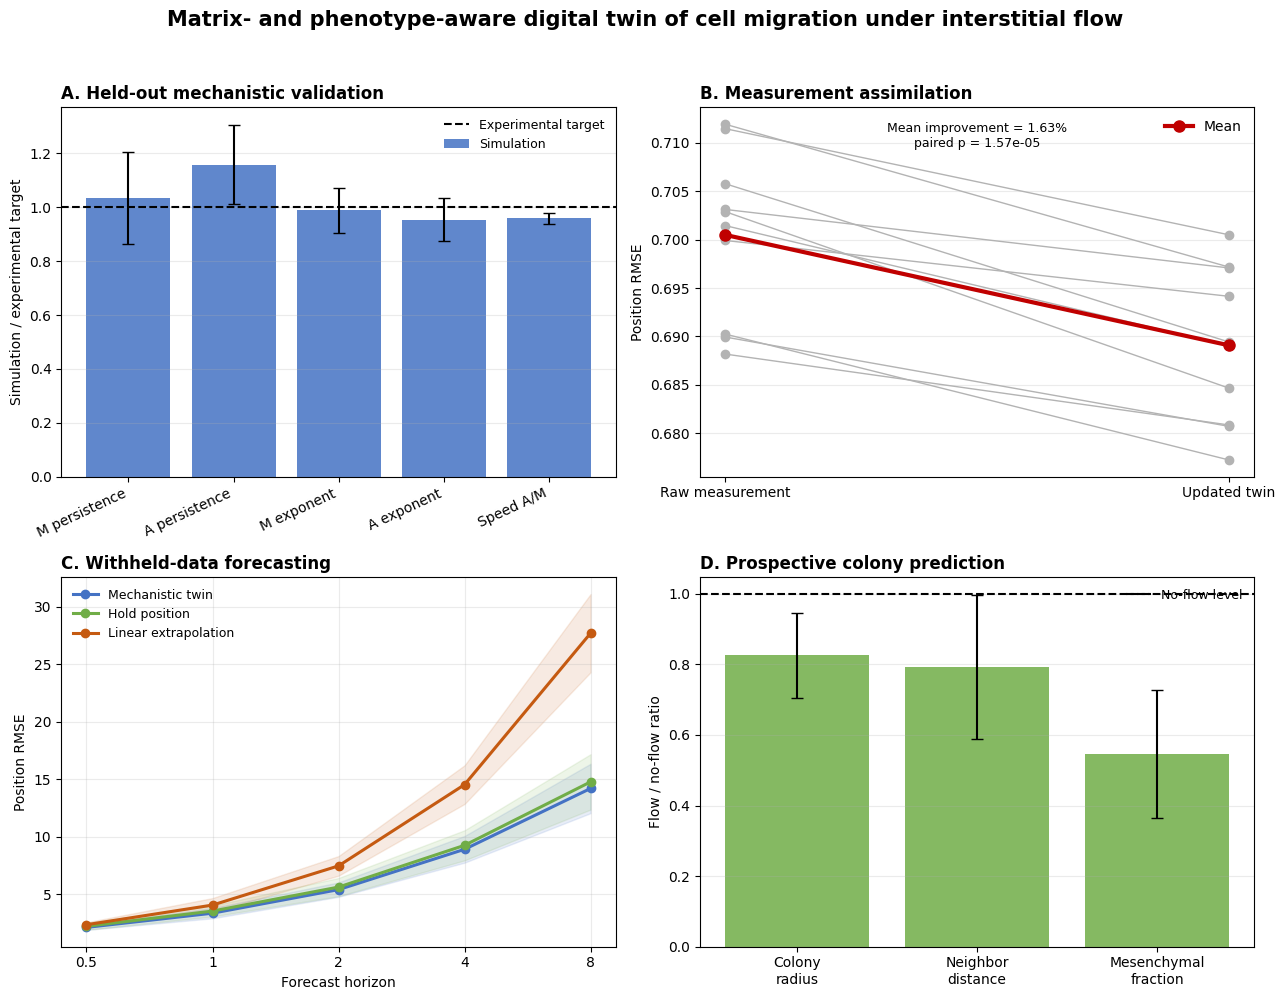

Saved: digital_twin_v2_outputs/v2_summary_figure.png
Saved: digital_twin_v2_outputs/v2_summary_figure.pdf


In [120]:
# Cell 111 — publication-ready Version 2 summary figure

import matplotlib.pyplot as plt

plt.style.use("default")

figure, axes = plt.subplots(
    2,
    2,
    figsize=(13, 10)
)

# --------------------------------------------------
# Panel A: held-out mechanistic validation
# --------------------------------------------------

axis = axes[0, 0]

short_metric_names = [
    "M persistence",
    "A persistence",
    "M exponent",
    "A exponent",
    "Speed A/M"
]

normalized_means = (
    final_metric_means / final_targets
)

normalized_sds = (
    final_metric_sds / final_targets
)

x_positions = np.arange(
    len(short_metric_names)
)

axis.bar(
    x_positions,
    normalized_means,
    yerr=normalized_sds,
    capsize=4,
    color="#4472C4",
    alpha=0.85,
    label="Simulation"
)

axis.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Experimental target"
)

axis.set_xticks(x_positions)
axis.set_xticklabels(
    short_metric_names,
    rotation=25,
    ha="right"
)

axis.set_ylabel(
    "Simulation / experimental target"
)

axis.set_title(
    "A. Held-out mechanistic validation",
    loc="left",
    fontweight="bold"
)

axis.legend(
    frameon=False,
    fontsize=9
)

axis.grid(
    axis="y",
    alpha=0.25
)

# --------------------------------------------------
# Panel B: paired state-assimilation RMSE
# --------------------------------------------------

axis = axes[0, 1]

for experiment_index in range(
    number_of_v2_experiments
):
    axis.plot(
        [0, 1],
        [
            measurement_rmse_values[
                experiment_index
            ],
            updated_rmse_values[
                experiment_index
            ]
        ],
        color="0.70",
        marker="o",
        linewidth=1
    )

axis.plot(
    [0, 1],
    [
        np.mean(measurement_rmse_values),
        np.mean(updated_rmse_values)
    ],
    color="#C00000",
    marker="o",
    linewidth=3,
    markersize=8,
    label="Mean"
)

axis.set_xticks([0, 1])
axis.set_xticklabels([
    "Raw measurement",
    "Updated twin"
])

axis.set_ylabel("Position RMSE")

axis.set_title(
    "B. Measurement assimilation",
    loc="left",
    fontweight="bold"
)

axis.grid(
    axis="y",
    alpha=0.25
)

axis.legend(
    frameon=False
)

axis.text(
    0.5,
    0.96,
    (
        f"Mean improvement = "
        f"{np.mean([r['improvement'] for r in v2_multi_experiment_results]):.2f}%\n"
        f"paired p = {paired_test.pvalue:.2e}"
    ),
    transform=axis.transAxes,
    ha="center",
    va="top",
    fontsize=9
)

# --------------------------------------------------
# Panel C: multi-experiment forecasts
# --------------------------------------------------

axis = axes[1, 0]

forecast_grouped = (
    forecast_table
    .groupby("horizon")
)

forecast_horizon_values = (
    forecast_horizons
)

for column_name, label, color in [
    (
        "twin_rmse",
        "Mechanistic twin",
        "#4472C4"
    ),
    (
        "hold_rmse",
        "Hold position",
        "#70AD47"
    ),
    (
        "linear_rmse",
        "Linear extrapolation",
        "#C55A11"
    )
]:
    means = np.array([
        forecast_grouped.get_group(
            horizon
        )[column_name].mean()
        for horizon in forecast_horizon_values
    ])

    standard_deviations = np.array([
        forecast_grouped.get_group(
            horizon
        )[column_name].std(ddof=1)
        for horizon in forecast_horizon_values
    ])

    axis.plot(
        forecast_horizon_values,
        means,
        marker="o",
        linewidth=2.2,
        label=label,
        color=color
    )

    axis.fill_between(
        forecast_horizon_values,
        means - standard_deviations,
        means + standard_deviations,
        color=color,
        alpha=0.12
    )

axis.set_xscale("log", base=2)

axis.set_xticks(
    forecast_horizon_values
)

axis.set_xticklabels([
    "0.5",
    "1",
    "2",
    "4",
    "8"
])

axis.set_xlabel("Forecast horizon")
axis.set_ylabel("Position RMSE")

axis.set_title(
    "C. Withheld-data forecasting",
    loc="left",
    fontweight="bold"
)

axis.grid(
    alpha=0.25
)

axis.legend(
    frameon=False,
    fontsize=9
)

# --------------------------------------------------
# Panel D: predicted effect of flow on colony
# --------------------------------------------------

axis = axes[1, 1]

colony_ratio_names = [
    "Colony\nradius",
    "Neighbor\ndistance",
    "Mesenchymal\nfraction"
]

colony_ratio_indices = [
    0,
    1,
    5
]

colony_ratios = []

for metric_index in colony_ratio_indices:
    colony_ratios.append(
        flow_colony_results[:, metric_index]
        / no_flow_colony_results[
            :, metric_index
        ]
    )

colony_ratio_means = np.array([
    np.mean(values)
    for values in colony_ratios
])

colony_ratio_sds = np.array([
    np.std(values, ddof=1)
    for values in colony_ratios
])

ratio_positions = np.arange(
    len(colony_ratio_names)
)

axis.bar(
    ratio_positions,
    colony_ratio_means,
    yerr=colony_ratio_sds,
    capsize=4,
    color="#70AD47",
    alpha=0.85
)

axis.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="No-flow level"
)

axis.set_xticks(ratio_positions)
axis.set_xticklabels(
    colony_ratio_names
)

axis.set_ylabel(
    "Flow / no-flow ratio"
)

axis.set_title(
    "D. Prospective colony prediction",
    loc="left",
    fontweight="bold"
)

axis.grid(
    axis="y",
    alpha=0.25
)

axis.legend(
    frameon=False,
    fontsize=9
)

figure.suptitle(
    (
        "Matrix- and phenotype-aware digital twin "
        "of cell migration under interstitial flow"
    ),
    fontsize=15,
    fontweight="bold",
    y=0.995
)

figure.tight_layout(
    rect=[0, 0, 1, 0.97]
)

summary_png_path = (
    v2_output_directory
    / "v2_summary_figure.png"
)

summary_pdf_path = (
    v2_output_directory
    / "v2_summary_figure.pdf"
)

figure.savefig(
    summary_png_path,
    dpi=300,
    bbox_inches="tight"
)

figure.savefig(
    summary_pdf_path,
    bbox_inches="tight"
)

plt.show()

print("Saved:", summary_png_path)
print("Saved:", summary_pdf_path)

## 18. Version 1 versus Version 2 context

The two versions use different mechanistic scopes and validation cohorts. This comparison documents model development; it should not be interpreted as a controlled performance ranking.


In [121]:
# Cell 112 — Version 1 versus Version 2 comparison

# Archived finalized Version 1 results
v1_measurement_rmse = 0.7121696317694689
v1_updated_rmse = 0.608603827045228
v1_rmse_improvement = 14.542294434391922
v1_phenotype_auc = 0.7862591030106815
v1_phenotype_brier = 0.092041196528567
v1_mean_forecast_coverage = 0.9476

v1_forecast_improvement_vs_linear = np.array([
    22.8,
    20.6,
    20.4,
    31.6,
    46.5
])

# Final Version 2 results
v2_mean_measurement_rmse = np.mean([
    result["measurement_rmse"]
    for result in v2_multi_experiment_results
])

v2_mean_updated_rmse = np.mean([
    result["updated_rmse"]
    for result in v2_multi_experiment_results
])

v2_mean_rmse_improvement = np.mean([
    result["improvement"]
    for result in v2_multi_experiment_results
])

v2_mean_phenotype_auc = np.mean([
    result["phenotype_auc"]
    for result in v2_multi_experiment_results
])

v2_mean_phenotype_brier = np.mean([
    result["phenotype_brier"]
    for result in v2_multi_experiment_results
])

v2_mean_forecast_coverage = np.mean([
    experiment[horizon_index]["coverage"]
    for experiment in multi_forecast_results
    for horizon_index in range(
        len(forecast_horizons)
    )
])

v2_forecast_improvement_vs_linear = []

for horizon_index in range(
    len(forecast_horizons)
):
    twin_values = np.array([
        experiment[horizon_index][
            "twin_rmse"
        ]
        for experiment in multi_forecast_results
    ])

    linear_values = np.array([
        experiment[horizon_index][
            "linear_rmse"
        ]
        for experiment in multi_forecast_results
    ])

    improvement = (
        100.0
        * (
            np.mean(linear_values)
            - np.mean(twin_values)
        )
        / np.mean(linear_values)
    )

    v2_forecast_improvement_vs_linear.append(
        improvement
    )

v2_forecast_improvement_vs_linear = np.array(
    v2_forecast_improvement_vs_linear
)

assimilation_comparison = pd.DataFrame({
    "metric": [
        "Measurement RMSE",
        "Updated twin RMSE",
        "RMSE improvement (%)",
        "Phenotype ROC AUC",
        "Phenotype Brier score",
        "Mean forecast coverage"
    ],
    "Version 1": [
        v1_measurement_rmse,
        v1_updated_rmse,
        v1_rmse_improvement,
        v1_phenotype_auc,
        v1_phenotype_brier,
        v1_mean_forecast_coverage
    ],
    "Version 2": [
        v2_mean_measurement_rmse,
        v2_mean_updated_rmse,
        v2_mean_rmse_improvement,
        v2_mean_phenotype_auc,
        v2_mean_phenotype_brier,
        v2_mean_forecast_coverage
    ]
})

forecast_comparison = pd.DataFrame({
    "horizon": forecast_horizons,
    "Version 1 improvement vs linear (%)":
        v1_forecast_improvement_vs_linear,
    "Version 2 improvement vs linear (%)":
        v2_forecast_improvement_vs_linear
})

model_scope_comparison = pd.DataFrame({
    "feature": [
        "Matrix remodeling",
        "Explicit fibronectin state",
        "Cell-matrix adhesion",
        "Stochastic phenotype switching",
        "Phenotype-specific motility",
        "Cell-cell adhesion",
        "Excluded volume",
        "Interaction ablation",
        "Independent held-out calibration",
        "Multi-experiment assimilation",
        "Multi-experiment forecasting"
    ],
    "Version 1": [
        "Implicit",
        "No",
        "Simplified",
        "Yes",
        "Yes",
        "No",
        "No",
        "No",
        "Limited",
        "Yes",
        "Yes"
    ],
    "Version 2": [
        "Explicit",
        "Yes",
        "Explicit",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "10 experiments",
        "10 experiments"
    ]
})

assimilation_comparison.to_csv(
    v2_output_directory
    / "version1_version2_metrics.csv",
    index=False
)

forecast_comparison.to_csv(
    v2_output_directory
    / "version1_version2_forecasts.csv",
    index=False
)

model_scope_comparison.to_csv(
    v2_output_directory
    / "version1_version2_model_scope.csv",
    index=False
)

print("ASSIMILATION AND INFERENCE")
print(
    assimilation_comparison.to_string(
        index=False
    )
)

print()
print("FORECAST IMPROVEMENT OVER LINEAR")
print(
    forecast_comparison.to_string(
        index=False
    )
)

print()
print("MODEL SCOPE")
print(
    model_scope_comparison.to_string(
        index=False
    )
)

print()
print(
    "Important: Version 1 and Version 2 use "
    "different mechanistic models and validation "
    "cohorts. This table provides context, not a "
    "direct performance ranking."
)

ASSIMILATION AND INFERENCE
                metric  Version 1  Version 2
      Measurement RMSE   0.712170   0.700498
     Updated twin RMSE   0.608604   0.689076
  RMSE improvement (%)  14.542294   1.628154
     Phenotype ROC AUC   0.786259   0.564590
 Phenotype Brier score   0.092041   0.208593
Mean forecast coverage   0.947600   0.934375

FORECAST IMPROVEMENT OVER LINEAR
 horizon  Version 1 improvement vs linear (%)  Version 2 improvement vs linear (%)
     0.5                                 22.8                             9.896068
     1.0                                 20.6                            17.290043
     2.0                                 20.4                            27.556718
     4.0                                 31.6                            38.635007
     8.0                                 46.5                            48.697023

MODEL SCOPE
                         feature  Version 1      Version 2
               Matrix remodeling   Implicit       Expl